In [1]:
# Data Handling
import pandas as pd
import numpy as np
import os
import shutil

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image & Annotation
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Modeling & Metrics
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
mean_squared_error, mean_absolute_error, r2_score, classification_report,
precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix
)
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler

# FNN Modelling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Statistical Fitting
from scipy.optimize import curve_fit
from scipy.stats import weibull_min
from scipy.special import softmax

# Feature Engineering
from sklearn.preprocessing import OneHotEncoder

In [2]:
gamelogs = pd.read_csv('compiled_gamelogs.csv')
adv_gamelogs = pd.read_csv('compiled_advanced_gamelogs.csv')
player_stats = pd.read_csv('compiled_team_stats.csv')
adv_player_stats = pd.read_csv('compiled_team_stats_advanced.csv')

In [3]:
gamelogs

,Rk,Gtm,Date,Unnamed: 3,Opp,Rslt,Tm,Opp.1,OT,FG,...,TRB_opp,AST_opp,STL_opp,BLK_opp,TOV_opp,PF_opp,Team,Season,SeasonType,GameID
0,15.0,15.0,2021-11-17,@,ATL,L,99.0,110.0,NaN,37.0,...,40.0,28.0,9.0,4.0,14.0,17.0,BOS,2022,reg,ATL_BOS_2021-11-17
1,16.0,16.0,2021-11-17,NaN,BOS,W,110.0,99.0,NaN,41.0,...,42.0,24.0,9.0,2.0,14.0,17.0,ATL,2022,reg,ATL_BOS_2021-11-17
2,48.0,48.0,2022-01-28,NaN,BOS,W,108.0,92.0,NaN,41.0,...,52.0,15.0,5.0,8.0,18.0,25.0,ATL,2022,reg,ATL_BOS_2022-01-28
3,50.0,50.0,2022-01-28,@,ATL,L,92.0,108.0,NaN,30.0,...,43.0,19.0,10.0,11.0,12.0,21.0,BOS,2022,reg,ATL_BOS_2022-01-28
4,56.0,56.0,2022-02-13,@,BOS,L,95.0,105.0,NaN,34.0,...,54.0,21.0,5.0,6.0,12.0,15.0,ATL,2022,reg,ATL_BOS_2022-02-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10509,61.0,61.0,2024-03-04,@,UTA,L,115.0,127.0,NaN,40.0,...,51.0,29.0,6.0,9.0,13.0,16.0,WAS,2024,reg,UTA_WAS_2024-03-04
10510,61.0,61.0,2025-03-05,NaN,UTA,W,125.0,122.0,NaN,42.0,...,58.0,21.0,5.0,3.0,15.0,19.0,WAS,2025,reg,UTA_WAS_2025-03-05
10511,62.0,62.0,2025-03-05,@,WAS,L,122.0,125.0,NaN,47.0,...,45.0,32.0,9.0,12.0,9.0,18.0,UTA,2025,reg,UTA_WAS_2025-03-05
10512,68.0,68.0,2025-03-19,@,UTA,L,112.0,128.0,NaN,43.0,...,42.0,30.0,7.0,1.0,17.0,16.0,WAS,2025,reg,UTA_WAS_2025-03-19


## Deriving the Pythagorean Expectation (Pe) Exponent

In [4]:
# Get unique seasons
seasons = gamelogs["Season"].unique()

# Create individual DataFrames for each year and type
for season in seasons:
    globals()[f"gamelog_reg_{season}"] = gamelogs[
        (gamelogs["Season"] == season) & (gamelogs["SeasonType"] == "reg")
    ]
    
    globals()[f"gamelog_post_{season}"] = gamelogs[
        (gamelogs["Season"] == season) & (gamelogs["SeasonType"] == "post")
    ]

Optimal Pythagorean Exponent by Season:
  2022: 12.8403
  2023: 14.2232
  2024: 14.2742
  2025: 13.2862


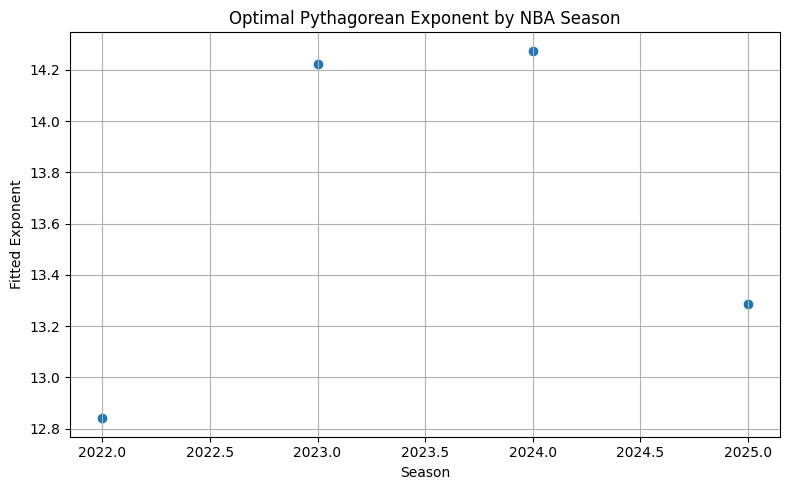

In [5]:
# Initialize a dictionary to store optimal exponents by season
exponent_by_season = {}

# Loop through each season in gamelog partitioning
for season in seasons:
    df_name = f"gamelog_reg_{season}"
    
    # Retrieve the DataFrame dynamically from globals
    if df_name not in globals():
        continue
    df = globals()[df_name].copy()
    
    # Defensive programming: check necessary columns
    if not {'Tm', 'Opp.1', 'Rslt'}.issubset(df.columns):
        continue

    # Create binary win column
    df['Win'] = df['Rslt'].str.startswith('W').astype(int)
    
    # Aggregate by team
    team_stats = df.groupby('Team').agg(
        Points_For=('Tm', 'sum'),
        Points_Against=('Opp.1', 'sum'),
        Wins=('Win', 'sum'),
        Games=('Win', 'count')
    ).reset_index()
    
    team_stats['Win%'] = team_stats['Wins'] / team_stats['Games']
    
    # Fit function
    def pythag_expect(inputs, exp):
        PF, PA = inputs
        return PF ** exp / (PF ** exp + PA ** exp)
    
    PF = team_stats['Points_For'].values
    PA = team_stats['Points_Against'].values
    WPct_actual = team_stats['Win%'].values

    # Curve fitting
    try:
        opt_exp, _ = curve_fit(lambda x, exp: pythag_expect(x, exp), (PF, PA), WPct_actual, p0=[13.0])
        exponent_by_season[season] = opt_exp[0]
    except RuntimeError:
        exponent_by_season[season] = None

# Print results
print("Optimal Pythagorean Exponent by Season:")
for season, exp in sorted(exponent_by_season.items()):
    if exp is not None:
        print(f"  {season}: {exp:.4f}")
    else:
        print(f"  {season}: fitting failed")

valid_seasons = [s for s in exponent_by_season if exponent_by_season[s] is not None]
valid_exponents = [exponent_by_season[s] for s in valid_seasons]

plt.figure(figsize=(8, 5))
plt.scatter(valid_seasons, valid_exponents, marker='o')
plt.title("Optimal Pythagorean Exponent by NBA Season")
plt.xlabel("Season")
plt.ylabel("Fitted Exponent")
plt.grid(True)
plt.tight_layout()
plt.show()

Postseason Pythagorean Exponent by Season:
  2022: 15.0866
  2023: 17.8466
  2024: 12.7721
  2025: 11.4739


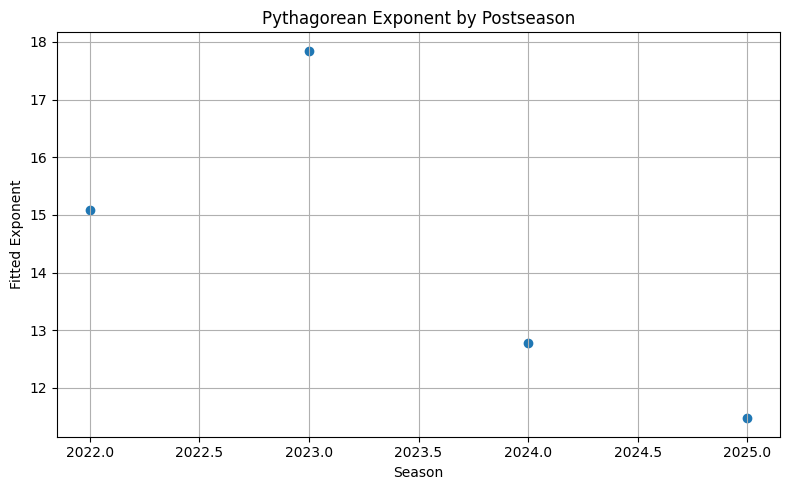

In [6]:
# Dictionary to hold postseason exponents
exponent_by_postseason = {}

# Loop through each postseason season
for season in seasons:
    df_name = f"gamelog_post_{season}"
    
    # Retrieve DataFrame if it exists
    if df_name not in globals():
        continue
    
    df = globals()[df_name].copy()

    # Make sure required columns exist
    if not {'Tm', 'Opp.1', 'Rslt'}.issubset(df.columns):
        continue

    # Safely create 'Win' column
    df['Win'] = df['Rslt'].fillna('').str.startswith('W').astype(int)

    # Aggregate team-level postseason stats
    team_stats = df.groupby('Team').agg(
        Points_For=('Tm', 'sum'),
        Points_Against=('Opp.1', 'sum'),
        Wins=('Win', 'sum'),
        Games=('Win', 'count')
    ).reset_index()

    team_stats['Win%'] = team_stats['Wins'] / team_stats['Games']

    # Define Pythagorean expectation function
    def pythag_expect(inputs, exp):
        PF, PA = inputs
        return PF ** exp / (PF ** exp + PA ** exp)

    PF = team_stats['Points_For'].values
    PA = team_stats['Points_Against'].values
    WPct_actual = team_stats['Win%'].values

    try:
        opt_exp, _ = curve_fit(lambda x, exp: pythag_expect(x, exp), 
                               (PF, PA), WPct_actual, p0=[13.0])
        exponent_by_postseason[season] = opt_exp[0]
    except RuntimeError:
        exponent_by_postseason[season] = None

# Print results
print("Postseason Pythagorean Exponent by Season:")
for season, exp in sorted(exponent_by_postseason.items()):
    if exp is not None:
        print(f"  {season}: {exp:.4f}")
    else:
        print(f"  {season}: fitting failed")

valid_seasons = [s for s, v in exponent_by_postseason.items() if v is not None]
valid_exponents = [v for v in exponent_by_postseason.values() if v is not None]

plt.figure(figsize=(8, 5))
plt.scatter(valid_seasons, valid_exponents, marker='o', linestyle='-')
plt.title("Pythagorean Exponent by Postseason")
plt.xlabel("Season")
plt.ylabel("Fitted Exponent")
plt.grid(True)
plt.tight_layout()
plt.show()

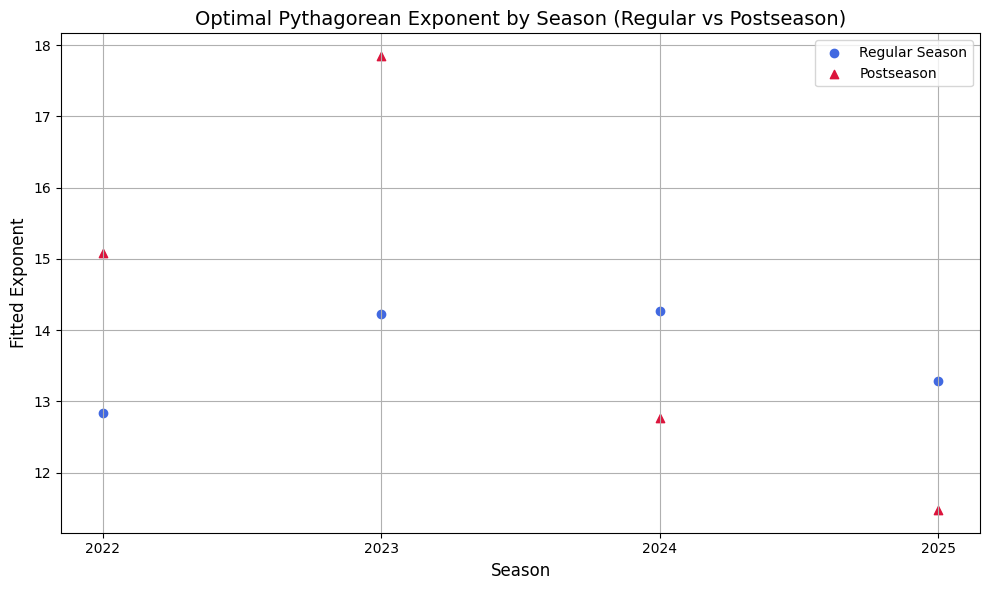

In [7]:
# Filter only seasons with successful exponent fitting
reg_seasons = sorted([s for s in exponent_by_season if exponent_by_season[s] is not None])
reg_exponents = [exponent_by_season[s] for s in reg_seasons]

post_seasons = sorted([s for s in exponent_by_postseason if exponent_by_postseason[s] is not None])
post_exponents = [exponent_by_postseason[s] for s in post_seasons]

# Combine season years to create unified x-tick set
all_years = sorted(set(reg_seasons + post_seasons))

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(reg_seasons, reg_exponents, color='royalblue', label='Regular Season', marker='o')
plt.scatter(post_seasons, post_exponents, color='crimson', label='Postseason', marker='^')

plt.title("Optimal Pythagorean Exponent by Season (Regular vs Postseason)", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Fitted Exponent", fontsize=12)

# Set clean x-ticks using integer season years
plt.xticks(all_years)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

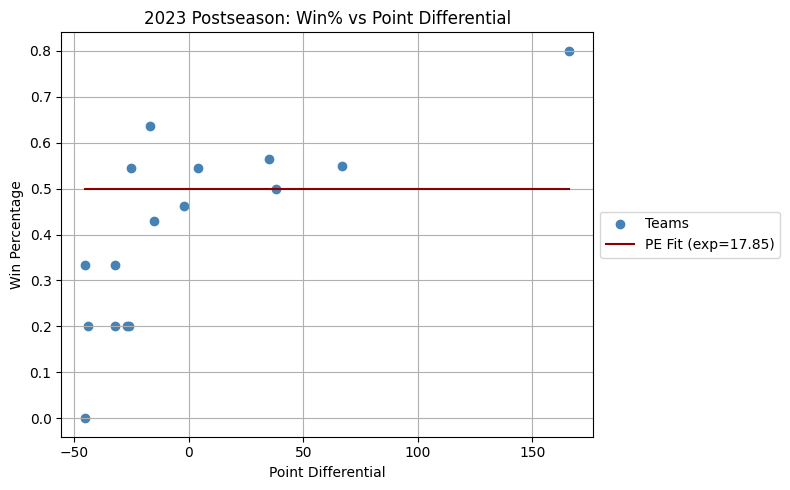

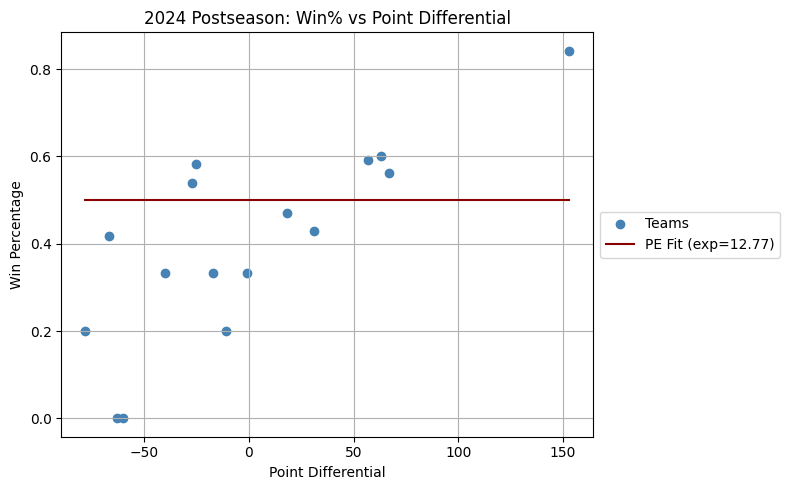

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot win% vs point diff with fitted curve
def plot_postseason_exponent_fit(season):
    df_name = f"gamelog_post_{season}"
    if df_name not in globals():
        print(f"{df_name} not found.")
        return

    df = globals()[df_name].copy()
    df['Win'] = df['Rslt'].fillna('').str.startswith('W').astype(int)

    team_stats = df.groupby('Team').agg(
        PF=('Tm', 'sum'),
        PA=('Opp.1', 'sum'),
        Wins=('Win', 'sum'),
        Games=('Win', 'count')
    ).reset_index()

    team_stats['Win%'] = team_stats['Wins'] / team_stats['Games']
    team_stats['Diff'] = team_stats['PF'] - team_stats['PA']

    # Use stored fitted exponent
    exp = exponent_by_postseason.get(season, 13.0)

    # Generate curve
    x_vals = np.linspace(team_stats['Diff'].min(), team_stats['Diff'].max(), 200)
    y_vals = np.abs(x_vals) ** exp / (np.abs(x_vals) ** exp + np.abs(-x_vals) ** exp)
    y_vals = np.clip(y_vals, 0, 1)  # avoid nan from negative base

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(team_stats['Diff'], team_stats['Win%'], color='steelblue', label='Teams')
    plt.plot(x_vals, y_vals, color='darkred', label=f'PE Fit (exp={exp:.2f})')
    plt.title(f"{season} Postseason: Win% vs Point Differential")
    plt.xlabel("Point Differential")
    plt.ylabel("Win Percentage")
    plt.grid(True)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

# Compare 2023 and 2024
plot_postseason_exponent_fit(2023)
plot_postseason_exponent_fit(2024)

In [9]:
def make_white_transparent(img, threshold=240):
    img = img.convert("RGBA")
    datas = img.getdata()
    new_data = []

    for item in datas:
        r, g, b, a = item
        if r > threshold and g > threshold and b > threshold:
            new_data.append((255, 255, 255, 0))  # Fully transparent
        else:
            new_data.append((r, g, b, a))

    img.putdata(new_data)
    return img

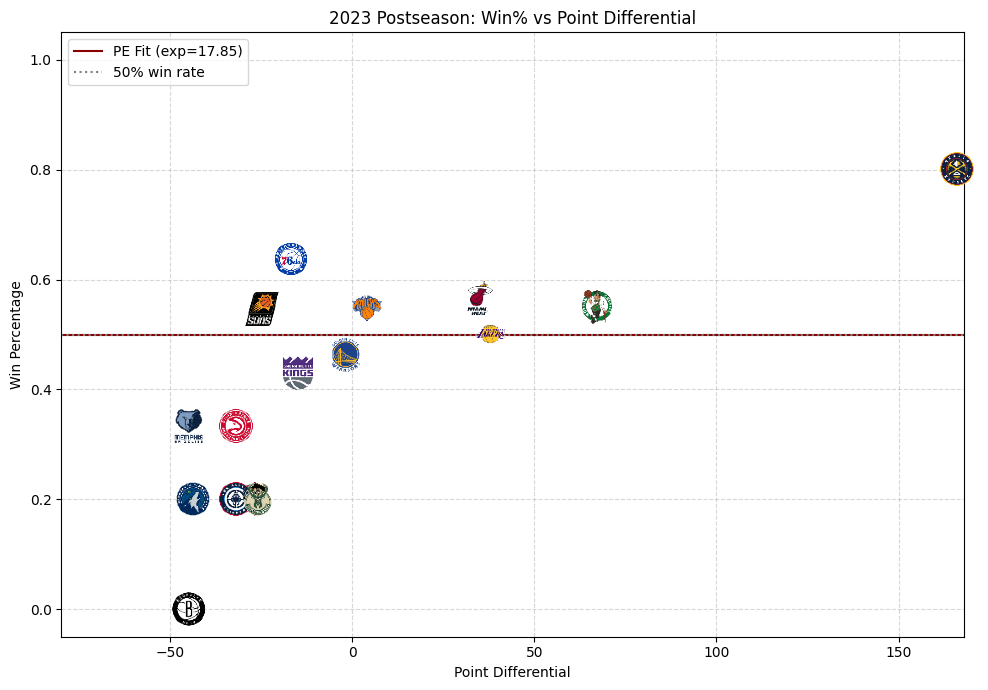

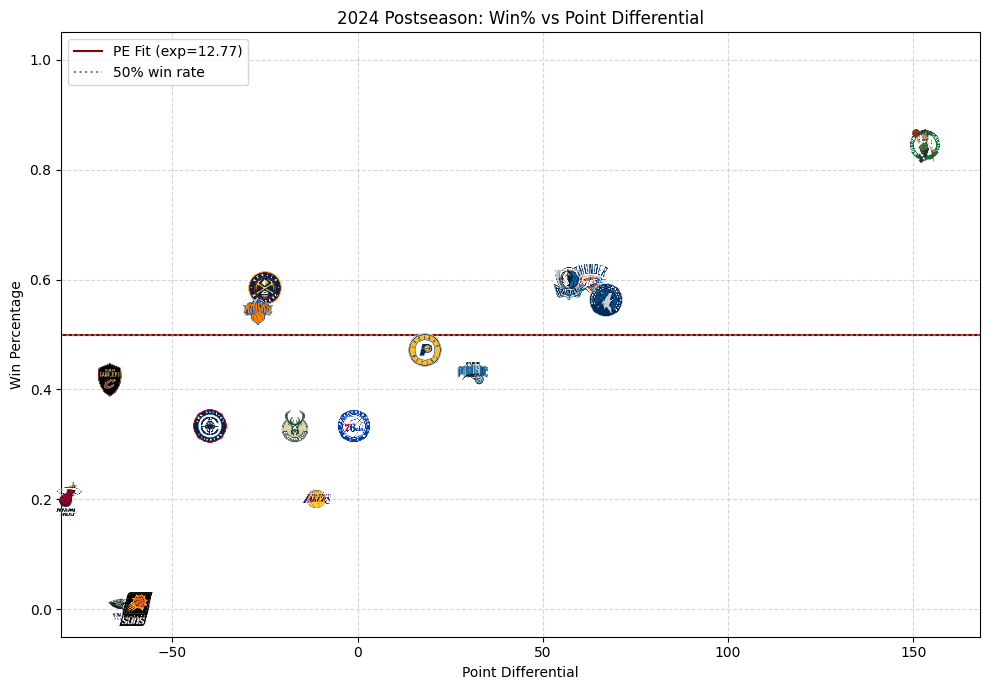

In [10]:
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

logo_folder = "team_logos"  # Folder with PNG logos

# Step 1: Collect all postseason data into a list
seasons = [2023, 2024]
postseason_data = []

for season in seasons:
    df_name = f"gamelog_post_{season}"
    if df_name in globals():
        df = globals()[df_name].copy()
        df['Win'] = df['Rslt'].fillna('').str.startswith('W').astype(int)
        team_stats = df.groupby('Team').agg(
            PF=('Tm', 'sum'),
            PA=('Opp.1', 'sum'),
            Wins=('Win', 'sum'),
            Games=('Win', 'count')
        ).reset_index()
        team_stats['Win%'] = team_stats['Wins'] / team_stats['Games']
        team_stats['Diff'] = team_stats['PF'] - team_stats['PA']
        postseason_data.append((season, team_stats))

# Step 2: Calculate global axis limits
all_diffs = np.concatenate([data[1]['Diff'].values for data in postseason_data])
all_win_pcts = np.concatenate([data[1]['Win%'].values for data in postseason_data])

x_min, x_max = all_diffs.min() - 2, all_diffs.max() + 2
y_min, y_max = -0.05, 1.05

# Step 3: Plot each season with consistent axes
for season, team_stats in postseason_data:
    exp = exponent_by_postseason.get(season, 13.0)
    x_vals = np.linspace(x_min, x_max, 200)
    y_vals = np.abs(x_vals)**exp / (np.abs(x_vals)**exp + np.abs(-x_vals)**exp)
    y_vals = np.clip(y_vals, 0, 1)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("Point Differential")
    ax.set_ylabel("Win Percentage")
    ax.set_title(f"{season} Postseason: Win% vs Point Differential")
    ax.grid(True, linestyle='--', alpha=0.5)

    ax.plot(x_vals, y_vals, color='darkred', label=f'PE Fit (exp={exp:.2f})')
    ax.plot([x_min, x_max], [0.5, 0.5], linestyle=':', color='gray', label='50% win rate')
    ax.legend(loc='upper left')

    for _, row in team_stats.iterrows():
        team = row['Team']
        diff = row['Diff']
        win_pct = row['Win%']
        logo_path = os.path.join(logo_folder, f"{team}.png")
        if os.path.exists(logo_path):
            img = Image.open(logo_path).resize((40, 40), Image.Resampling.LANCZOS)
            img = make_white_transparent(img)
            imagebox = OffsetImage(img, zoom=0.6)
            ab = AnnotationBbox(imagebox, (diff, win_pct), frameon=False)
            ax.add_artist(ab)
        else:
            ax.plot(diff, win_pct, 'o', color='steelblue')
            ax.text(diff, win_pct, team, fontsize=8, ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

## Weibull Distribution

In [11]:
# Dictionary to store Weibull-based exponent estimates
weibull_info_by_regseason = {}

seasons = [2022, 2023, 2024, 2025]

for season in seasons:
    df_name = f"gamelog_reg_{season}"

    if df_name not in globals():
        continue

    df_raw = globals()[df_name].copy()
    
    # Filter out invalid rows (non-finite values)
    df = df_raw[np.isfinite(df_raw['Tm']) & np.isfinite(df_raw['Opp.1'])].copy()

    if df.empty:
        continue

    try:
        # Fit Weibull distributions (location fixed at 0)
        k_pf, _, scale_pf = weibull_min.fit(df['Tm'].values, floc=0)
        k_pa, _, scale_pa = weibull_min.fit(df['Opp.1'].values, floc=0)
        
        k_avg = (k_pf + k_pa) / 2
        pyt_exp_weibull = 2 * k_avg  # James approximation

        weibull_info_by_regseason[season] = {
            'k_pf': k_pf,
            'k_pa': k_pa,
            'k_avg': k_avg,
            'pyt_exp_weibull': pyt_exp_weibull
        }
    except Exception as e:
        weibull_info_by_regseason[season] = None

# Print the results
print("Weibull-Based Pythagorean Exponents (Regular Season):")
for season in sorted(seasons):
    info = weibull_info_by_regseason.get(season)
    if info:
        print(f"\nSeason {season}")
        print(f" Shape (Points For):     {info['k_pf']:.4f}")
        print(f" Shape (Points Against): {info['k_pa']:.4f}")
        print(f" Average shape (k):      {info['k_avg']:.4f}")
        print(f" Estimated Exponent:     {info['pyt_exp_weibull']:.4f}")
    else:
        print(f"\nSeason {season}: Weibull fitting failed.")

Weibull-Based Pythagorean Exponents (Regular Season):

Season 2022
 Shape (Points For):     9.1356
 Shape (Points Against): 9.1356
 Average shape (k):      9.1356
 Estimated Exponent:     18.2713

Season 2023
 Shape (Points For):     9.5876
 Shape (Points Against): 9.5876
 Average shape (k):      9.5876
 Estimated Exponent:     19.1752

Season 2024
 Shape (Points For):     9.3244
 Shape (Points Against): 9.3244
 Average shape (k):      9.3244
 Estimated Exponent:     18.6488

Season 2025
 Shape (Points For):     9.4531
 Shape (Points Against): 9.4531
 Average shape (k):      9.4531
 Estimated Exponent:     18.9061


In [12]:
exponent_by_postseason = {}
weibull_info_by_postseason = {}

for season in seasons:
    df_name = f"gamelog_post_{season}"

    if df_name not in globals():
        continue
    df_raw = globals()[df_name].copy()

    # Clean data (drop NaNs, infs)
    df = df_raw[np.isfinite(df_raw['Tm']) & np.isfinite(df_raw['Opp.1'])].copy()

    if df.empty or not {'Tm', 'Opp.1', 'Rslt'}.issubset(df.columns):
        continue

    df['Win'] = df['Rslt'].fillna('').str.startswith('W').astype(int)

    team_stats = df.groupby('Team').agg(
        Points_For=('Tm', 'sum'),
        Points_Against=('Opp.1', 'sum'),
        Wins=('Win', 'sum'),
        Games=('Win', 'count')
    ).reset_index()

    team_stats['Win%'] = team_stats['Wins'] / team_stats['Games']

    # --- Pythagorean Expectation Exponent (Fitted via least squares) ---
    def pythag_expect(inputs, exp):
        PF, PA = inputs
        return PF ** exp / (PF ** exp + PA ** exp)

    PF = team_stats['Points_For'].values
    PA = team_stats['Points_Against'].values
    WPct_actual = team_stats['Win%'].values

    try:
        opt_exp, _ = curve_fit(lambda x, exp: pythag_expect(x, exp), (PF, PA), WPct_actual, p0=[13.0])
        exponent_by_postseason[season] = opt_exp[0]
    except RuntimeError:
        exponent_by_postseason[season] = None

    # --- Weibull Estimation for Exponent ---
    pf = df['Tm'].values
    pa = df['Opp.1'].values

    try:
        k_pf, _, scale_pf = weibull_min.fit(pf, floc=0)
        k_pa, _, scale_pa = weibull_min.fit(pa, floc=0)
        k_avg = (k_pf + k_pa) / 2
        weibull_exp = 2 * k_avg  # James approximation

        weibull_info_by_postseason[season] = {
            'k_pf': k_pf,
            'k_pa': k_pa,
            'k_avg': k_avg,
            'pyt_exp_weibull': weibull_exp
        }

    except Exception as e:
        weibull_info_by_postseason[season] = None

# --- Display results ---
print("Postseason Exponents by Postseason:")
for season in sorted(seasons):
    fit = exponent_by_postseason.get(season)
    weibull = weibull_info_by_postseason.get(season)

    if fit is not None:
        print(f"\nSeason {season}")
        print(f" Fitted exponent: {fit:.4f}")
        if weibull:
            print(f" Weibull shape (PF): {weibull['k_pf']:.4f}")
            print(f" Weibull shape (PA): {weibull['k_pa']:.4f}")
            print(f" Avg. shape parameter: {weibull['k_avg']:.4f}")
            print(f" Estimated exponent via Weibull: {weibull['pyt_exp_weibull']:.4f}")
        else:
            print(" Weibull fitting failed.")
    elif weibull:
        print(f"\nSeason {season} (no curve_fit)")
        print(f" Estimated exponent via Weibull: {weibull['pyt_exp_weibull']:.4f}")
    else:
        print(f"\nSeason {season}: No valid data.")

Postseason Exponents by Postseason:

Season 2022
 Fitted exponent: 15.0866
 Weibull shape (PF): 9.5125
 Weibull shape (PA): 9.5125
 Avg. shape parameter: 9.5125
 Estimated exponent via Weibull: 19.0249

Season 2023
 Fitted exponent: 17.8466
 Weibull shape (PF): 9.9444
 Weibull shape (PA): 9.9444
 Avg. shape parameter: 9.9444
 Estimated exponent via Weibull: 19.8888

Season 2024
 Fitted exponent: 12.7721
 Weibull shape (PF): 9.9105
 Weibull shape (PA): 9.9105
 Avg. shape parameter: 9.9105
 Estimated exponent via Weibull: 19.8209

Season 2025
 Fitted exponent: 11.4739
 Weibull shape (PF): 8.7449
 Weibull shape (PA): 8.7449
 Avg. shape parameter: 8.7449
 Estimated exponent via Weibull: 17.4898


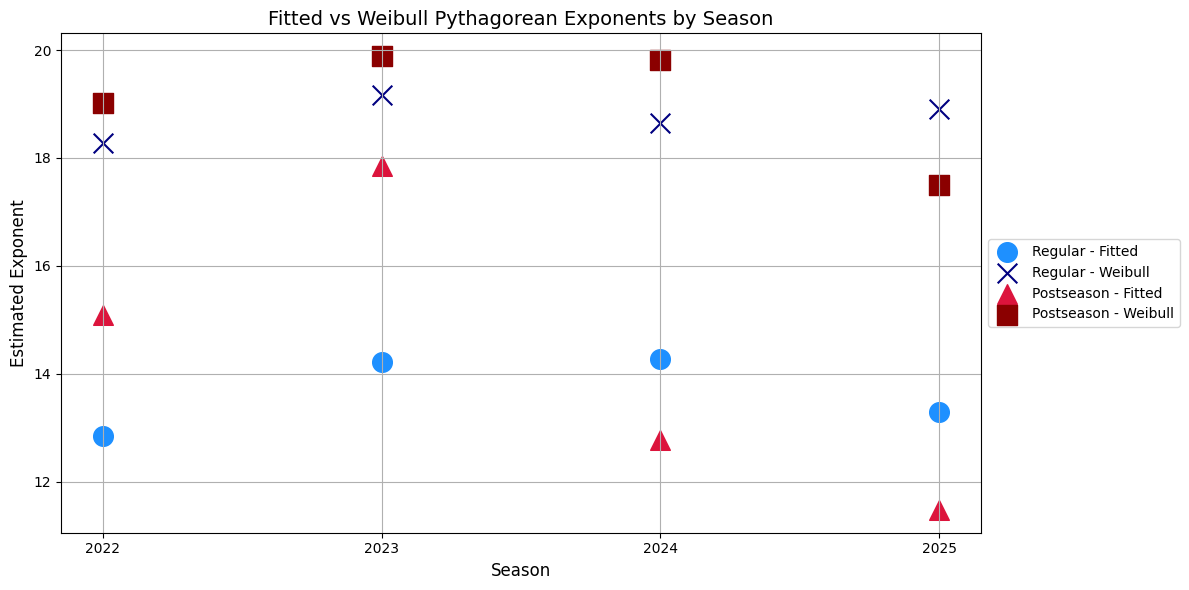

In [13]:
import matplotlib.pyplot as plt

# === Prepare Regular Season Data ===
reg_seasons = sorted([s for s in weibull_info_by_regseason if weibull_info_by_regseason[s] is not None])
reg_weibull_exponents = [weibull_info_by_regseason[s]['pyt_exp_weibull'] for s in reg_seasons]

reg_fitted_seasons = sorted([s for s in exponent_by_season if exponent_by_season[s] is not None])
reg_fitted_exponents = [exponent_by_season[s] for s in reg_fitted_seasons]

# === Prepare Postseason Data ===
post_seasons = sorted([s for s in weibull_info_by_postseason if weibull_info_by_postseason[s] is not None])
post_weibull_exponents = [weibull_info_by_postseason[s]['pyt_exp_weibull'] for s in post_seasons]

post_fitted_seasons = sorted([s for s in exponent_by_postseason if exponent_by_postseason[s] is not None])
post_fitted_exponents = [exponent_by_postseason[s] for s in post_fitted_seasons]

# === Plot
plt.figure(figsize=(12, 6))

# Regular season scatter
plt.scatter(reg_seasons, reg_fitted_exponents, marker='o', color='dodgerblue', label='Regular - Fitted', s=200)
plt.scatter(reg_seasons, reg_weibull_exponents, marker='x', color='navy', label='Regular - Weibull', s=200)

# Postseason scatter
plt.scatter(post_seasons, post_fitted_exponents, marker='^', color='crimson', label='Postseason - Fitted', s=200)
plt.scatter(post_seasons, post_weibull_exponents, marker='s', color='darkred', label='Postseason - Weibull', s=200)

plt.title("Fitted vs Weibull Pythagorean Exponents by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Estimated Exponent", fontsize=12)
plt.xticks(sorted(set(reg_seasons + post_seasons)))  # Clean full-year ticks
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

# Create season list from both dictionaries to ensure full coverage
all_seasons = sorted(set(exponent_by_season.keys()) | set(weibull_info_by_regseason.keys()) |
                     set(exponent_by_postseason.keys()) | set(weibull_info_by_postseason.keys()))

# Build rows for DataFrame
rows = []
for season in all_seasons:
    reg_fitted = exponent_by_season.get(season)
    reg_weibull = weibull_info_by_regseason.get(season, {}).get('pyt_exp_weibull')
    post_fitted = exponent_by_postseason.get(season)
    post_weibull = weibull_info_by_postseason.get(season, {}).get('pyt_exp_weibull')

    rows.append({
        'Season': season,
        'Regular (Fitted)': round(reg_fitted, 4) if reg_fitted is not None else '—',
        'Regular (Weibull)': round(reg_weibull, 4) if reg_weibull is not None else '—',
        'Post (Fitted)': round(post_fitted, 4) if post_fitted is not None else '—',
        'Post (Weibull)': round(post_weibull, 4) if post_weibull is not None else '—'
    })

# Create DataFrame
exponent_table = pd.DataFrame(rows)

# Optional: reorder columns
exponent_table = exponent_table[['Season', 'Regular (Fitted)', 'Regular (Weibull)', 
                                 'Post (Fitted)', 'Post (Weibull)']]

# Display
print(exponent_table.to_string(index=False))

 Season  Regular (Fitted)  Regular (Weibull)  Post (Fitted)  Post (Weibull)
   2022           12.8403            18.2713        15.0866         19.0249
   2023           14.2232            19.1752        17.8466         19.8888
   2024           14.2742            18.6488        12.7721         19.8209
   2025           13.2862            18.9061        11.4739         17.4898


## Performing Pe (Regular Season)

In [15]:
pe_by_team_season = {}

for season in seasons:
    df_name = f"gamelog_reg_{season}"
    
    if df_name not in globals() or exponent_by_season.get(season) is None:
        continue
    
    df = globals()[df_name].copy()
    df['Win'] = df['Rslt'].str.startswith('W').astype(int)
    
    # Team-level aggregates
    team_stats = df.groupby('Team').agg(
        Points_For=('Tm', 'sum'),
        Points_Against=('Opp.1', 'sum'),
        Wins=('Win', 'sum'),
        Games=('Win', 'count')
    ).reset_index()
    
    # Compute actual Win%
    team_stats['Win%'] = team_stats['Wins'] / team_stats['Games']
    
    # Use season-specific exponent to compute Pythagorean Expectation
    exp = exponent_by_season[season]
    PF = team_stats['Points_For']
    PA = team_stats['Points_Against']
    
    team_stats['PE_Win%'] = PF ** exp / (PF ** exp + PA ** exp)

    team_stats['^ Win%'] = team_stats['Win%'] - team_stats['PE_Win%']
    
    # Store with season key
    pe_by_team_season[season] = team_stats[['Team', 'Win%', 'PE_Win%', '^ Win%']].sort_values(by='^ Win%').copy()

print(pe_by_team_season[2025])  # replace with any valid season string

   Team      Win%   PE_Win%    ^ Win%
15  MIA  0.451220  0.516884 -0.065665
28  UTA  0.207317  0.256287 -0.048970
17  MIN  0.597561  0.644359 -0.046798
14  MEM  0.585366  0.631976 -0.046611
22  PHI  0.292683  0.324169 -0.031486
12  LAC  0.609756  0.636444 -0.026688
25  SAC  0.487805  0.513675 -0.025870
8   DET  0.536585  0.554943 -0.018358
4   CHO  0.231707  0.248910 -0.017203
9   GSW  0.585366  0.596664 -0.011298
27  TOR  0.365854  0.376430 -0.010577
26  SAS  0.414634  0.421263 -0.006629
1   BOS  0.743902  0.747257 -0.003354
7   DEN  0.609756  0.607084  0.002672
10  HOU  0.634146  0.630687  0.003459
21  ORL  0.500000  0.496160  0.003840
19  NYK  0.621951  0.617448  0.004503
18  NOP  0.256098  0.250853  0.005245
6   DAL  0.475610  0.465474  0.010136
20  OKC  0.829268  0.817600  0.011669
16  MIL  0.585366  0.571467  0.013899
3   CHI  0.475610  0.456388  0.019222
0   ATL  0.487805  0.468319  0.019486
2   BRK  0.317073  0.295336  0.021737
23  PHO  0.439024  0.414292  0.024732
24  POR  0.4

In [16]:
pe_comparison_by_season = {}

for season in seasons:
    df_name = f"gamelog_reg_{season}"  
    
    if df_name not in globals():
        continue

    df = globals()[df_name].copy()
    if not {'Tm', 'Opp.1', 'Rslt'}.issubset(df.columns):
        continue
    
    df['Win'] = df['Rslt'].fillna('').str.startswith('W').astype(int)

    team_stats = df.groupby('Team').agg(
        Points_For=('Tm', 'sum'),
        Points_Against=('Opp.1', 'sum'),
        Wins=('Win', 'sum'),
        Games=('Win', 'count')
    ).reset_index()

    team_stats['Win%'] = team_stats['Wins'] / team_stats['Games']

    # Pull fitted and Weibull exponents
    fitted_exp = exponent_by_postseason.get(season) or exponent_by_regseason.get(season)
    weibull_exp = (weibull_info_by_postseason.get(season) or weibull_info_by_regseason.get(season) or {}).get('pyt_exp_weibull')

    if fitted_exp is None or weibull_exp is None:
        continue

    PF = team_stats['Points_For']
    PA = team_stats['Points_Against']

    # Pythagorean expected win % using both exponents
    team_stats['PE_Fitted'] = PF ** fitted_exp / (PF ** fitted_exp + PA ** fitted_exp)
    team_stats['PE_Weibull'] = PF ** weibull_exp / (PF ** weibull_exp + PA ** weibull_exp)
    
    # Compare to actual
    team_stats['Δ Fitted'] = team_stats['Win%'] - team_stats['PE_Fitted']
    team_stats['Δ Weibull'] = team_stats['Win%'] - team_stats['PE_Weibull']
    team_stats['Diff (Weibull - Fitted)'] = team_stats['PE_Weibull'] - team_stats['PE_Fitted']

    pe_comparison_by_season[season] = team_stats[[
        'Team', 'Win%', 'PE_Fitted', 'PE_Weibull', 'Δ Fitted', 'Δ Weibull', 'Diff (Weibull - Fitted)'
    ]].copy()

In [17]:
pe_comparison_by_season[2022].sort_values('Diff (Weibull - Fitted)', ascending=False)

,Team,Win%,PE_Fitted,PE_Weibull,Δ Fitted,Δ Weibull,Diff (Weibull - Fitted)
23,PHO,0.780488,0.734783,0.783306,0.045705,-0.002818,0.048523
1,BOS,0.621951,0.734254,0.782725,-0.112303,-0.160773,0.048471
28,UTA,0.597561,0.695022,0.738604,-0.097461,-0.141043,0.043582
9,GSW,0.646341,0.683937,0.725803,-0.037596,-0.079461,0.041866
14,MEM,0.682927,0.681451,0.722913,0.001476,-0.039986,0.041462
15,MIA,0.646341,0.650911,0.686904,-0.004569,-0.040563,0.035994
6,DAL,0.634146,0.615092,0.643625,0.019055,-0.009479,0.028534
16,MIL,0.621951,0.609352,0.636602,0.012599,-0.014651,0.027250
22,PHI,0.621951,0.589633,0.612317,0.032318,0.009634,0.022684
17,MIN,0.560976,0.585823,0.607600,-0.024847,-0.046624,0.021777


In [18]:
# Combine all season-by-season DataFrames
pe_all_seasons = pd.concat(pe_comparison_by_season.values(), ignore_index=True)

# Add a column for number of games (needed for weighting)
pe_all_seasons['Games'] = pe_all_seasons['Win%'] * pe_all_seasons[['PE_Fitted', 'PE_Weibull']].count(axis=1)  # approximate if Games not stored

# Group by team and compute weighted metrics
team_agg = pe_all_seasons.groupby('Team').agg(
    Seasons=('Win%', 'count'),
    Total_Games=('Games', 'sum'),
    Total_Wins=('Win%', lambda x: (x * pe_all_seasons.loc[x.index, 'Games']).sum()),
    PE_Fitted_Total=('PE_Fitted', lambda x: (x * pe_all_seasons.loc[x.index, 'Games']).sum()),
    PE_Weibull_Total=('PE_Weibull', lambda x: (x * pe_all_seasons.loc[x.index, 'Games']).sum())
).reset_index()

# Compute final percentages
team_agg['Avg Win%'] = team_agg['Total_Wins'] / team_agg['Total_Games']
team_agg['Avg PE_Fitted'] = team_agg['PE_Fitted_Total'] / team_agg['Total_Games']
team_agg['Avg PE_Weibull'] = team_agg['PE_Weibull_Total'] / team_agg['Total_Games']
team_agg['Δ Fitted'] = team_agg['Avg Win%'] - team_agg['Avg PE_Fitted']
team_agg['Δ Weibull'] = team_agg['Avg Win%'] - team_agg['Avg PE_Weibull']
team_agg['Diff (Weibull - Fitted)'] = team_agg['Avg PE_Weibull'] - team_agg['Avg PE_Fitted']

# Sort results by average win %
team_agg = team_agg.sort_values('Avg Win%', ascending=False).reset_index(drop=True)

# View final team-level comparison
team_agg = team_agg[[
    'Team', 'Seasons', 'Avg Win%', 'Avg PE_Fitted', 'Avg PE_Weibull', 'Δ Fitted', 'Δ Weibull', 'Diff (Weibull - Fitted)'
]]

print(team_agg.round(4))

   Team  Seasons  Avg Win%  Avg PE_Fitted  Avg PE_Weibull  Δ Fitted  \
0   BOS        4    0.7153         0.7424          0.8081   -0.0271   
1   OKC        4    0.6484         0.6369          0.6911    0.0115   
2   CLE        4    0.6443         0.6499          0.6948   -0.0056   
3   DEN        4    0.6368         0.6124          0.6513    0.0244   
4   MIL        4    0.6317         0.5969          0.6243    0.0347   
5   PHO        4    0.6172         0.6039          0.6263    0.0133   
6   MIN        4    0.5950         0.6041          0.6487   -0.0090   
7   MEM        4    0.5876         0.5989          0.6180   -0.0112   
8   GSW        4    0.5852         0.6048          0.6380   -0.0196   
9   PHI        4    0.5752         0.5782          0.5924   -0.0029   
10  LAC        4    0.5740         0.5613          0.5904    0.0126   
11  NYK        4    0.5721         0.5907          0.6252   -0.0186   
12  MIA        4    0.5576         0.5573          0.5763    0.0002   
13  DA

In [19]:
def make_white_transparent(img, threshold=240):
    img = img.convert("RGBA")
    datas = img.getdata()
    new_data = []

    for item in datas:
        r, g, b, a = item
        if r > threshold and g > threshold and b > threshold:
            new_data.append((255, 255, 255, 0))  # Fully transparent
        else:
            new_data.append((r, g, b, a))

    img.putdata(new_data)
    return img

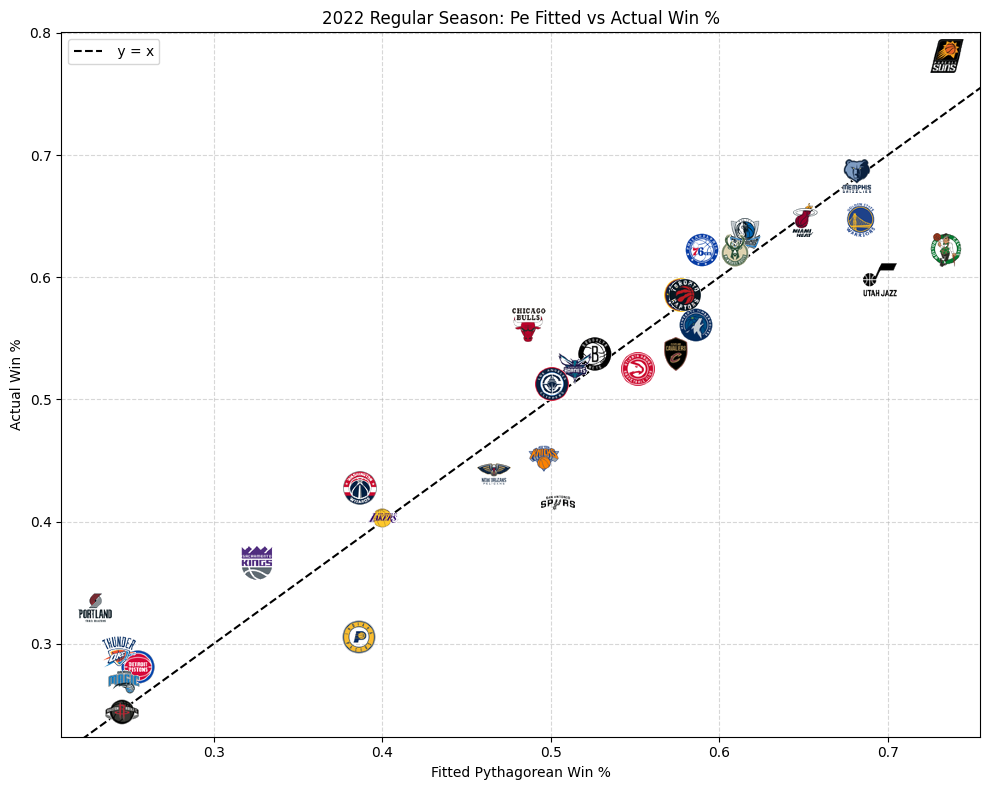

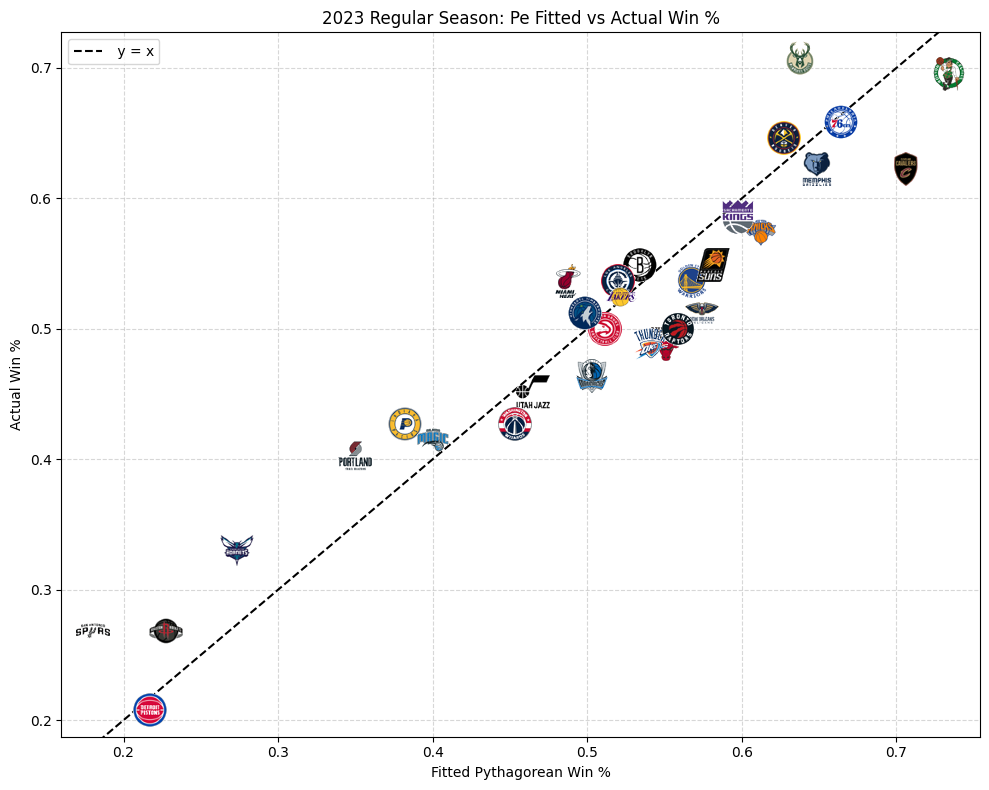

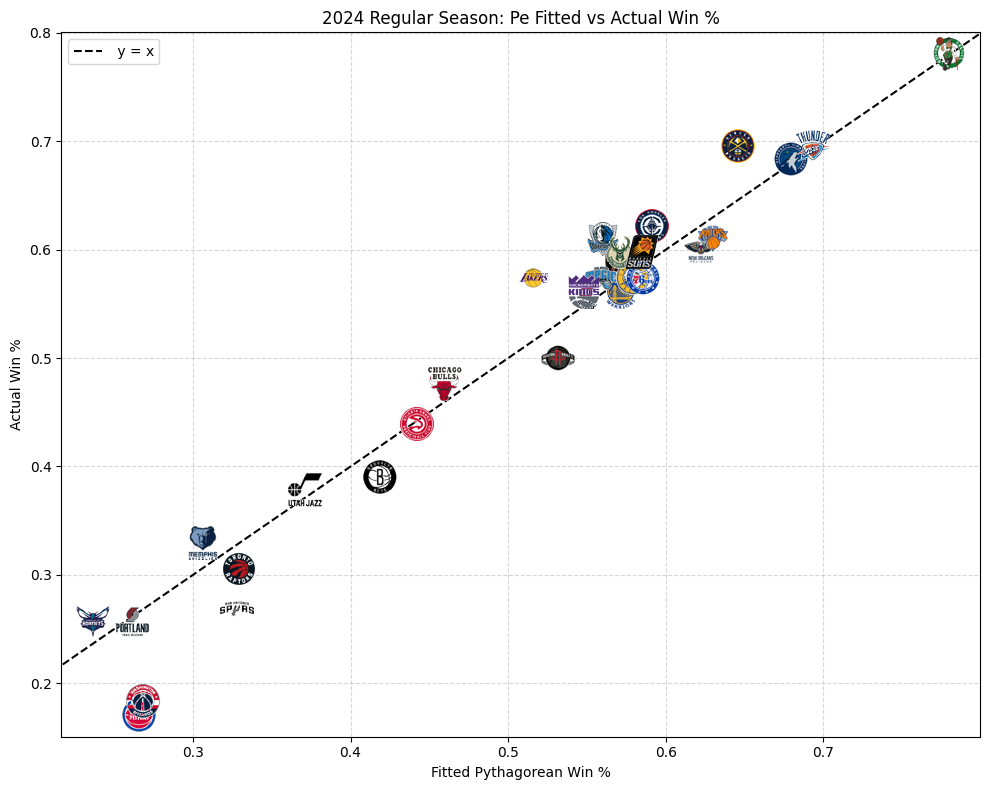

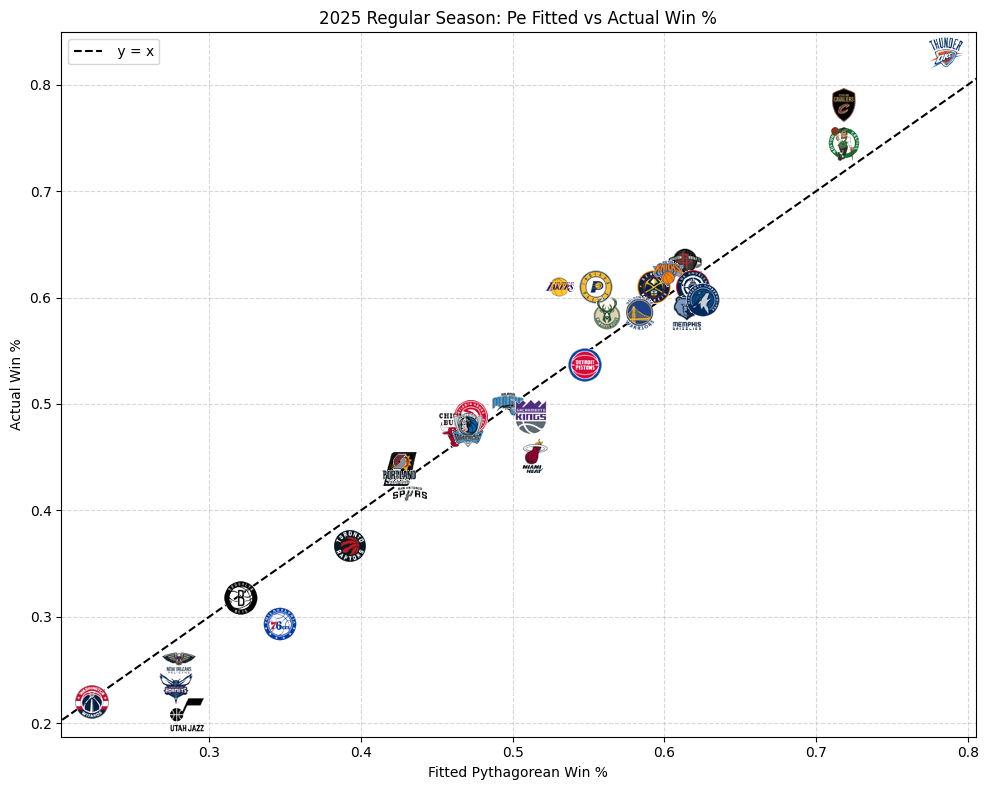

In [20]:
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

logo_folder = "team_logos"  # Folder with PNG logos

# Loop through each season
for season, df in pe_comparison_by_season.items():
    x = df['PE_Fitted']
    y = df['Win%']
    teams = df['Team']

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(x.min() - 0.02, x.max() + 0.02)
    ax.set_ylim(y.min() - 0.02, y.max() + 0.02)

    ax.set_xlabel("Fitted Pythagorean Win %")
    ax.set_ylabel("Actual Win %")
    ax.set_title(f"{season} Regular Season: Pe Fitted vs Actual Win %")
    ax.grid(True, linestyle='--', alpha=0.5)

    # Ideal reference line (y = x)
    ax.plot([0, 1], [0, 1], linestyle='--', color='black', label=' y = x')
    ax.legend(loc='upper left')

    for xi, yi, code in zip(x, y, teams):
        logo_path = os.path.join(logo_folder, f"{code}.png")
        if os.path.exists(logo_path):
            img = Image.open(logo_path).convert("RGBA")
            img = img.resize((40, 40), Image.Resampling.LANCZOS)
            img = make_white_transparent(img)
            im = OffsetImage(img, zoom=0.6)
            ab = AnnotationBbox(im, (xi, yi), frameon=False)
            ax.add_artist(ab)
        else:
            # fallback marker
            ax.plot(xi, yi, marker='o', color='red')
            ax.text(xi, yi, code, fontsize=8, ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

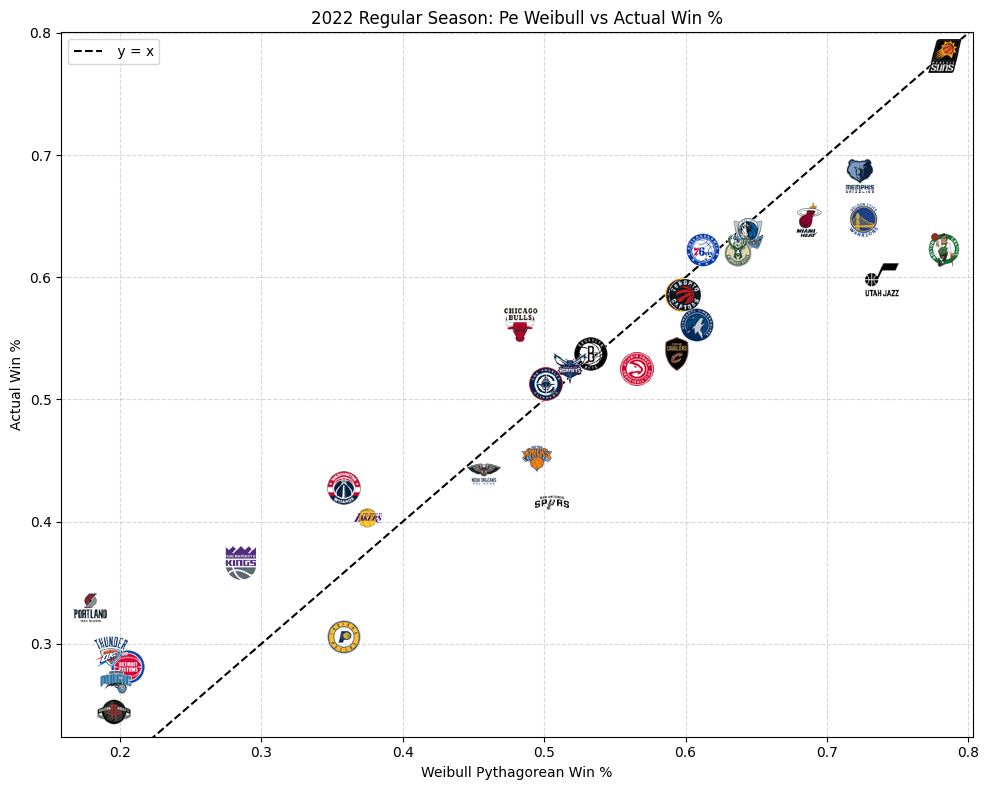

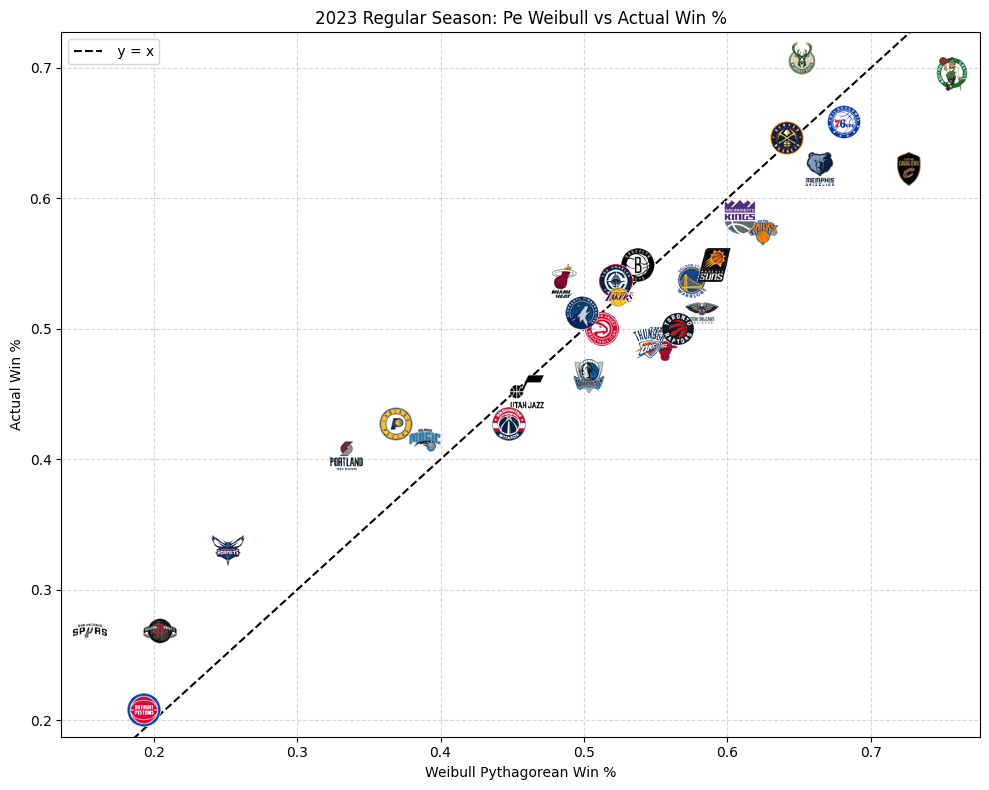

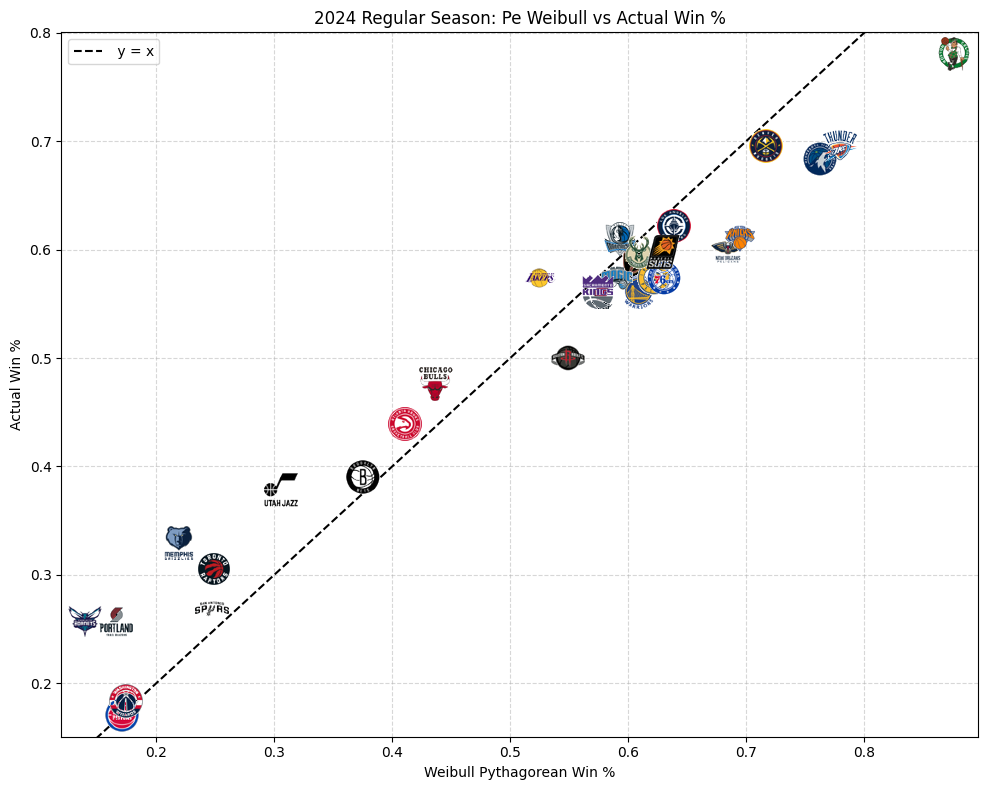

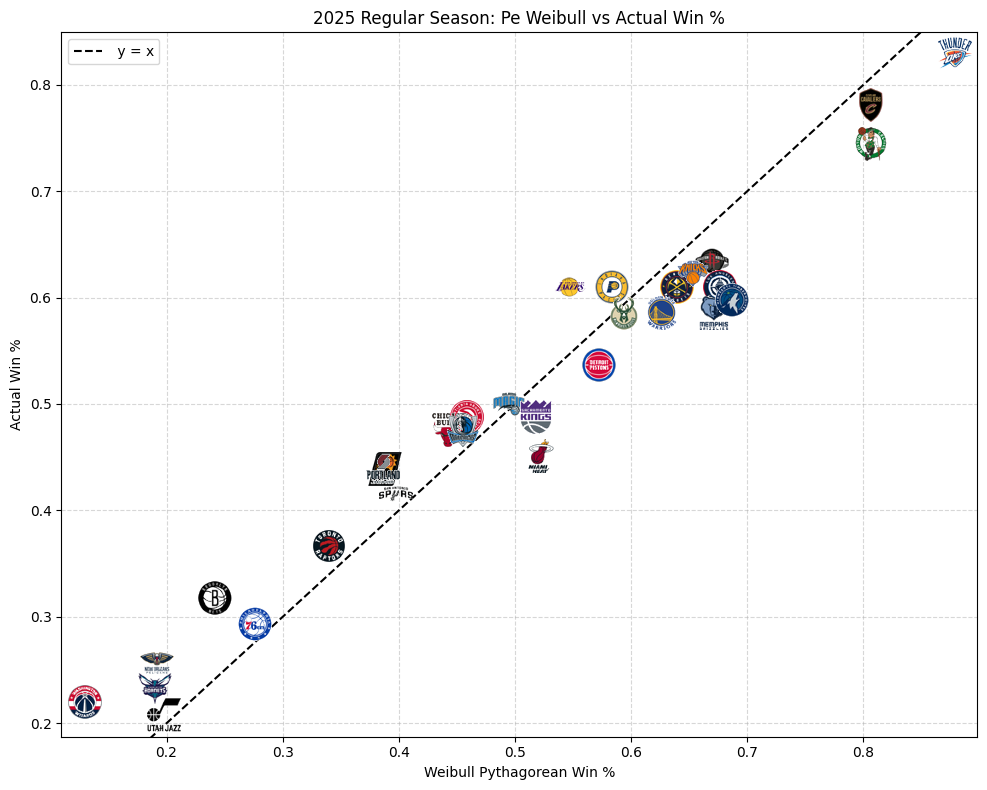

In [21]:
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

logo_folder = "team_logos"  # Folder with PNG logos

# Loop through each season
for season, df in pe_comparison_by_season.items():
    x = df['PE_Weibull']
    y = df['Win%']
    teams = df['Team']

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(x.min() - 0.02, x.max() + 0.02)
    ax.set_ylim(y.min() - 0.02, y.max() + 0.02)

    ax.set_xlabel("Weibull Pythagorean Win %")
    ax.set_ylabel("Actual Win %")
    ax.set_title(f"{season} Regular Season: Pe Weibull vs Actual Win %")
    ax.grid(True, linestyle='--', alpha=0.5)

    # Ideal reference line (y = x)
    ax.plot([0, 1], [0, 1], linestyle='--', color='black', label=' y = x')
    ax.legend(loc='upper left')

    for xi, yi, code in zip(x, y, teams):
        logo_path = os.path.join(logo_folder, f"{code}.png")
        if os.path.exists(logo_path):
            img = Image.open(logo_path).convert("RGBA")
            img = img.resize((40, 40), Image.Resampling.LANCZOS)
            img = make_white_transparent(img)
            im = OffsetImage(img, zoom=0.6)
            ab = AnnotationBbox(im, (xi, yi), frameon=False)
            ax.add_artist(ab)
        else:
            # fallback marker
            ax.plot(xi, yi, marker='o', color='red')
            ax.text(xi, yi, code, fontsize=8, ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

## Performing Pe (Post Season)

In [22]:
pe_comparison_by_postseason = {}

for season in seasons:
    df_name = f"gamelog_post_{season}"
    if df_name not in globals():
        continue
    
    df = globals()[df_name].copy()
    if not {'Tm', 'Opp.1', 'Rslt'}.issubset(df.columns):
        continue

    df['Win'] = df['Rslt'].fillna('').str.startswith('W').astype(int)
    
    team_stats = df.groupby('Team').agg(
        Points_For=('Tm', 'sum'),
        Points_Against=('Opp.1', 'sum'),
        Wins=('Win', 'sum'),
        Games=('Win', 'count')
    ).reset_index()
    
    team_stats['Win%'] = team_stats['Wins'] / team_stats['Games']

    # Pull fitted and Weibull exponents (already computed)
    fitted_exp = exponent_by_postseason.get(season)
    weibull_exp = weibull_info_by_postseason.get(season, {}).get('pyt_exp_weibull')

    if fitted_exp is None or weibull_exp is None:
        continue

    PF = team_stats['Points_For']
    PA = team_stats['Points_Against']

    team_stats['PE_Fitted'] = PF**fitted_exp / (PF**fitted_exp + PA**fitted_exp)
    team_stats['PE_Weibull'] = PF**weibull_exp / (PF**weibull_exp + PA**weibull_exp)

    team_stats['Δ Fitted'] = team_stats['Win%'] - team_stats['PE_Fitted']
    team_stats['Δ Weibull'] = team_stats['Win%'] - team_stats['PE_Weibull']
    team_stats['Diff (Weibull - Fitted)'] = team_stats['PE_Weibull'] - team_stats['PE_Fitted']

    pe_comparison_by_postseason[season] = team_stats[[
        'Team', 'Win%', 'PE_Fitted', 'PE_Weibull',
        'Δ Fitted', 'Δ Weibull', 'Diff (Weibull - Fitted)'
    ]].copy()

In [23]:
pe_comparison_by_postseason[2025]

,Team,Win%,PE_Fitted,PE_Weibull,Δ Fitted,Δ Weibull,Diff (Weibull - Fitted)
0,BOS,0.545455,0.649802,0.719561,-0.104348,-0.174106,0.069759
1,CLE,0.555556,0.764819,0.857857,-0.209264,-0.302301,0.093037
2,DEN,0.500000,0.375341,0.315088,0.124659,0.184912,-0.060253
3,DET,0.333333,0.464427,0.445896,-0.131093,-0.112562,-0.018531
4,GSW,0.416667,0.418446,0.377133,-0.001780,0.039534,-0.041313
5,HOU,0.428571,0.500000,0.500000,-0.071429,-0.071429,0.000000
6,IND,0.652174,0.551660,0.578376,0.100514,0.073798,0.026716
7,LAC,0.428571,0.515172,0.523118,-0.086601,-0.094547,0.007946
8,LAL,0.200000,0.315762,0.235272,-0.115762,-0.035272,-0.080490
9,MEM,0.000000,0.115606,0.043044,-0.115606,-0.043044,-0.072562


In [24]:
# Combine all postseason season DataFrames
pe_post_all = pd.concat(pe_comparison_by_postseason.values(), ignore_index=True)

# Estimate game count if exact values aren't stored
pe_post_all['Games'] = pe_post_all['Win%'] * pe_post_all[['PE_Fitted', 'PE_Weibull']].count(axis=1)

# Group by team and compute weighted totals
team_agg_post = pe_post_all.groupby('Team').agg(
    Seasons=('Win%', 'count'),
    Total_Games=('Games', 'sum'),
    Total_Wins=('Win%', lambda x: (x * pe_post_all.loc[x.index, 'Games']).sum()),
    PE_Fitted_Total=('PE_Fitted', lambda x: (x * pe_post_all.loc[x.index, 'Games']).sum()),
    PE_Weibull_Total=('PE_Weibull', lambda x: (x * pe_post_all.loc[x.index, 'Games']).sum())
).reset_index()

# Compute averages
team_agg_post['Avg Win%'] = team_agg_post['Total_Wins'] / team_agg_post['Total_Games']
team_agg_post['Avg PE_Fitted'] = team_agg_post['PE_Fitted_Total'] / team_agg_post['Total_Games']
team_agg_post['Avg PE_Weibull'] = team_agg_post['PE_Weibull_Total'] / team_agg_post['Total_Games']
team_agg_post['Δ Fitted'] = team_agg_post['Avg Win%'] - team_agg_post['Avg PE_Fitted']
team_agg_post['Δ Weibull'] = team_agg_post['Avg Win%'] - team_agg_post['Avg PE_Weibull']
team_agg_post['Diff (Weibull - Fitted)'] = team_agg_post['Avg PE_Weibull'] - team_agg_post['Avg PE_Fitted']

# Sort and filter columns
team_agg_post = team_agg_post.sort_values('Avg Win%', ascending=False).reset_index(drop=True)

team_agg_post = team_agg_post[[
    'Team', 'Seasons', 'Avg Win%', 'Avg PE_Fitted', 'Avg PE_Weibull',
    'Δ Fitted', 'Δ Weibull', 'Diff (Weibull - Fitted)'
]]

print(team_agg_post.round(4))

   Team  Seasons  Avg Win%  Avg PE_Fitted  Avg PE_Weibull  Δ Fitted  \
0   BOS        4    0.6543         0.6668          0.7235   -0.0125   
1   OKC        2    0.6514         0.6961          0.7812   -0.0447   
2   DEN        4    0.6097         0.5422          0.5225    0.0676   
3   IND        2    0.5761         0.5425          0.5649    0.0336   
4   GSW        3    0.5703         0.5529          0.5597    0.0174   
5   DAL        2    0.5492         0.5542          0.5800   -0.0050   
6   NYK        3    0.5466         0.4859          0.4759    0.0607   
7   PHO        3    0.5420         0.4389          0.4295    0.1031   
8   MIA        4    0.5325         0.5316          0.5383    0.0009   
9   PHI        3    0.5212         0.4743          0.4715    0.0470   
10  MIN        4    0.4880         0.4951          0.5179   -0.0071   
11  CLE        3    0.4455         0.5259          0.5378   -0.0804   
12  MEM        3    0.4333         0.4388          0.4417   -0.0055   
13  SA

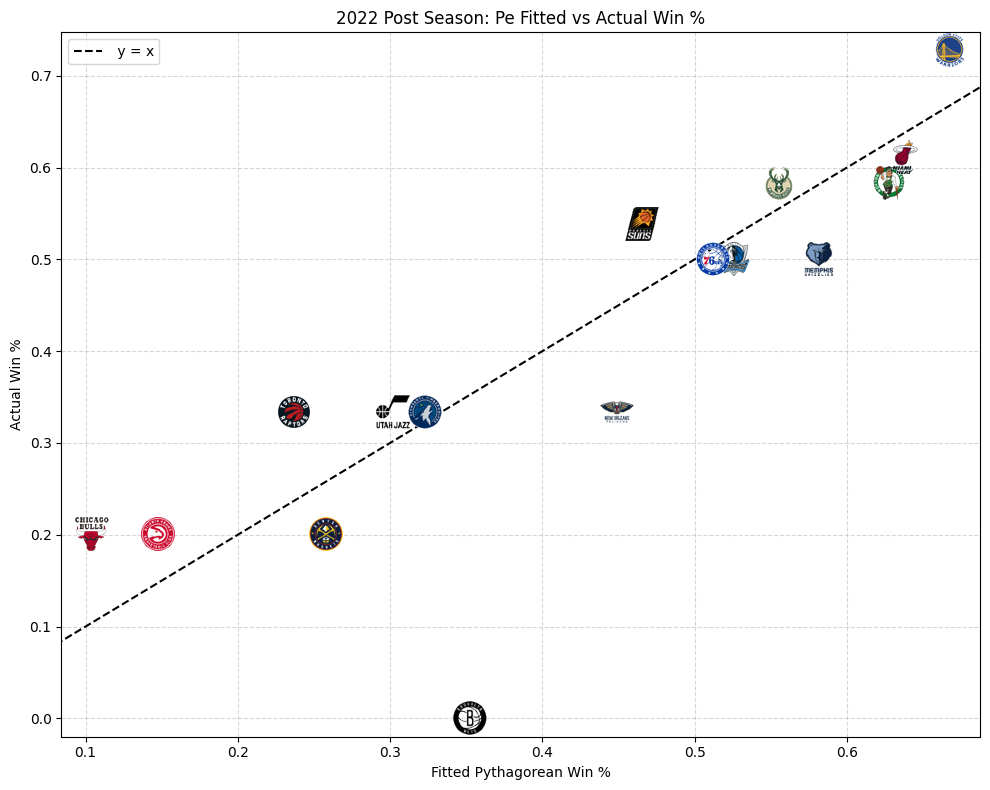

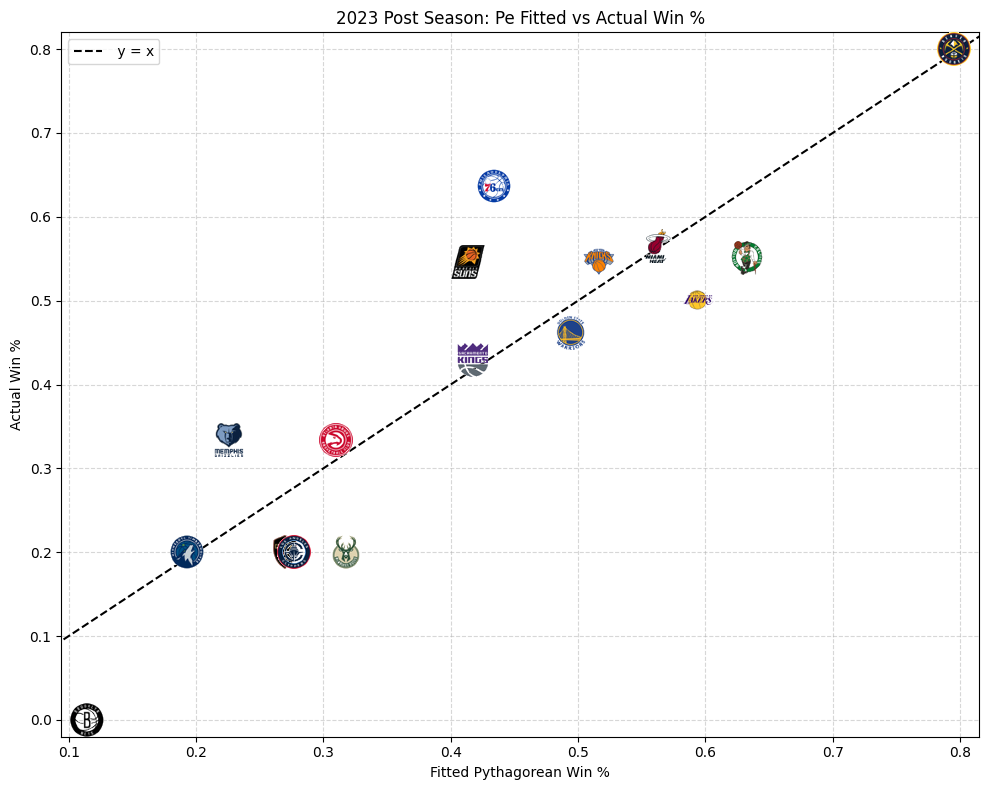

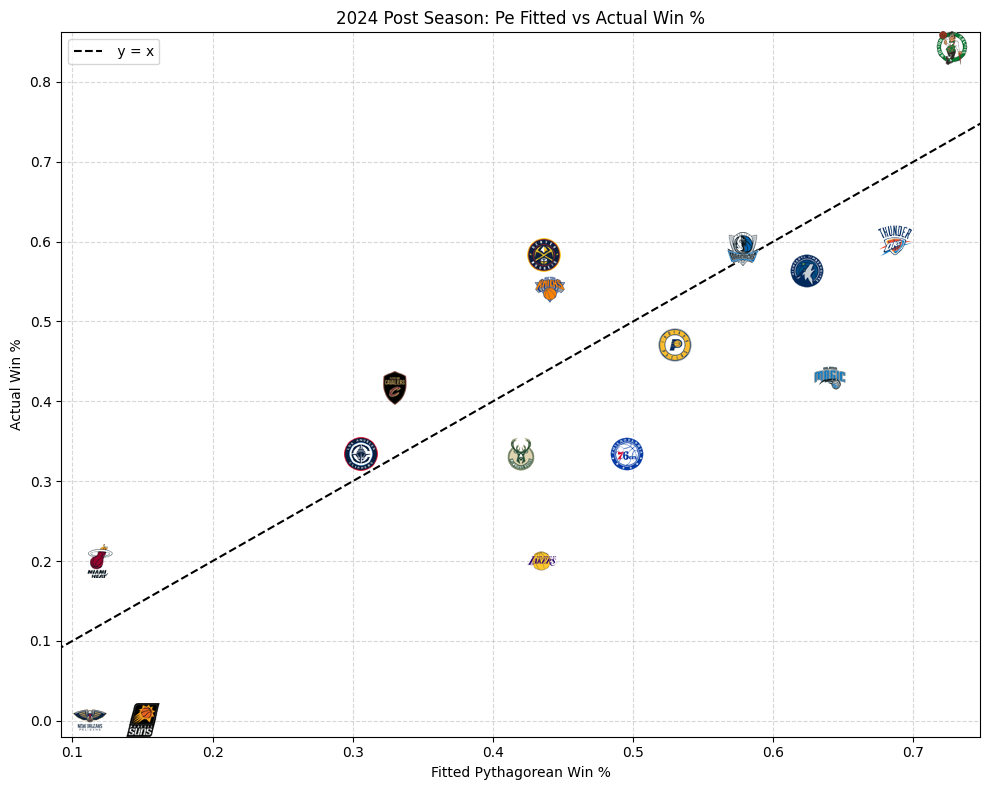

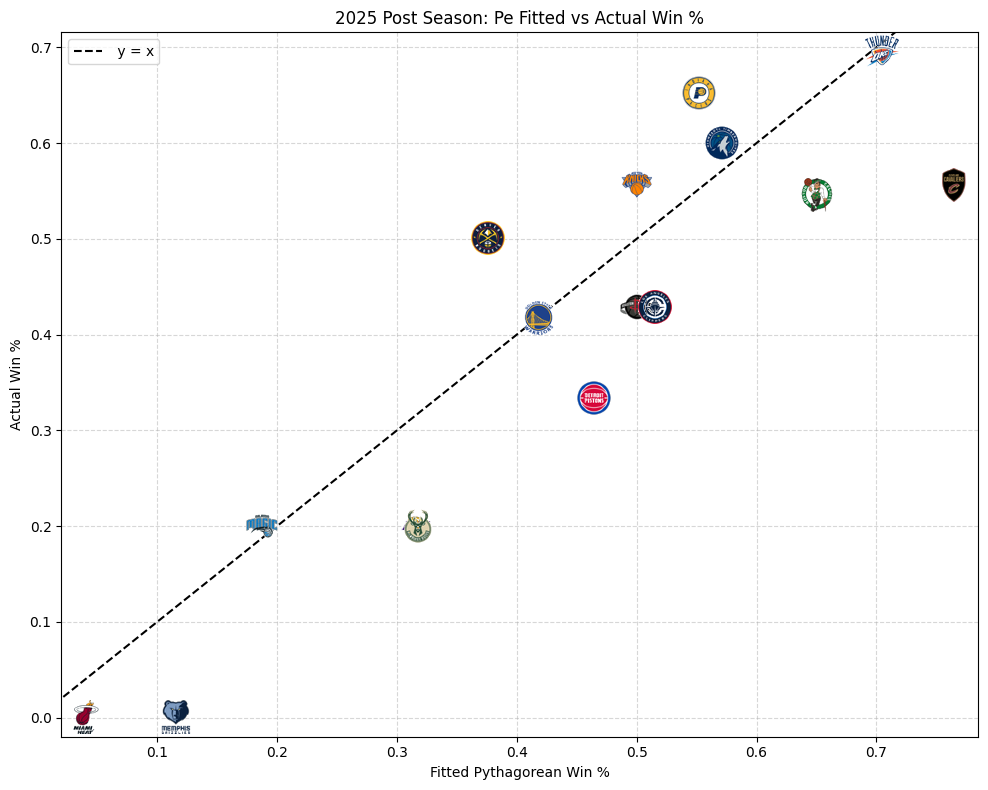

In [25]:
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

logo_folder = "team_logos"  # Folder with PNG logos

# Loop through each season
for season, df in pe_comparison_by_postseason.items():
    x = df['PE_Fitted']
    y = df['Win%']
    teams = df['Team']

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(x.min() - 0.02, x.max() + 0.02)
    ax.set_ylim(y.min() - 0.02, y.max() + 0.02)

    ax.set_xlabel("Fitted Pythagorean Win %")
    ax.set_ylabel("Actual Win %")
    ax.set_title(f"{season} Post Season: Pe Fitted vs Actual Win %")
    ax.grid(True, linestyle='--', alpha=0.5)

    # Ideal reference line (y = x)
    ax.plot([0, 1], [0, 1], linestyle='--', color='black', label=' y = x')
    ax.legend(loc='upper left')

    for xi, yi, code in zip(x, y, teams):
        logo_path = os.path.join(logo_folder, f"{code}.png")
        if os.path.exists(logo_path):
            img = Image.open(logo_path).convert("RGBA")
            img = img.resize((40, 40), Image.Resampling.LANCZOS)
            img = make_white_transparent(img)
            im = OffsetImage(img, zoom=0.6)
            ab = AnnotationBbox(im, (xi, yi), frameon=False)
            ax.add_artist(ab)
        else:
            # fallback marker
            ax.plot(xi, yi, marker='o', color='red')
            ax.text(xi, yi, code, fontsize=8, ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

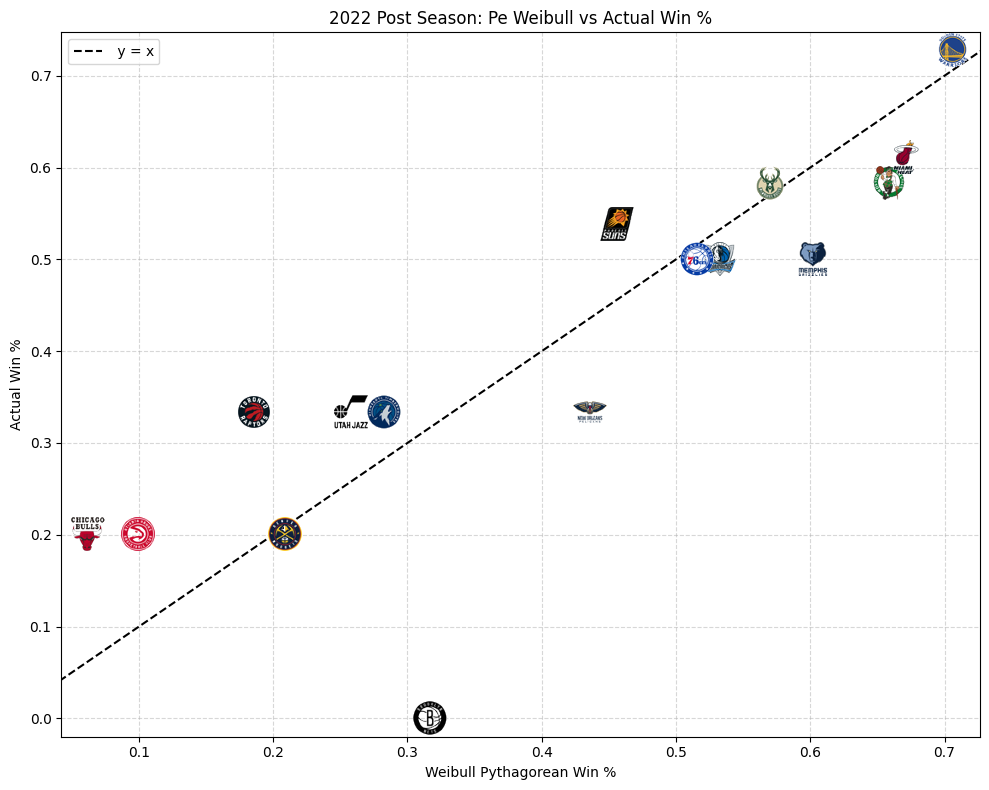

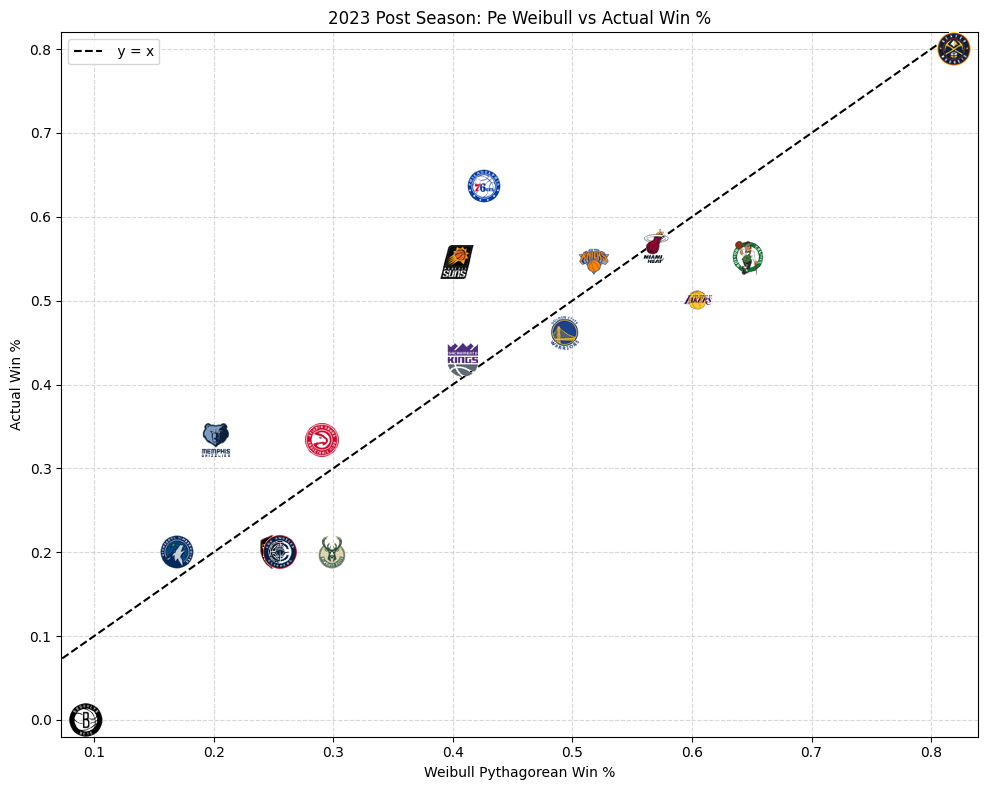

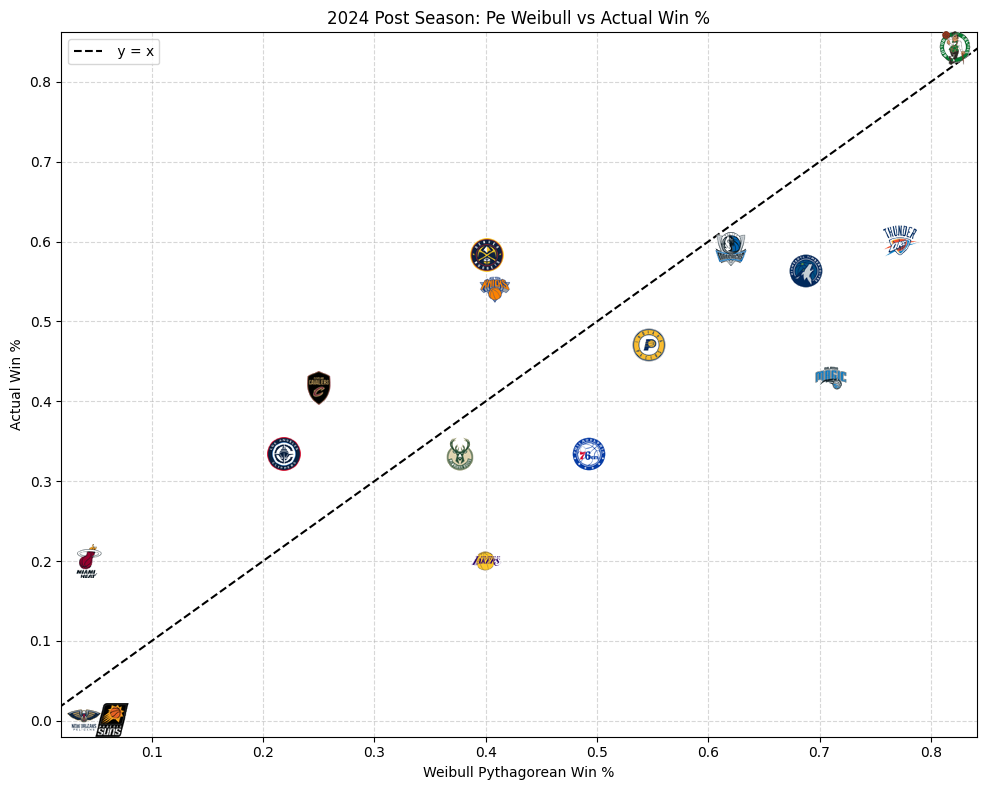

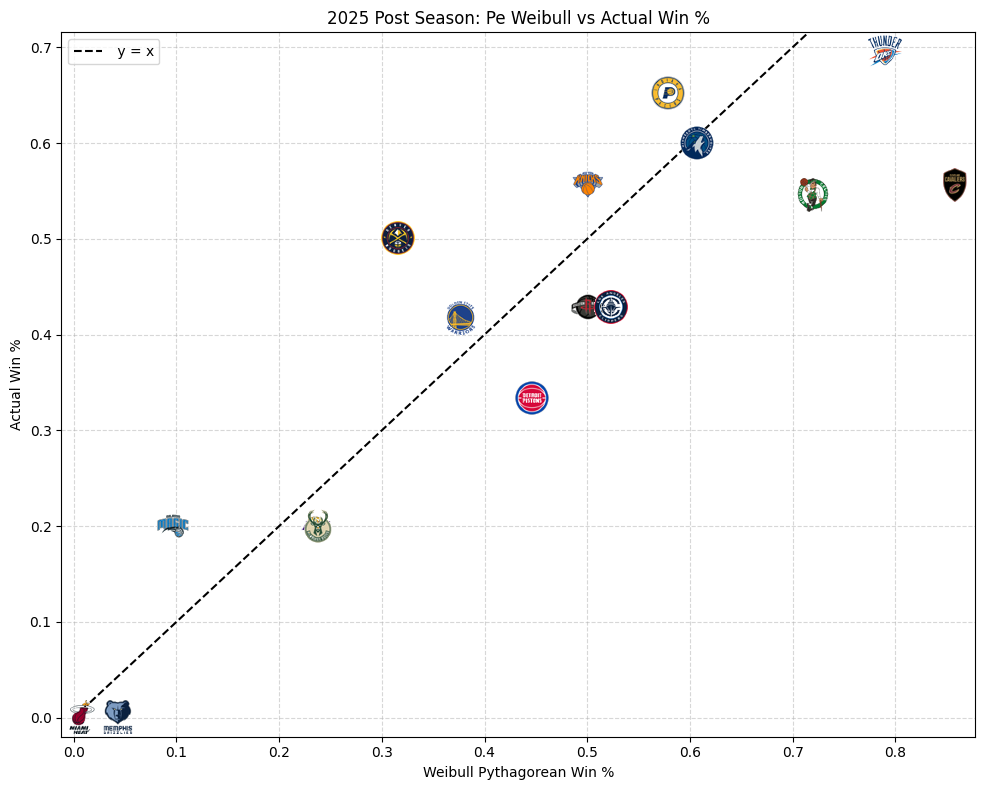

In [26]:
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

logo_folder = "team_logos"  # Folder with PNG logos

# Loop through each season
for season, df in pe_comparison_by_postseason.items():
    x = df['PE_Weibull']
    y = df['Win%']
    teams = df['Team']

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(x.min() - 0.02, x.max() + 0.02)
    ax.set_ylim(y.min() - 0.02, y.max() + 0.02)

    ax.set_xlabel("Weibull Pythagorean Win %")
    ax.set_ylabel("Actual Win %")
    ax.set_title(f"{season} Post Season: Pe Weibull vs Actual Win %")
    ax.grid(True, linestyle='--', alpha=0.5)

    # Ideal reference line (y = x)
    ax.plot([0, 1], [0, 1], linestyle='--', color='black', label=' y = x')
    ax.legend(loc='upper left')

    for xi, yi, code in zip(x, y, teams):
        logo_path = os.path.join(logo_folder, f"{code}.png")
        if os.path.exists(logo_path):
            img = Image.open(logo_path).convert("RGBA")
            img = img.resize((40, 40), Image.Resampling.LANCZOS)
            img = make_white_transparent(img)
            im = OffsetImage(img, zoom=0.6)
            ab = AnnotationBbox(im, (xi, yi), frameon=False)
            ax.add_artist(ab)
        else:
            # fallback marker
            ax.plot(xi, yi, marker='o', color='red')
            ax.text(xi, yi, code, fontsize=8, ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

## Pe Fitted Linear Regression Validation Tests

In [27]:
actual = team_agg['Avg Win%']
predicted = team_agg['Avg PE_Fitted']

rs_mae = mean_absolute_error(actual, predicted)
rs_rmse = np.sqrt(mean_squared_error(actual, predicted))

print(f"MAE: {rs_mae:.4f}")
print(f"RMSE: {rs_rmse:.4f}")

MAE: 0.0169
RMSE: 0.0210


In [28]:
rs_r2 = r2_score(actual, predicted)
print(f"R² Score: {rs_r2:.4f}")

R² Score: 0.9508


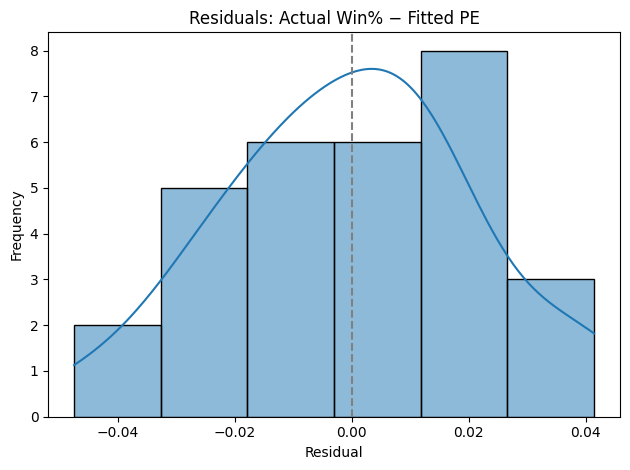

In [29]:
residuals = actual - predicted
sns.histplot(residuals, kde=True)
plt.axvline(0, color='gray', linestyle='--')
plt.title("Residuals: Actual Win% − Fitted PE")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [30]:
season_errors = []

for season, df in pe_comparison_by_season.items():
    y_true = df['Win%']
    y_pred = df['PE_Fitted']
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    season_errors.append({'Season': season, 'RMSE': rmse})

cv_df = pd.DataFrame(season_errors).sort_values('Season')
print(cv_df)

   Season      RMSE
0    2022  0.048313
1    2023  0.043129
2    2024  0.034431
3    2025  0.035286


In [31]:
X = team_agg[['Avg PE_Fitted']].values
y = team_agg['Avg Win%'].values

model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Negative MSE, so we take the square root and negate it
scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=cv)
rmse_scores = np.sqrt(-scores)

print("Fold RMSEs:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

Fold RMSEs: [0.01640621 0.0301115  0.0141346  0.02297752 0.02283222]
Mean RMSE: 0.021292408803939657


In [32]:
train_years = [2022, 2023, 2024]
test_year = 2025

train_df = pd.concat([pe_comparison_by_season[yr] for yr in train_years], ignore_index=True)
test_df = pe_comparison_by_season[test_year].copy()

# Features and target
X_train = train_df[['PE_Fitted']]
y_train = train_df['Win%']

X_test = test_df[['PE_Fitted']]
y_test = test_df['Win%']

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test)

rs_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rs_mae = mean_absolute_error(y_test, y_pred)
rs_r2 = r2_score(y_test, y_pred)

print(f"Test RMSE (2025): {rs_rmse:.4f}")
print(f"Test MAE  (2025): {rs_mae:.4f}")
print(f"Test R²   (2025): {rs_r2:.4f}")

Test RMSE (2025): 0.0416
Test MAE  (2025): 0.0329
Test R²   (2025): 0.9326


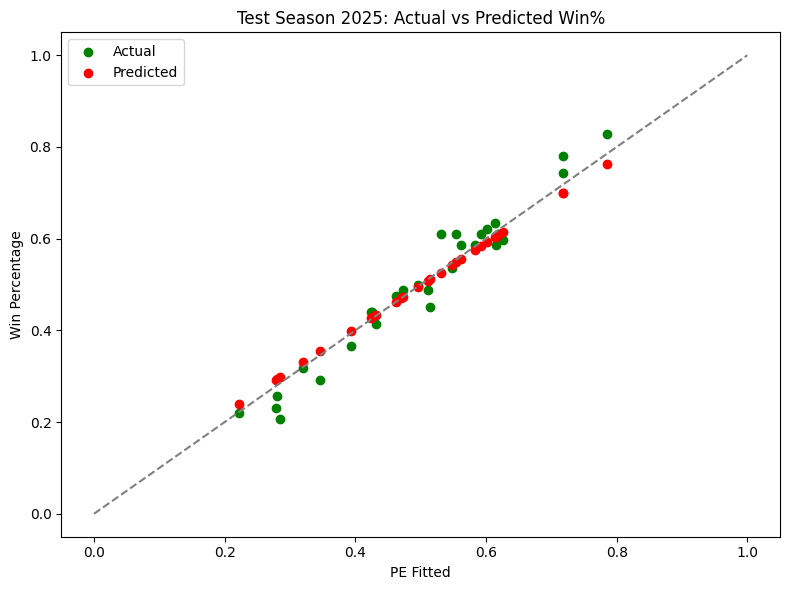

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(X_test['PE_Fitted'], y_test, label="Actual", color='green')
plt.scatter(X_test['PE_Fitted'], y_pred, label="Predicted", color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("PE Fitted")
plt.ylabel("Win Percentage")
plt.title("Test Season 2025: Actual vs Predicted Win%")
plt.legend()
plt.tight_layout()
plt.show()

## Pe Weibull Linear Regression Validation Tests

In [36]:
train_years = [2022, 2023, 2024]
test_year = 2025

train_df = pd.concat([pe_comparison_by_season[yr] for yr in train_years], ignore_index=True)
test_df = pe_comparison_by_season[test_year].copy()

# Set features and targets
X_train = train_df[['PE_Weibull']]
y_train = train_df['Win%']

X_test = test_df[['PE_Weibull']]
y_test = test_df['Win%']

In [37]:
weibull_model = LinearRegression()
weibull_model.fit(X_train, y_train)

LinearRegression()

In [38]:
y_pred = weibull_model.predict(X_test)

weibull_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
weibull_mae = mean_absolute_error(y_test, y_pred)
weibull_r2 = r2_score(y_test, y_pred)

print(f"Weibull Model — Test Season (2025):")
print(f"  RMSE: {weibull_rmse:.4f}")
print(f"  MAE : {weibull_mae:.4f}")
print(f"  R²  : {weibull_r2:.4f}")

Weibull Model — Test Season (2025):
  RMSE: 0.0331
  MAE : 0.0266
  R²  : 0.9572


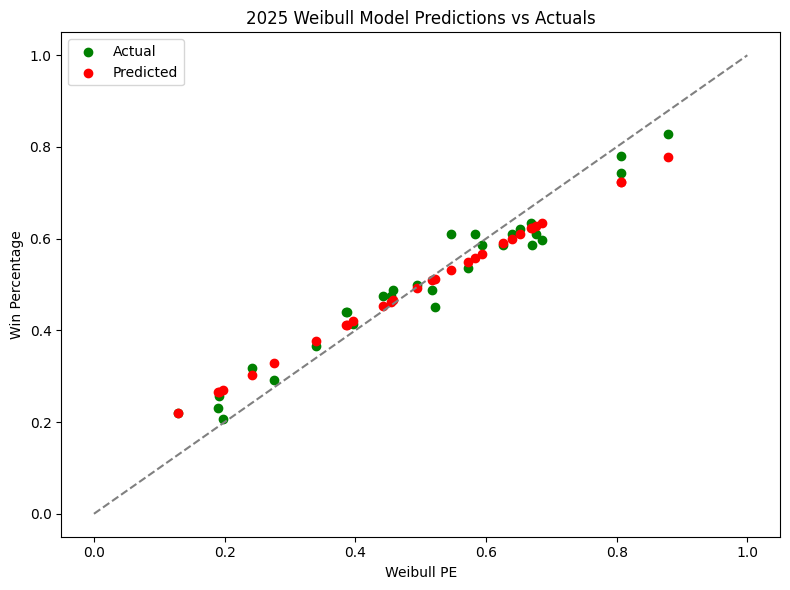

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(X_test['PE_Weibull'], y_test, label="Actual", color='green')
plt.scatter(X_test['PE_Weibull'], y_pred, label="Predicted", color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Weibull PE")
plt.ylabel("Win Percentage")
plt.title("2025 Weibull Model Predictions vs Actuals")
plt.legend()
plt.tight_layout()
plt.show()

## Post Season

In [40]:
train_years = [2022, 2023, 2024]
test_year = 2025

train_df = pd.concat([pe_comparison_by_postseason[y] for y in train_years], ignore_index=True)
test_df = pe_comparison_by_postseason[test_year].copy()

# Train and evaluate for Fitted PE
X_train = train_df[['PE_Fitted']]
y_train = train_df['Win%']
X_test = test_df[['PE_Fitted']]
y_test = test_df['Win%']

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Fitted PE — Postseason Test (2025):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"  MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"  R²  : {r2_score(y_test, y_pred):.4f}")

Fitted PE — Postseason Test (2025):
  RMSE: 0.0920
  MAE : 0.0801
  R²  : 0.8111


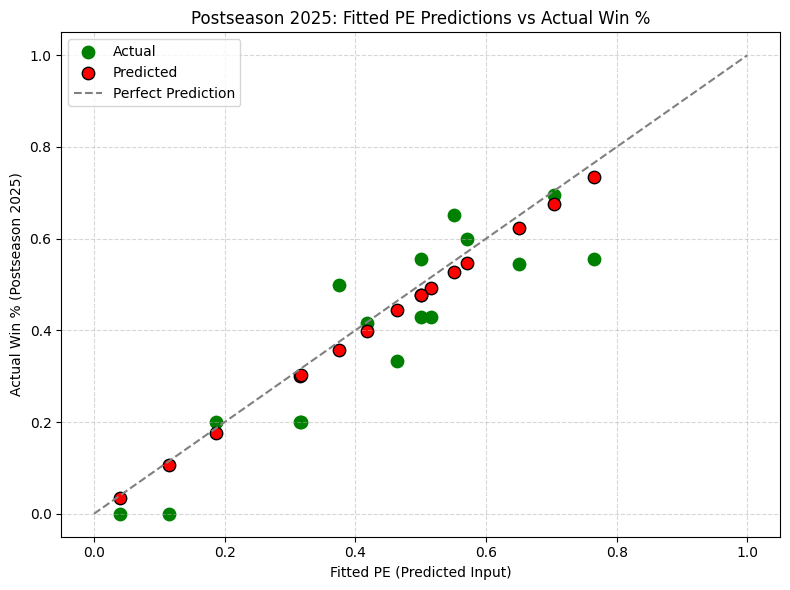

In [41]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test['PE_Fitted'], y_test, label='Actual', color='green', s=80)
plt.scatter(X_test['PE_Fitted'], y_pred, label='Predicted', color='red', edgecolor='k', s=80)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Perfect Prediction')

plt.xlabel("Fitted PE (Predicted Input)")
plt.ylabel("Actual Win % (Postseason 2025)")
plt.title("Postseason 2025: Fitted PE Predictions vs Actual Win %")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [42]:
X_train_w = train_df[['PE_Weibull']]
X_test_w = test_df[['PE_Weibull']]

weibull_model = LinearRegression()
weibull_model.fit(X_train_w, y_train)
y_pred_w = weibull_model.predict(X_test_w)

print("Weibull PE — Postseason Test (2025):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_w)):.4f}")
print(f"  MAE : {mean_absolute_error(y_test, y_pred_w):.4f}")
print(f"  R²  : {r2_score(y_test, y_pred_w):.4f}")

Weibull PE — Postseason Test (2025):
  RMSE: 0.0969
  MAE : 0.0838
  R²  : 0.7903


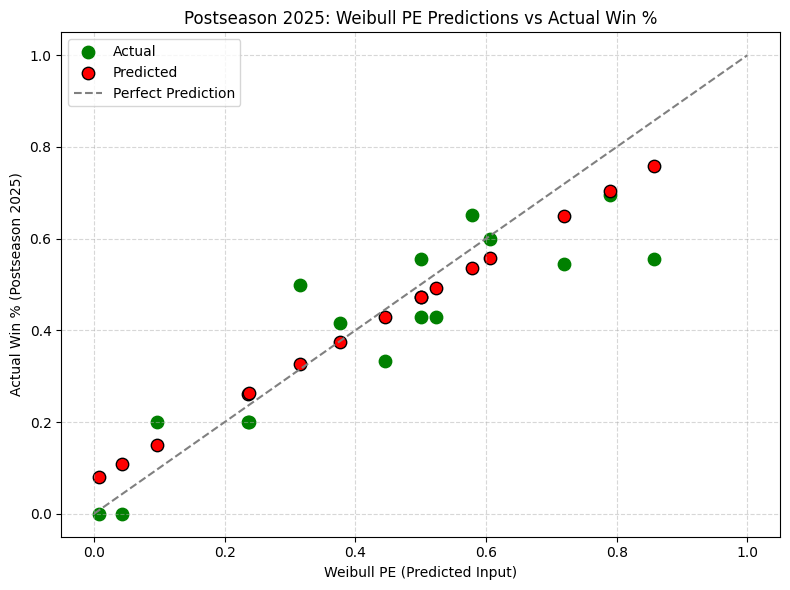

In [43]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test_w['PE_Weibull'], y_test, label='Actual', color='green', s=80)
plt.scatter(X_test_w['PE_Weibull'], y_pred_w, label='Predicted', color='red', edgecolor='k', s=80)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Perfect Prediction')

plt.xlabel("Weibull PE (Predicted Input)")
plt.ylabel("Actual Win % (Postseason 2025)")
plt.title("Postseason 2025: Weibull PE Predictions vs Actual Win %")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Comparison

In [44]:
comparison_df = pd.DataFrame({
    'Model': ['Fitted PE', 'Weibull PE'],
    'RMSE': [rs_rmse, weibull_rmse],
    'MAE': [rs_mae, weibull_mae],
    'R²': [rs_r2, weibull_r2]
})

display("Regular Season Pe Model Results")
display(comparison_df.round(4))

'Regular Season Pe Model Results'

,Model,RMSE,MAE,R²
0,Fitted PE,0.0416,0.0329,0.9326
1,Weibull PE,0.0331,0.0266,0.9572


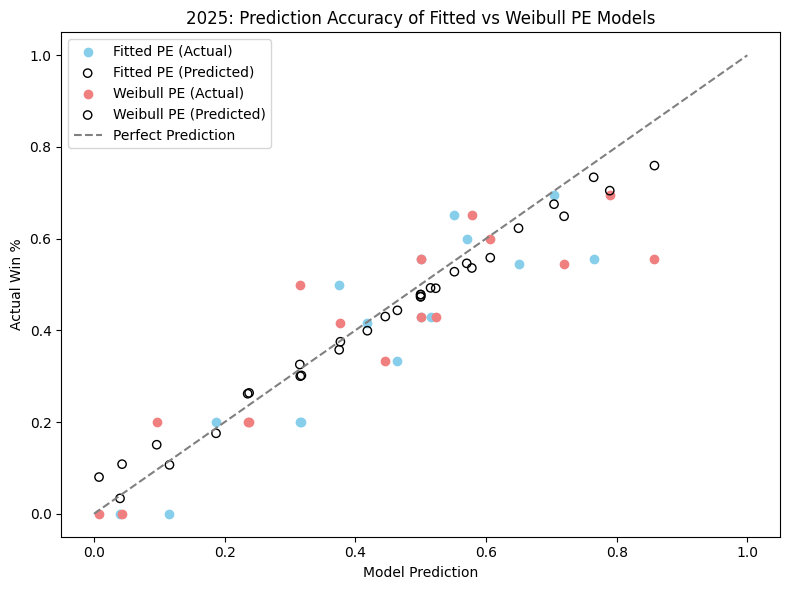

In [45]:
plt.figure(figsize=(8,6))

# Fitted PE
plt.scatter(test_df['PE_Fitted'], y_test, label='Fitted PE (Actual)', color='skyblue')
plt.scatter(test_df['PE_Fitted'], model.predict(test_df[['PE_Fitted']]),
            label='Fitted PE (Predicted)', edgecolor='k', facecolor='none')

# Weibull PE
plt.scatter(test_df['PE_Weibull'], y_test, label='Weibull PE (Actual)', color='lightcoral')
plt.scatter(test_df['PE_Weibull'], weibull_model.predict(test_df[['PE_Weibull']]),
            label='Weibull PE (Predicted)', edgecolor='k', facecolor='none')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Prediction')
plt.xlabel("Model Prediction")
plt.ylabel("Actual Win %")
plt.title("2025: Prediction Accuracy of Fitted vs Weibull PE Models")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# For Fitted PE model
rmse_post = np.sqrt(mean_squared_error(y_test, y_pred))
mae_post = mean_absolute_error(y_test, y_pred)
r2_post = r2_score(y_test, y_pred)

# For Weibull PE model
weibull_rmse_post = np.sqrt(mean_squared_error(y_test, y_pred_w))
weibull_mae_post = mean_absolute_error(y_test, y_pred_w)
weibull_r2_post = r2_score(y_test, y_pred_w)

comparison_post_df = pd.DataFrame({
    'Model': ['Fitted PE (Postseason)', 'Weibull PE (Postseason)'],
    'RMSE': [rmse_post, weibull_rmse_post],
    'MAE': [mae_post, weibull_mae_post],
    'R²': [r2_post, weibull_r2_post]
})

display(comparison_post_df.round(4))

,Model,RMSE,MAE,R²
0,Fitted PE (Postseason),0.0920,0.0801,0.8111
1,Weibull PE (Postseason),0.0969,0.0838,0.7903


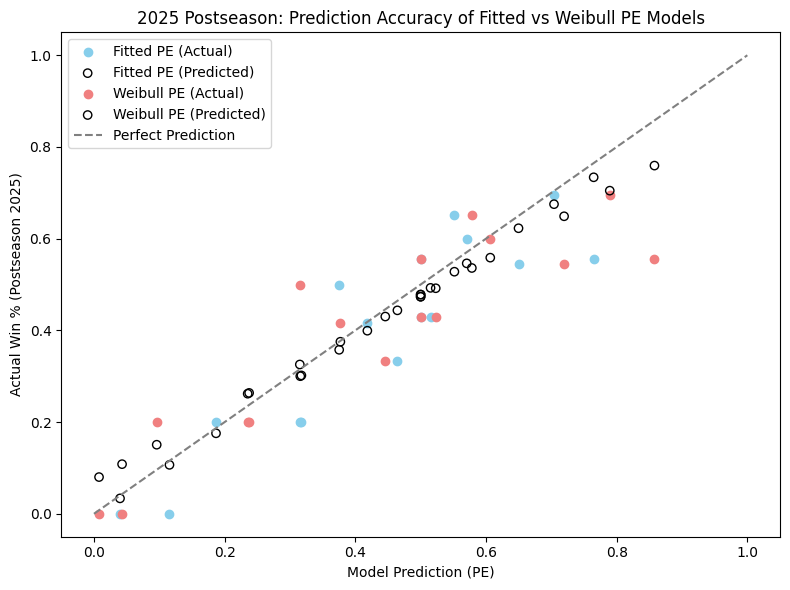

In [47]:
plt.figure(figsize=(8,6))

# Fitted PE (postseason)
plt.scatter(test_df['PE_Fitted'], y_test, label='Fitted PE (Actual)', color='skyblue')
plt.scatter(test_df['PE_Fitted'], model.predict(test_df[['PE_Fitted']]),
            label='Fitted PE (Predicted)', edgecolor='k', facecolor='none')

# Weibull PE (postseason)
plt.scatter(test_df['PE_Weibull'], y_test, label='Weibull PE (Actual)', color='lightcoral')
plt.scatter(test_df['PE_Weibull'], weibull_model.predict(test_df[['PE_Weibull']]),
            label='Weibull PE (Predicted)', edgecolor='k', facecolor='none')

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Prediction')

# Labels
plt.xlabel("Model Prediction (PE)")
plt.ylabel("Actual Win % (Postseason 2025)")
plt.title("2025 Postseason: Prediction Accuracy of Fitted vs Weibull PE Models")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
team_agg = team_agg.copy()
team_agg['Type'] = 'Regular Season'

team_agg_post = team_agg_post.copy()
team_agg_post['Type'] = 'Postseason'

combined = pd.concat([team_agg, team_agg_post], ignore_index=True)

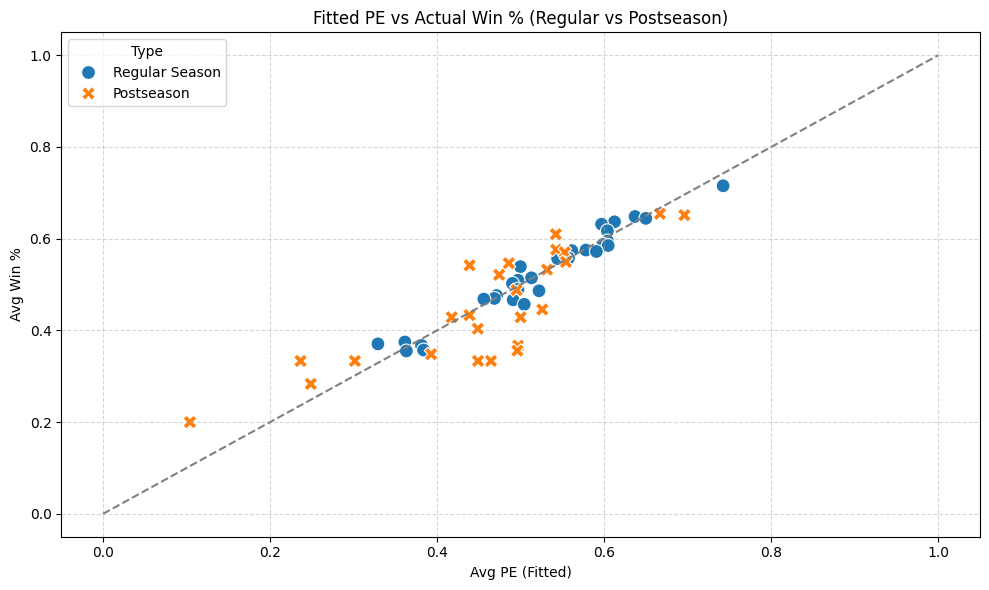

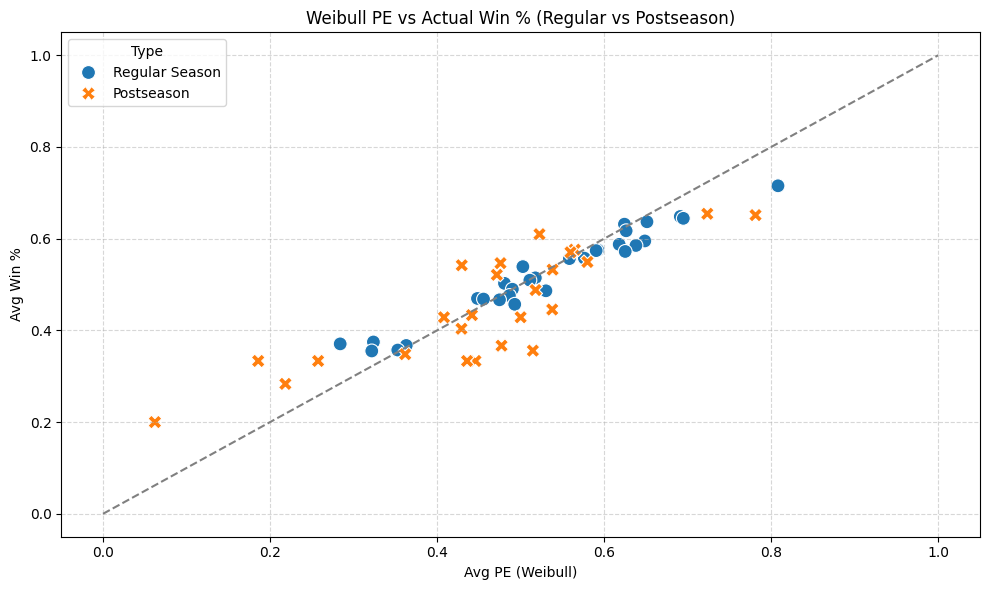

In [49]:
# Avg Win% vs Avg PE (Fitted)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined, x='Avg PE_Fitted', y='Avg Win%', hue='Type', style='Type', s=100)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("Fitted PE vs Actual Win % (Regular vs Postseason)")
plt.xlabel("Avg PE (Fitted)")
plt.ylabel("Avg Win %")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot: Avg Win% vs Avg PE (Weibull)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined, x='Avg PE_Weibull', y='Avg Win%', hue='Type', style='Type', s=100)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("Weibull PE vs Actual Win % (Regular vs Postseason)")
plt.xlabel("Avg PE (Weibull)")
plt.ylabel("Avg Win %")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

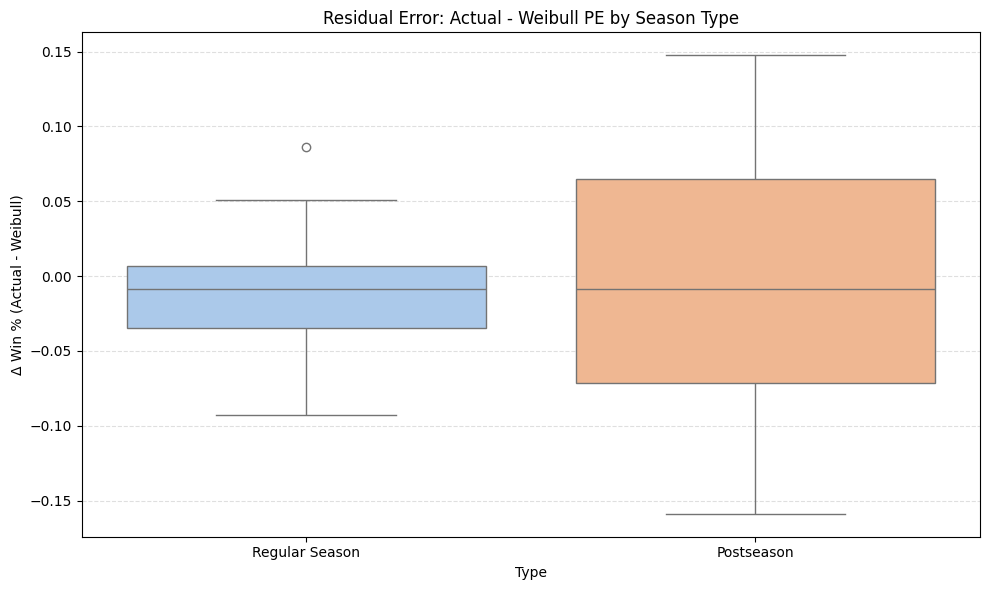

In [50]:
plt.figure(figsize=(10,6))
sns.boxplot(data=combined, x='Type', y='Δ Weibull', hue='Type', palette='pastel', legend=False)
plt.title("Residual Error: Actual - Weibull PE by Season Type")
plt.ylabel("Δ Win % (Actual - Weibull)")
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Adding randomness to the model to prove that the model is working sufficiently.

In [51]:
train_years = [2022, 2023, 2024]
test_year = 2025

train_df = pd.concat([pe_comparison_by_season[yr] for yr in train_years], ignore_index=True)
test_df = pe_comparison_by_season[test_year].copy()

X_train = train_df[['PE_Weibull']]
y_train = train_df['Win%']

X_test_true = test_df[['PE_Weibull']]
y_test = test_df['Win%']

# 2. Fit model on real data
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_true = model.predict(X_test_true)
r2_true = r2_score(y_test, y_pred_true)

# 3. Permutation test — shuffle test predictors and score R²
n_permutations = 1000
r2_shuffled = []

for _ in range(n_permutations):
    shuffled = np.random.permutation(X_test_true['PE_Weibull'].values)
    X_shuffled = pd.DataFrame({'PE_Weibull': shuffled})
    y_pred_shuffle = model.predict(X_shuffled)
    r2_shuffled.append(r2_score(y_test, y_pred_shuffle))

r2_shuffled = np.array(r2_shuffled)

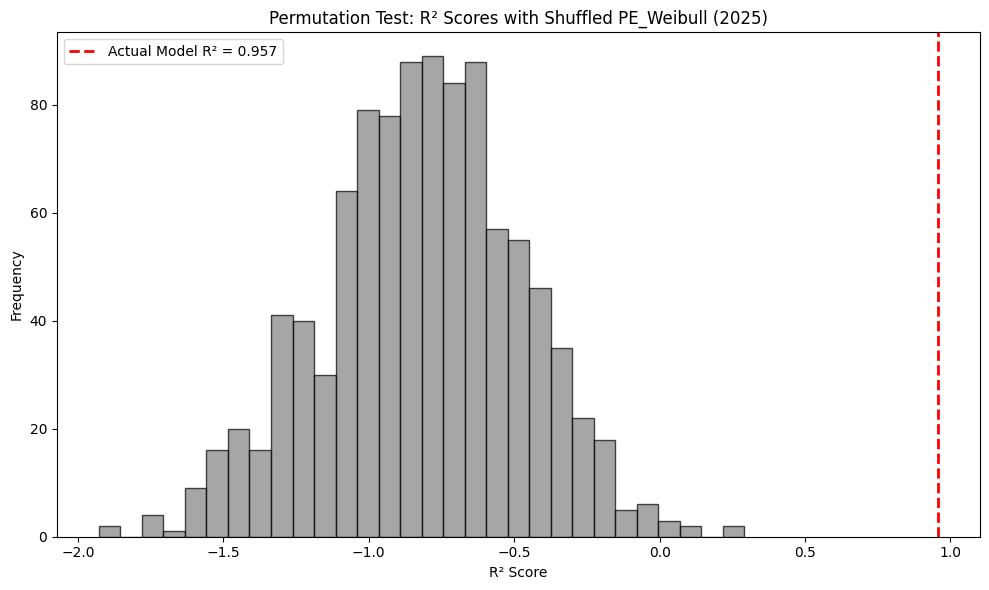

In [52]:
plt.figure(figsize=(10, 6))
plt.hist(r2_shuffled, bins=30, alpha=0.7, color='gray', edgecolor='black')
plt.axvline(r2_true, color='red', linestyle='--', linewidth=2, label=f"Actual Model R² = {r2_true:.3f}")
plt.title("Permutation Test: R² Scores with Shuffled PE_Weibull (2025)")
plt.xlabel("R² Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Discussion

To evaluate the robustness of the model based on the Weibull-derived Pythagorean Expectation, a permutation test was conducted. The test involved randomly shuffling the 2025 test set’s predictor values (PE_Weibull) over 1,000 iterations, recalculating R² scores each time using the original trained model. This process established a null distribution of performance under the assumption of no genuine predictive relationship.

The model’s actual R² substantially exceeded this baseline range, indicating that its predictive accuracy is not attributable to chance, but reflects a statistically meaningful association between the PE estimates and observed win percentages.

## Further Discussion

The model has been shown to be working effectively, so the predictive power is in the right place and working efficiently, hwoever there is a 10-15% drop off in prediction from regular season to post season. Looking at game specific reasons for this it can be that win rate is tighter due to only the best 16 teams partaking each year. This means that margins are tighter and therefore the noise into the model is greater, which can cause disruptions. This is an interesting area to see what happens, it would be interesting to see if we seperate the playoff teams during the regular season, and how well the model performs with that amount of data where margins are tighter.

## Playoff team comparison against one another, as well as lottery teams against one another.

Playoff teams are the top 16 placed teams of that season, and lottery teams are the bottom 14 teams of that season.

In [53]:
matchup_contexts_by_season = {}

for season in seasons:
    reg_key = f"gamelog_reg_{season}"
    post_key = f"gamelog_post_{season}"

    if reg_key not in globals() or post_key not in globals():
        continue

    df = globals()[reg_key].copy()
    playoff_teams = set(globals()[post_key]['Team'].str.strip().str.upper().unique())

    # Defensive checks
    if not {'Team', 'Opp'}.issubset(df.columns):
        continue

    # Standardize both team and opponent codes
    df['Team'] = df['Team'].astype(str).str.strip().str.upper()
    df['Opponent'] = df['Opp'].astype(str).str.strip().str.upper()

    # Classify each matchup
    df['Team_Playoff'] = df['Team'].isin(playoff_teams)
    df['Opponent_Playoff'] = df['Opponent'].isin(playoff_teams)

    def assign_matchup_type(row):
        if row['Team_Playoff'] and row['Opponent_Playoff']:
            return 'Playoff vs Playoff'
        elif not row['Team_Playoff'] and not row['Opponent_Playoff']:
            return 'Non-Playoff vs Non-Playoff'
        else:
            return 'Playoff vs Non-Playoff'

    df['Matchup_Type'] = df.apply(assign_matchup_type, axis=1)
    matchup_contexts_by_season[season] = df

In [54]:
# Container for results
pe_comparison_by_context = {
    'Playoff vs Playoff': [],
    'Playoff vs Non-Playoff': [],
    'Non-Playoff vs Non-Playoff': []
}

for season, df in matchup_contexts_by_season.items():
    # Retrieve exponents for that regular season
    fitted_exp = exponent_by_season.get(season)
    weibull_exp = weibull_info_by_regseason.get(season, {}).get('pyt_exp_weibull')
    
    if fitted_exp is None or weibull_exp is None:
        continue

    for context in pe_comparison_by_context:
        sub_df = df[df['Matchup_Type'] == context].copy()
        if sub_df.empty:
            continue

        sub_df['Win'] = sub_df['Rslt'].fillna('').str.startswith('W').astype(int)

        team_stats = sub_df.groupby('Team').agg(
            Points_For=('Tm', 'sum'),
            Points_Against=('Opp.1', 'sum'),
            Wins=('Win', 'sum'),
            Games=('Win', 'count')
        ).reset_index()

        team_stats['Win%'] = team_stats['Wins'] / team_stats['Games']

        PF = team_stats['Points_For']
        PA = team_stats['Points_Against']

        team_stats['PE_Fitted'] = PF**fitted_exp / (PF**fitted_exp + PA**fitted_exp)
        team_stats['PE_Weibull'] = PF**weibull_exp / (PF**weibull_exp + PA**weibull_exp)
        team_stats['Matchup_Type'] = context
        team_stats['Season'] = season

        pe_comparison_by_context[context].append(team_stats)

In [55]:
# Evaluation container
model_scores_by_context = []

for context, dfs in pe_comparison_by_context.items():
    df_all = pd.concat(dfs, ignore_index=True)
    if df_all.empty:
        continue

    for model_type in ['PE_Fitted', 'PE_Weibull']:
        y_true = df_all['Win%']
        y_pred = df_all[model_type]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        model_scores_by_context.append({
            'Context': context,
            'Model': model_type,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2
        })

scores_df = pd.DataFrame(model_scores_by_context)
print(scores_df.round(4).sort_values(['Context', 'Model']))

                      Context       Model    RMSE     MAE      R²
4  Non-Playoff vs Non-Playoff   PE_Fitted  0.0571  0.0436  0.8223
5  Non-Playoff vs Non-Playoff  PE_Weibull  0.0774  0.0630  0.6742
2      Playoff vs Non-Playoff   PE_Fitted  0.0518  0.0421  0.9518
3      Playoff vs Non-Playoff  PE_Weibull  0.0648  0.0526  0.9245
0          Playoff vs Playoff   PE_Fitted  0.0484  0.0397  0.7680
1          Playoff vs Playoff  PE_Weibull  0.0595  0.0491  0.6492


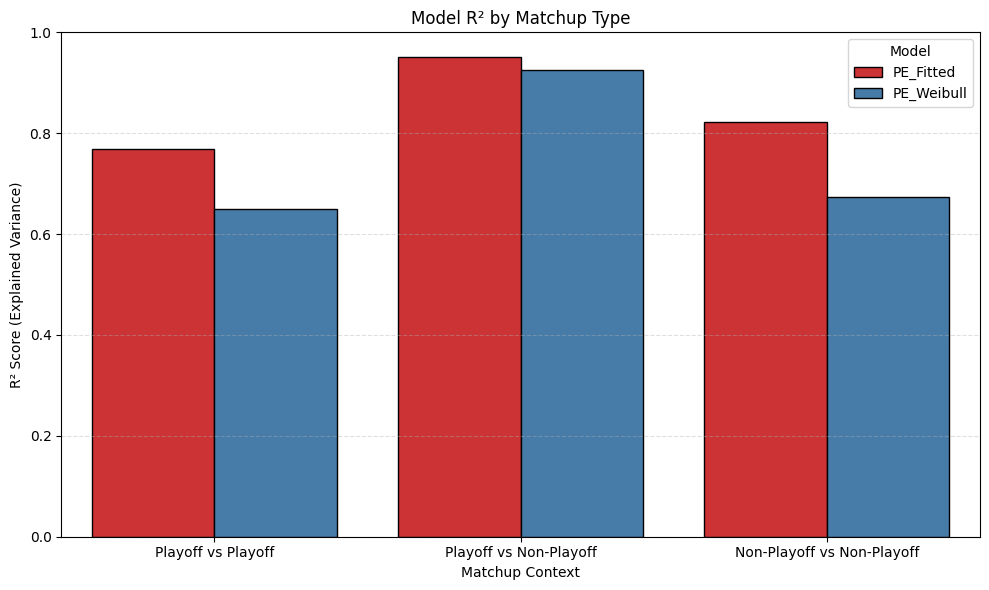

In [56]:
# Filter only R² rows from the scores table
r2_data = scores_df[['Context', 'Model', 'R²']].copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=r2_data, x='Context', y='R²', hue='Model', palette='Set1', edgecolor='black')

plt.title("Model R² by Matchup Type")
plt.ylabel("R² Score (Explained Variance)")
plt.xlabel("Matchup Context")
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

## Discussion

In playoff vs playoff, this mimics what you see in actual postseason play — games are often chess matches, not steamrolls. In non-playoff vs non-playoff, chaos reigns: bad defenses, inconsistent rotations, developmental minutes — noisy, messy, and hard to predict.

The model’s predictive power is amplified by team disparity and is a reflection of the underlying dynamics of basketball.

To improve accuracy in tight matchups, I may need to inject more context: momentum, rest days, head-to-head tendencies, or player-level inputs. The external factors become more significant when games are closer and more tightly contested.

In [57]:
merged_gamelogs = pd.merge(
    gamelogs,
    adv_gamelogs,
    on=['Rk', 'Gtm', 'Date', 'Unnamed: 3', 'Opp', 'Rslt', 'Tm', 'Opp.1', 'OT', 'Team', 'Season', 'SeasonType'],
    how='inner'
)

In [58]:
merged_gamelogs = merged_gamelogs.rename(columns={'eFG%_x': 'eFG%', 'TOV%.1': 'TOV%_opp', 'ORB%.1': 'ORB%_opp',
       'FT/FGA.1': 'FT/FGA_opp'})

In [59]:
merged_gamelogs.drop(['Rk', 'eFG%_y', 'eFG%.1', 'FTr', '3PAr', 'AST%', 'STL%', 'BLK%'], axis=1, inplace=True)

In [60]:
# --- Standardize team and opponent labels ---
merged_gamelogs['Team'] = merged_gamelogs['Team'].astype(str).str.strip().str.upper()
merged_gamelogs['Opponent'] = merged_gamelogs['Opp'].astype(str).str.strip().str.upper()

# --- Identify playoff teams by season ---
playoff_teams_by_season = (
    merged_gamelogs[merged_gamelogs['SeasonType'] == 'post']
    .groupby('Season')['Team']
    .unique()
    .apply(set)
    .to_dict()
)

# --- Flag playoff status for each row ---
merged_gamelogs['Team_Playoff'] = merged_gamelogs.apply(
    lambda row: row['Team'] in playoff_teams_by_season.get(row['Season'], set()), axis=1
)
merged_gamelogs['Opponent_Playoff'] = merged_gamelogs.apply(
    lambda row: row['Opponent'] in playoff_teams_by_season.get(row['Season'], set()), axis=1
)

# --- Define matchup type ---
def classify_matchup(row):
    if row['Team_Playoff'] and row['Opponent_Playoff']:
        return 'Playoff vs Playoff'
    elif not row['Team_Playoff'] and not row['Opponent_Playoff']:
        return 'Non-Playoff vs Non-Playoff'
    else:
        return 'Playoff vs Non-Playoff'

merged_gamelogs['Matchup_Type'] = merged_gamelogs.apply(classify_matchup, axis=1)

# Optional preview of insert location
print(merged_gamelogs.loc[50:54, ['Season', 'Team', 'Opponent', 'Matchup_Type']])

    Season Team Opponent                Matchup_Type
50    2023  ATL      BRK          Playoff vs Playoff
51    2023  BRK      ATL          Playoff vs Playoff
52    2023  ATL      BRK          Playoff vs Playoff
53    2023  BRK      ATL          Playoff vs Playoff
54    2024  BRK      ATL  Non-Playoff vs Non-Playoff


In [61]:
# Count the frequency of each matchup type
matchup_counts = merged_gamelogs['Matchup_Type'].value_counts()

# Display results
print("📊 Matchup Type Counts:")
display(matchup_counts)

📊 Matchup Type Counts:


Matchup_Type
Playoff vs Non-Playoff        5124
Playoff vs Playoff            3360
Non-Playoff vs Non-Playoff    2030
Name: count, dtype: int64

In [62]:
merged_gamelogs.columns

Index(['Gtm', 'Date', 'Unnamed: 3', 'Opp', 'Rslt', 'Tm', 'Opp.1', 'OT', 'FG',
       'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT',
       'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'FG_opp', 'FGA_opp', 'FG%_opp', '3P_opp', '3PA_opp', '3P%_opp',
       '2P_opp', '2PA_opp', '2P%_opp', 'eFG%_opp', 'FT_opp', 'FTA_opp',
       'FT%_opp', 'ORB_opp', 'DRB_opp', 'TRB_opp', 'AST_opp', 'STL_opp',
       'BLK_opp', 'TOV_opp', 'PF_opp', 'Team', 'Season', 'SeasonType',
       'GameID', 'ORtg', 'DRtg', 'Pace', 'TS%', 'TRB%', 'TOV%', 'ORB%',
       'FT/FGA', 'TOV%_opp', 'ORB%_opp', 'FT/FGA_opp', 'Opponent',
       'Team_Playoff', 'Opponent_Playoff', 'Matchup_Type'],
      dtype='object')

## TS% and TRB% dont have _opp stats attached so I'll craft those now

In [63]:
merged_gamelogs['TS%_opp'] = (merged_gamelogs['Opp.1'] / (2 * (merged_gamelogs['FGA_opp'] + 0.44 * merged_gamelogs['FTA_opp']))).round(3)

In [64]:
merged_gamelogs['TRB%_opp'] = (100 - merged_gamelogs['TRB%']).round(1)

In [65]:
# Create a binary win label (1 = Win, 0 = Loss)
df = merged_gamelogs.copy()
df['Team_Win'] = df['Rslt'].astype(str).str.startswith('W').astype(int)

In [66]:
stats = ['FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT',
         'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 
         'TS%', 'TRB%', 'TOV%', 'ORB%', 'FT/FGA',]

# Generate difference features by subtracting opponent stats
for stat in stats:
    team_col = stat
    opp_col = f'{stat}_opp'
    diff_col = f'{stat}_diff'
    
    if team_col in df.columns and opp_col in df.columns:
        df[diff_col] = df[team_col] - df[opp_col]

# Create a binary target column, if available
if 'PTS' in df.columns and 'PTS_opp' in df.columns:
    df['Result'] = (df['PTS'] > df['PTS_opp']).astype(int)

In [67]:
df.columns

Index(['Gtm', 'Date', 'Unnamed: 3', 'Opp', 'Rslt', 'Tm', 'Opp.1', 'OT', 'FG',
       'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT',
       'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'FG_opp', 'FGA_opp', 'FG%_opp', '3P_opp', '3PA_opp', '3P%_opp',
       '2P_opp', '2PA_opp', '2P%_opp', 'eFG%_opp', 'FT_opp', 'FTA_opp',
       'FT%_opp', 'ORB_opp', 'DRB_opp', 'TRB_opp', 'AST_opp', 'STL_opp',
       'BLK_opp', 'TOV_opp', 'PF_opp', 'Team', 'Season', 'SeasonType',
       'GameID', 'ORtg', 'DRtg', 'Pace', 'TS%', 'TRB%', 'TOV%', 'ORB%',
       'FT/FGA', 'TOV%_opp', 'ORB%_opp', 'FT/FGA_opp', 'Opponent',
       'Team_Playoff', 'Opponent_Playoff', 'Matchup_Type', 'TS%_opp',
       'TRB%_opp', 'Team_Win', 'FG_diff', 'FGA_diff', 'FG%_diff', '3P_diff',
       '3PA_diff', '3P%_diff', '2P_diff', '2PA_diff', '2P%_diff', 'eFG%_diff',
       'FT_diff', 'FTA_diff', 'FT%_diff', 'ORB_diff', 'DRB_diff', 'TRB_diff',
       'AST_diff', 'STL_diff', 'BLK_diff'

In [68]:
# Filter games where team DRB was higher than opponent DRB
drb_advantage_games = df[df['DRB'] > df['DRB_opp']]

# Calculate win percentage in those games
win_pct_drb_advantage = drb_advantage_games['Team_Win'].mean()

print(f"Win% when DRB > DRB_opp: {win_pct_drb_advantage:.2%}")

Win% when DRB > DRB_opp: 75.49%


In [69]:
# Define raw stat fields (replace or extend as needed)
stat_fields = ['FG_diff',
       'FGA_diff', 'FG%_diff', '3P_diff', '3PA_diff', '3P%_diff', '2P_diff',
       '2PA_diff', '2P%_diff', 'eFG%_diff', 'FT_diff', 'FTA_diff', 'FT%_diff',
       'ORB_diff', 'DRB_diff', 'TRB_diff', 'AST_diff', 'STL_diff', 'BLK_diff',
       'TOV_diff', 'PF_diff', 'TS%_diff', 'TRB%_diff', 'TOV%_diff',
       'ORB%_diff', 'FT/FGA_diff'
]

# Filter to valid columns only
valid_stats = [col for col in stat_fields if col in df.columns]
model_df = df.dropna(subset=valid_stats + ['Team_Win'] + ['Season'])

X = model_df[valid_stats]
y = model_df['Team_Win']

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

# Extract and format importance scores
importances = pd.Series(model.feature_importances_, index=X.columns)
importance_table = importances.round(4).sort_values(ascending=False).reset_index()
importance_table.columns = ['Stat Field', 'Importance Score']

pd.set_option('display.max_rows', None)
display(importance_table.sort_values(by='Importance Score', ascending=False))

,Stat Field,Importance Score
0,TS%_diff,0.2026
1,eFG%_diff,0.1123
2,FG%_diff,0.1012
3,FG_diff,0.1006
4,TOV%_diff,0.0487
5,3P%_diff,0.0455
6,DRB_diff,0.0448
7,FT_diff,0.0383
8,TOV_diff,0.0288
9,TRB%_diff,0.0280


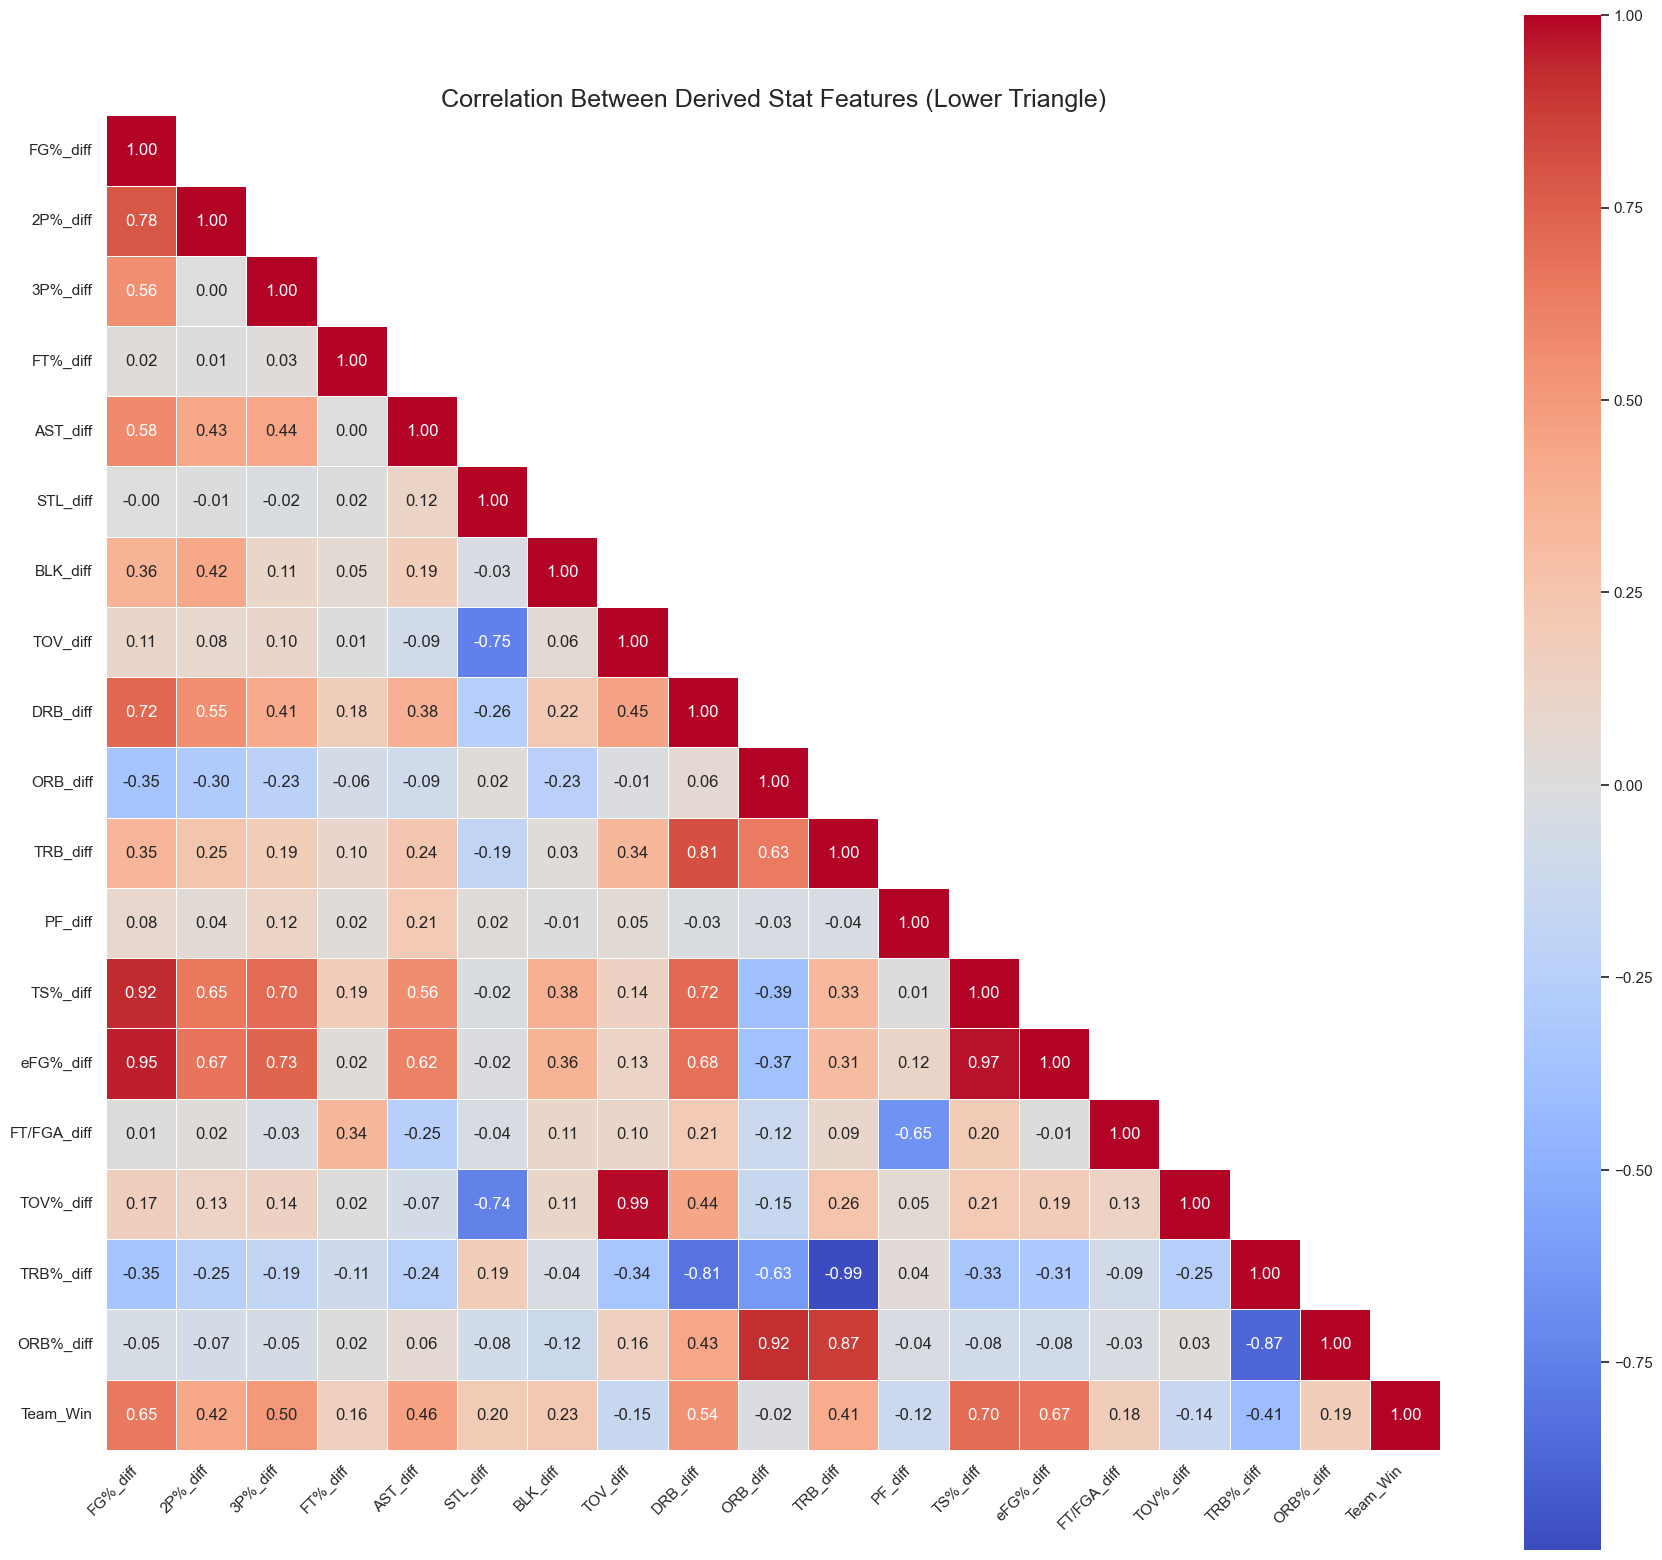

In [70]:
# Define the features you want to use
features = [
    'FG%_diff', '2P%_diff','3P%_diff', 'FT%_diff', 'AST_diff',
    'STL_diff', 'BLK_diff', 'TOV_diff', 'DRB_diff', 'ORB_diff', 'TRB_diff',
    'PF_diff', 'TS%_diff', 'eFG%_diff', 'FT/FGA_diff',
    'TOV%_diff', 'TRB%_diff', 'ORB%_diff', 'Team_Win'
]

# Prepare the correlation matrix
corr_df = df[features].dropna()
corr_matrix = corr_df.corr()

# Mask the upper triangle (keep only lower)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Set the visual style
plt.figure(figsize=(18, 16))
sns.set(style="white")

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 1.0}
)

plt.title("Correlation Between Derived Stat Features (Lower Triangle)", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Discussion

TS% and eFG% have massive correlation to winning as shown in the above graph, this is due to them being post result statistics that are reliant on full game shooting stats, which will bleed signals into any ML model and drastically increase results. Furthermore, it is clear that teams that shoot better and more efficiently will be in a better position to win so these will be omitted from any further analysis.

There are lots of fields that are repeats or are heavily linked with one another and as such perform the same roles in the upcoming anaysis so using them seems redundant, as shown by the high correlation between two distinct stats (TOV & TOV%, ORB & ORB%, TRB & TRB%), each of the % version of the stats showing higher correlations to winning so these were kept while the other two (TOV & ORB) was stripped away as well.

Another point is that FG% and 2P% are very similar and will introduce unneeded repetitive measurement into the models, so 2P% can be stripped as well.

## Logistic Regression

In [71]:
all_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff', 'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

train_seasons = [2022, 2023, 2024]
test_season = 2025

filtered_df = df.dropna(subset=all_features + ['Team_Win', 'Season'])

X_train_all = filtered_df[filtered_df['Season'].isin(train_seasons)][all_features]
y_train = filtered_df[filtered_df['Season'].isin(train_seasons)]['Team_Win']

X_test = filtered_df[filtered_df['Season'] == test_season][all_features]
y_test_all = filtered_df[filtered_df['Season'] == test_season]['Team_Win']

log_model_all = LogisticRegression(max_iter=1000)
log_model_all.fit(X_train_all, y_train)

y_pred_all = log_model_all.predict(X_test)
y_prob_all = log_model_all.predict_proba(X_test)[:, 1]

print("Accuracy (2025):", round(accuracy_score(y_test_all, y_pred_all), 4))
print("ROC AUC (2025):", round(roc_auc_score(y_test_all, y_prob_all), 4))
print("Classification Report:\n", classification_report(y_test_all, y_pred_all))

# === Feature importance summary ===
importance_all_lr_df = pd.DataFrame({
    'Feature': X_train_all.columns,
    'Importance': np.abs(log_model_all.coef_[0])
}).sort_values(by='Importance', ascending=False)

print("\nLogistic Regression Feature Importance:")
print(importance_all_lr_df.round(4))

Accuracy (2025): 0.9216
ROC AUC (2025): 0.9789
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      1314
           1       0.92      0.92      0.92      1314

    accuracy                           0.92      2628
   macro avg       0.92      0.92      0.92      2628
weighted avg       0.92      0.92      0.92      2628


Logistic Regression Feature Importance:
        Feature  Importance
0      FG%_diff     15.2042
3      3P%_diff     12.5493
4   FT/FGA_diff      3.7636
10     FT%_diff      2.5931
2     TOV%_diff      0.4964
1      DRB_diff      0.3816
8       PF_diff      0.1303
7      AST_diff      0.1160
11     BLK_diff      0.1059
9      STL_diff      0.0777
6     ORB%_diff      0.0581
5     TRB%_diff      0.0460


In [72]:
final_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# Filter only postseason data
playoff_df = df[df['SeasonType'] == 'post'].dropna(subset=final_features + ['Team_Win', 'Season'])

# Split by season
train_seasons = [2022, 2023, 2024]
test_season = 2025

X_train_post = playoff_df[playoff_df['Season'].isin(train_seasons)][final_features]
y_train_post = playoff_df[playoff_df['Season'].isin(train_seasons)]['Team_Win']

X_test_post = playoff_df[playoff_df['Season'] == test_season][final_features]
y_test_post = playoff_df[playoff_df['Season'] == test_season]['Team_Win']

# Fit logistic regression
log_post = LogisticRegression(max_iter=1000)
log_post.fit(X_train_post, y_train_post)

# Predict and evaluate
y_pred_post = log_post.predict(X_test_post)
y_prob_post = log_post.predict_proba(X_test_post)[:, 1]

print("Postseason Accuracy (2025):", round(accuracy_score(y_test_post, y_pred_post), 4))
print("ROC AUC (2025 Postseason):", round(roc_auc_score(y_test_post, y_prob_post), 4))
print("Postseason Classification Report:\n", classification_report(y_test_post, y_pred_post))

# === Feature importance summary ===
importance_post_lr_df = pd.DataFrame({
    'Feature': X_train_post.columns,
    'Importance': np.abs(log_post.coef_[0])
}).sort_values(by='Importance', ascending=False)

print("\nLogistic Regression Feature Importance (Postseason):")
print(importance_post_lr_df.round(4))

Postseason Accuracy (2025): 0.8929
ROC AUC (2025 Postseason): 0.9596
Postseason Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        84
           1       0.89      0.89      0.89        84

    accuracy                           0.89       168
   macro avg       0.89      0.89      0.89       168
weighted avg       0.89      0.89      0.89       168


Logistic Regression Feature Importance (Postseason):
        Feature  Importance
3      3P%_diff      4.3935
0      FG%_diff      1.7380
10     FT%_diff      1.5602
1      DRB_diff      0.7058
5     TRB%_diff      0.4073
2     TOV%_diff      0.3337
6     ORB%_diff      0.2765
9      STL_diff      0.1576
7      AST_diff      0.1280
11     BLK_diff      0.1002
8       PF_diff      0.0959
4   FT/FGA_diff      0.0527


In [73]:
playoff_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

playoff_df = df[
    (df['SeasonType'] == 'reg') &
    (df['Matchup_Type'].str.lower() == 'playoff vs playoff')
].dropna(subset=playoff_features + ['Team_Win', 'Season'])


train_df = playoff_df[playoff_df['Season'].isin([2022, 2023, 2024])]
test_df = playoff_df[playoff_df['Season'] == 2025]

X_train_pvp = train_df[playoff_features]
y_train = train_df['Team_Win']

X_test = test_df[playoff_features]
y_test_pvp = test_df['Team_Win']

# === Fit logistic regression ===
log_model_pvp = LogisticRegression(max_iter=1000)
log_model_pvp.fit(X_train_pvp, y_train)

# === Predict and evaluate ===
y_pred_pvp = log_model_pvp.predict(X_test)
y_prob_pvp = log_model_pvp.predict_proba(X_test)[:, 1]

print("Accuracy (2025 Playoff vs Playoff):", round(accuracy_score(y_test_pvp, y_pred_pvp), 4))
print("ROC AUC:", round(roc_auc_score(y_test_pvp, y_prob_pvp), 4))
print("Classification Report:\n", classification_report(y_test_pvp, y_pred_pvp))

# === Feature importance summary ===
importance_pvp_lr_df = pd.DataFrame({
    'Feature': X_train_pvp.columns,
    'Importance': np.abs(log_model_pvp.coef_[0])
}).sort_values(by='Importance', ascending=False)

print("\nLogistic Regression Feature Importance:")
print(importance_pvp_lr_df.round(4))

Accuracy (2025 Playoff vs Playoff): 0.881
ROC AUC: 0.9628
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88       336
           1       0.88      0.88      0.88       336

    accuracy                           0.88       672
   macro avg       0.88      0.88      0.88       672
weighted avg       0.88      0.88      0.88       672


Logistic Regression Feature Importance:
        Feature  Importance
3      3P%_diff      8.9954
0      FG%_diff      5.9603
4   FT/FGA_diff      1.5622
10     FT%_diff      1.0832
2     TOV%_diff      0.4511
1      DRB_diff      0.4072
11     BLK_diff      0.1298
9      STL_diff      0.1053
8       PF_diff      0.1026
7      AST_diff      0.1010
5     TRB%_diff      0.0459
6     ORB%_diff      0.0396


In [74]:
# === Extended metric extractor ===
def extract_metrics(name, y_true, y_pred, y_prob, X, reg_type='None'):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Context': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4),
        'True Pos': tp,
        'True Neg': tn,
        'False Pos': fp,
        'False Neg': fn,
        'Feature Count': X.shape[1],
    }

# === Collect results across contexts ===
summary_data = [
    extract_metrics('Regular Season LR', y_test_all, y_pred_all, y_prob_all, X_train_all),
    extract_metrics('Postseason LR', y_test_post, y_pred_post, y_prob_post, X_train_post),
    extract_metrics('Playoff vs Playoff LR', y_test_pvp, y_pred_pvp, y_prob_pvp, X_train_pvp)
]

lr_summary_df = pd.DataFrame(summary_data)
display(lr_summary_df)

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count
0,Regular Season LR,0.9216,0.9789,0.9216,0.9216,0.9216,1211,1211,103,103,12
1,Postseason LR,0.8929,0.9596,0.8929,0.8929,0.8929,75,75,9,9,12
2,Playoff vs Playoff LR,0.8810,0.9628,0.8810,0.8810,0.8810,296,296,40,40,12


In [75]:
# Rename importance columns for clarity
importance_df = importance_all_lr_df.rename(columns={'Importance': 'Importance_all'})
importance_post_df = importance_post_lr_df.rename(columns={'Importance': 'Importance_post'})
importance_pvp_df = importance_pvp_lr_df.rename(columns={'Importance': 'Importance_pvp'})

# === Merge all three importance tables on Feature name
importance_summary = (
    importance_df
    .merge(importance_post_df, on='Feature', how='outer')
    .merge(importance_pvp_df, on='Feature', how='outer')
)

# === Fill missing values with 0 (if any features are missing in a context)
importance_summary = importance_summary.fillna(0)

# === Round for readability and sort by average importance
importance_summary['Mean_Importance'] = importance_summary[
    ['Importance_all', 'Importance_post', 'Importance_pvp']
].mean(axis=1)

importance_summary = importance_summary.sort_values(by='Mean_Importance', ascending=False)

# === Display final summary table
print("\nLR Feature Importance Comparison Across Contexts:")
display(importance_summary[['Feature', 'Importance_all', 'Importance_post', 'Importance_pvp', 'Mean_Importance']].round(4))


LR Feature Importance Comparison Across Contexts:


,Feature,Importance_all,Importance_post,Importance_pvp,Mean_Importance
0,3P%_diff,12.5493,4.3935,8.9954,8.6461
4,FG%_diff,15.2042,1.7380,5.9603,7.6341
6,FT/FGA_diff,3.7636,0.0527,1.5622,1.7928
5,FT%_diff,2.5931,1.5602,1.0832,1.7455
3,DRB_diff,0.3816,0.7058,0.4072,0.4982
10,TOV%_diff,0.4964,0.3337,0.4511,0.4271
11,TRB%_diff,0.0460,0.4073,0.0459,0.1664
7,ORB%_diff,0.0581,0.2765,0.0396,0.1247
1,AST_diff,0.1160,0.1280,0.1010,0.1150
9,STL_diff,0.0777,0.1576,0.1053,0.1136


## Random Forest

In [76]:
all_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

train_seasons = [2022, 2023, 2024]
test_season = 2025

filtered_df = df.dropna(subset=all_features + ['Team_Win', 'Season'])

X_train_all_rf = filtered_df[filtered_df['Season'].isin(train_seasons)][all_features]
y_train = filtered_df[filtered_df['Season'].isin(train_seasons)]['Team_Win']

X_test = filtered_df[filtered_df['Season'] == test_season][all_features]
y_test_all_rf = filtered_df[filtered_df['Season'] == test_season]['Team_Win']

# === Fit Random Forest ===
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_model.fit(X_train_all_rf, y_train)

# === Predict and evaluate ===
y_pred_all_rf = rf_model.predict(X_test)
y_prob_all_rf = rf_model.predict_proba(X_test)[:, 1]

print("RF Accuracy (2025):", round(accuracy_score(y_test_all_rf, y_pred_all_rf), 4))
print("ROC AUC (2025):", round(roc_auc_score(y_test_all_rf, y_prob_all_rf), 4))
print("Classification Report:\n", classification_report(y_test_all_rf, y_pred_all_rf))

# === Feature importance summary ===
importance_rf_all = pd.DataFrame({
    'Feature': X_train_all.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
print(importance_rf_all.round(4))

RF Accuracy (2025): 0.9258
ROC AUC (2025): 0.9769
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      1314
           1       0.93      0.93      0.93      1314

    accuracy                           0.93      2628
   macro avg       0.93      0.93      0.93      2628
weighted avg       0.93      0.93      0.93      2628


Random Forest Feature Importance:
        Feature  Importance
0      FG%_diff      0.3079
1      DRB_diff      0.1476
3      3P%_diff      0.1275
2     TOV%_diff      0.1029
5     TRB%_diff      0.0659
7      AST_diff      0.0561
4   FT/FGA_diff      0.0417
9      STL_diff      0.0402
6     ORB%_diff      0.0352
8       PF_diff      0.0330
10     FT%_diff      0.0274
11     BLK_diff      0.0144


In [77]:
# === Define stat deltas ===
final_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter postseason data ===
playoff_df = df[df['SeasonType'] == 'post'].dropna(subset=final_features + ['Team_Win', 'Season'])

# === Split by season ===
train_seasons = [2022, 2023, 2024]
test_season = 2025

X_train_post_rf = playoff_df[playoff_df['Season'].isin(train_seasons)][final_features]
y_train_post = playoff_df[playoff_df['Season'].isin(train_seasons)]['Team_Win']

X_test_post = playoff_df[playoff_df['Season'] == test_season][final_features]
y_test_post_rf = playoff_df[playoff_df['Season'] == test_season]['Team_Win']

# === Fit Random Forest ===
rf_post = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_post.fit(X_train_post_rf, y_train_post)

# === Predict and evaluate ===
y_pred_post_rf = rf_post.predict(X_test_post)
y_prob_post_rf = rf_post.predict_proba(X_test_post)[:, 1]

print("Postseason RF Accuracy (2025):", round(accuracy_score(y_test_post_rf, y_pred_post_rf), 4))
print("ROC AUC (2025 Postseason):", round(roc_auc_score(y_test_post_rf, y_prob_post_rf), 4))
print("Postseason Classification Report:\n", classification_report(y_test_post_rf, y_pred_post_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test_post_rf, y_pred_post_rf))

# === Feature importance summary ===
importance_df_rf_post = pd.DataFrame({
    'Feature': X_train_post.columns,
    'Importance': rf_post.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importance (Postseason):")
print(importance_df_rf_post.round(4))

Postseason RF Accuracy (2025): 0.8869
ROC AUC (2025 Postseason): 0.9624
Postseason Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89        84
           1       0.88      0.89      0.89        84

    accuracy                           0.89       168
   macro avg       0.89      0.89      0.89       168
weighted avg       0.89      0.89      0.89       168

Confusion Matrix:
 [[74 10]
 [ 9 75]]

Random Forest Feature Importance (Postseason):
        Feature  Importance
0      FG%_diff      0.2401
3      3P%_diff      0.1441
1      DRB_diff      0.1264
5     TRB%_diff      0.1040
2     TOV%_diff      0.0785
7      AST_diff      0.0662
9      STL_diff      0.0602
6     ORB%_diff      0.0572
10     FT%_diff      0.0402
11     BLK_diff      0.0294
8       PF_diff      0.0282
4   FT/FGA_diff      0.0255


In [78]:
playoff_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

pvp_df = df[
    (df['SeasonType'] == 'reg') &
    (df['Matchup_Type'].str.lower() == 'playoff vs playoff')
].dropna(subset=playoff_features + ['Team_Win', 'Season'])

# === Train-test split ===
train_df_pvp = pvp_df[pvp_df['Season'].isin([2022, 2023, 2024])]
test_df_pvp = pvp_df[pvp_df['Season'] == 2025]

X_train_pvp_rf = train_df_pvp[playoff_features]
y_train_pvp = train_df_pvp['Team_Win']
X_test_pvp = test_df_pvp[playoff_features]
y_test_pvp_rf = test_df_pvp['Team_Win']

# === Fit Random Forest ===
rf_model_pvp = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_model_pvp.fit(X_train_pvp_rf, y_train_pvp)

# === Predict and evaluate ===
y_pred_pvp_rf = rf_model_pvp.predict(X_test_pvp)
y_prob_pvp_rf = rf_model_pvp.predict_proba(X_test_pvp)[:, 1]

print("RF Accuracy (2025 PVP):", round(accuracy_score(y_test_pvp_rf, y_pred_pvp_rf), 4))
print("ROC AUC:", round(roc_auc_score(y_test_pvp_rf, y_prob_pvp_rf), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test_pvp_rf, y_pred_pvp_rf))
print("Classification Report:\n", classification_report(y_test_pvp_rf, y_pred_pvp_rf))

# === Feature importance ranking ===
importance_df_rf_pvp = pd.DataFrame({
    'Feature': X_train_pvp.columns,
    'Importance': rf_model_pvp.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importance (Playoff vs Playoff):")
print(importance_df_rf_pvp.round(4))

RF Accuracy (2025 PVP): 0.9062
ROC AUC: 0.9648
Confusion Matrix:
 [[305  31]
 [ 32 304]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       336
           1       0.91      0.90      0.91       336

    accuracy                           0.91       672
   macro avg       0.91      0.91      0.91       672
weighted avg       0.91      0.91      0.91       672


Random Forest Feature Importance (Playoff vs Playoff):
        Feature  Importance
0      FG%_diff      0.3152
3      3P%_diff      0.1376
1      DRB_diff      0.1364
2     TOV%_diff      0.0931
5     TRB%_diff      0.0642
7      AST_diff      0.0526
9      STL_diff      0.0436
6     ORB%_diff      0.0432
4   FT/FGA_diff      0.0340
8       PF_diff      0.0314
10     FT%_diff      0.0298
11     BLK_diff      0.0188


In [79]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# === Extended metric extractor for RF ===
def extract_rf_metrics(name, y_true, y_pred, y_prob, X):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Context': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4),
        'True Pos': tp,
        'True Neg': tn,
        'False Pos': fp,
        'False Neg': fn,
        'Feature Count': X.shape[1],
    }

# === Collect RF results across game contexts ===
rf_summary_data = [
    extract_rf_metrics('Regular Season RF', y_test_all_rf, y_pred_all_rf, y_prob_all_rf, X_train_all_rf),
    extract_rf_metrics('Postseason RF', y_test_post_rf, y_pred_post_rf, y_prob_post_rf, X_train_post_rf),
    extract_rf_metrics('Playoff vs Playoff RF', y_test_pvp_rf, y_pred_pvp_rf, y_prob_pvp_rf, X_train_pvp_rf)
]

rf_summary_df = pd.DataFrame(rf_summary_data)
display(rf_summary_df)

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count
0,Regular Season RF,0.9258,0.9769,0.9261,0.9254,0.9258,1216,1217,97,98,12
1,Postseason RF,0.8869,0.9624,0.8824,0.8929,0.8876,75,74,10,9,12
2,Playoff vs Playoff RF,0.9062,0.9648,0.9075,0.9048,0.9061,304,305,31,32,12


In [80]:
# Rename importance columns for clarity
importance_df = importance_rf_all.rename(columns={'Importance': 'Importance_all'})
importance_post_df = importance_df_rf_post.rename(columns={'Importance': 'Importance_post'})
importance_pvp_df = importance_df_rf_pvp.rename(columns={'Importance': 'Importance_pvp'})

# === Merge all three importance tables on Feature name
importance_summary = (
    importance_df
    .merge(importance_post_df, on='Feature', how='outer')
    .merge(importance_pvp_df, on='Feature', how='outer')
)

# === Fill missing values with 0 (if any features are missing in a context)
importance_summary = importance_summary.fillna(0)

# === Round for readability and sort by average importance
importance_summary['Mean_Importance'] = importance_summary[
    ['Importance_all', 'Importance_post', 'Importance_pvp']
].mean(axis=1)

importance_summary = importance_summary.sort_values(by='Mean_Importance', ascending=False)

# === Display final summary table
print("\nRF Feature Importance Comparison Across Contexts:")
display(importance_summary[['Feature', 'Importance_all', 'Importance_post', 'Importance_pvp', 'Mean_Importance']].round(4))


RF Feature Importance Comparison Across Contexts:


,Feature,Importance_all,Importance_post,Importance_pvp,Mean_Importance
4,FG%_diff,0.3079,0.2401,0.3152,0.2878
3,DRB_diff,0.1476,0.1264,0.1364,0.1368
0,3P%_diff,0.1275,0.1441,0.1376,0.1364
10,TOV%_diff,0.1029,0.0785,0.0931,0.0915
11,TRB%_diff,0.0659,0.1040,0.0642,0.0780
1,AST_diff,0.0561,0.0662,0.0526,0.0583
9,STL_diff,0.0402,0.0602,0.0436,0.0480
7,ORB%_diff,0.0352,0.0572,0.0432,0.0452
6,FT/FGA_diff,0.0417,0.0255,0.0340,0.0337
5,FT%_diff,0.0274,0.0402,0.0298,0.0325


## Naive Bayes (Thabtah, 2019)

In [81]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import KBinsDiscretizer

base_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter dataset (e.g. 2022–2024 for training, 2025 for testing) ===
train_seasons = [2022, 2023, 2024]
test_season = 2025

filtered_df = df.dropna(subset=base_features + ['Team_Win', 'Season'])

X_train_raw = filtered_df[filtered_df['Season'].isin(train_seasons)][base_features].reset_index(drop=True)
y_train = filtered_df[filtered_df['Season'].isin(train_seasons)]['Team_Win'].reset_index(drop=True)

X_test_raw = filtered_df[filtered_df['Season'] == test_season][base_features].reset_index(drop=True)
y_test_all = filtered_df[filtered_df['Season'] == test_season]['Team_Win'].reset_index(drop=True)

In [82]:
# === Discretization ===
kbins = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

X_train_all = pd.DataFrame(kbins.fit_transform(X_train_raw), columns=base_features)
X_test = pd.DataFrame(kbins.transform(X_test_raw), columns=base_features)

In [83]:
# === Train Naïve Bayes ===
nb_model = GaussianNB()
nb_model.fit(X_train_all, y_train)

# === Predict and Evaluate ===
y_pred_all = nb_model.predict(X_test)

print("Naïve Bayes Performance:")
print("Accuracy:", round(accuracy_score(y_test_all, y_pred_all), 4))
print("Precision:", round(precision_score(y_test_all, y_pred_all), 4))
print("Recall:", round(recall_score(y_test_all, y_pred_all), 4))
print("F1 Score:", round(f1_score(y_test_all, y_pred_all), 4))
print("Classification Report:\n", classification_report(y_test_all, y_pred_all))

# === Feature importance summary for Naïve Bayes ===
# Using variance of discretized features as a proxy for separability (model-agnostic)
feature_variance = X_train_all.var()

importance_df_nb = pd.DataFrame({
    'Feature': X_train_all.columns,
    'Importance': feature_variance  # Higher variance → greater class separation potential
}).sort_values(by='Importance', ascending=False)

print("\nNaïve Bayes Feature Importance:")
print(importance_df_nb.round(4))

Naïve Bayes Performance:
Accuracy: 0.8482
Precision: 0.8463
Recall: 0.8508
F1 Score: 0.8486
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1314
           1       0.85      0.85      0.85      1314

    accuracy                           0.85      2628
   macro avg       0.85      0.85      0.85      2628
weighted avg       0.85      0.85      0.85      2628


Naïve Bayes Feature Importance:
                 Feature  Importance
STL_diff        STL_diff      2.1008
PF_diff          PF_diff      2.0839
DRB_diff        DRB_diff      2.0193
FT/FGA_diff  FT/FGA_diff      2.0032
TOV%_diff      TOV%_diff      2.0005
3P%_diff        3P%_diff      1.9991
ORB%_diff      ORB%_diff      1.9982
TRB%_diff      TRB%_diff      1.9978
FG%_diff        FG%_diff      1.9968
FT%_diff        FT%_diff      1.9935
AST_diff        AST_diff      1.9280
BLK_diff        BLK_diff      1.8753


In [84]:
post_features = [    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter postseason data ===
train_df_post = df[(df['SeasonType'] == 'post') & (df['Season'].isin([2022, 2023, 2024]))].dropna(subset=post_features + ['Team_Win'])
test_df_post = df[(df['SeasonType'] == 'post') & (df['Season'] == 2025)].dropna(subset=post_features + ['Team_Win'])

X_train_post_raw = train_df_post[post_features].reset_index(drop=True)
y_train_post = train_df_post['Team_Win'].reset_index(drop=True)

X_test_post_raw = test_df_post[post_features].reset_index(drop=True)
y_test_post = test_df_post['Team_Win'].reset_index(drop=True)

# === Discretize features ===
kbins_post = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
X_train_post = pd.DataFrame(kbins_post.fit_transform(X_train_post_raw), columns=post_features)
X_test_post = pd.DataFrame(kbins_post.transform(X_test_post_raw), columns=post_features)

# === Train Naïve Bayes ===
nb_post = GaussianNB()
nb_post.fit(X_train_post, y_train_post)

# === Predict and evaluate ===
y_pred_post = nb_post.predict(X_test_post)
y_prob_post = nb_post.predict_proba(X_test_post)[:, 1]

print("Naïve Bayes Performance (2025 Postseason):")
print("Accuracy:", round(accuracy_score(y_test_post, y_pred_post), 4))
print("ROC AUC:", round(roc_auc_score(y_test_post, y_prob_post), 4))
print("Precision:", round(precision_score(y_test_post, y_pred_post), 4))
print("Recall:", round(recall_score(y_test_post, y_pred_post), 4))
print("F1 Score:", round(f1_score(y_test_post, y_pred_post), 4))
print("Classification Report:\n", classification_report(y_test_post, y_pred_post))

# === Feature importance proxy using variance of discretized inputs ===
feature_variance_post = X_train_post.var()

importance_df_nb_post = pd.DataFrame({
    'Feature': post_features,
    'Importance': feature_variance_post * len(post_features)  # scaled for readability
}).sort_values(by='Importance', ascending=False)

print("\nNaïve Bayes Feature Importance (Postseason Proxy):")
print(importance_df_nb_post.round(4))

Naïve Bayes Performance (2025 Postseason):
Accuracy: 0.7976
ROC AUC: 0.8861
Precision: 0.8125
Recall: 0.7738
F1 Score: 0.7927
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.82      0.80        84
           1       0.81      0.77      0.79        84

    accuracy                           0.80       168
   macro avg       0.80      0.80      0.80       168
weighted avg       0.80      0.80      0.80       168


Naïve Bayes Feature Importance (Postseason Proxy):
                 Feature  Importance
PF_diff          PF_diff     25.5539
DRB_diff        DRB_diff     25.2032
AST_diff        AST_diff     25.0223
FT%_diff        FT%_diff     24.3772
STL_diff        STL_diff     24.3002
ORB%_diff      ORB%_diff     24.1176
FG%_diff        FG%_diff     24.0949
FT/FGA_diff  FT/FGA_diff     24.0943
3P%_diff        3P%_diff     24.0468
TOV%_diff      TOV%_diff     23.9970
TRB%_diff      TRB%_diff     23.9751
BLK_diff        BLK_diff   

In [85]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
import pandas as pd
import numpy as np

# === Define RIPPER-inspired features ===
pvp_features = ['FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter playoff-vs-playoff matchups ===
train_df_pvp = df[
    (df['Matchup_Type'].str.lower() == 'playoff vs playoff') &
    (df['Season'].isin([2022, 2023, 2024]))
].dropna(subset=pvp_features + ['Team_Win'])

test_df_pvp = df[
    (df['Matchup_Type'].str.lower() == 'playoff vs playoff') &
    (df['Season'] == 2025)
].dropna(subset=pvp_features + ['Team_Win'])

X_train_pvp_raw = train_df_pvp[pvp_features].reset_index(drop=True)
y_train_pvp = train_df_pvp['Team_Win'].reset_index(drop=True)

X_test_pvp_raw = test_df_pvp[pvp_features].reset_index(drop=True)
y_test_pvp = test_df_pvp['Team_Win'].reset_index(drop=True)

# === Discretize features ===
kbins_pvp = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
X_train_pvp = pd.DataFrame(kbins_pvp.fit_transform(X_train_pvp_raw), columns=pvp_features)
X_test_pvp = pd.DataFrame(kbins_pvp.transform(X_test_pvp_raw), columns=pvp_features)

# === Train Naïve Bayes ===
nb_pvp = GaussianNB()
nb_pvp.fit(X_train_pvp, y_train_pvp)

# === Predict and evaluate ===
y_pred_pvp = nb_pvp.predict(X_test_pvp)
y_prob_pvp = nb_pvp.predict_proba(X_test_pvp)[:, 1]

print("Naïve Bayes Performance (2025 PvP):")
print("Accuracy:", round(accuracy_score(y_test_pvp, y_pred_pvp), 4))
print("ROC AUC:", round(roc_auc_score(y_test_pvp, y_prob_pvp), 4))
print("Precision:", round(precision_score(y_test_pvp, y_pred_pvp), 4))
print("Recall:", round(recall_score(y_test_pvp, y_pred_pvp), 4))
print("F1 Score:", round(f1_score(y_test_pvp, y_pred_pvp), 4))
print("Classification Report:\n", classification_report(y_test_pvp, y_pred_pvp))

# === Feature importance proxy using variance of discretized inputs ===
feature_variance_pvp = X_train_pvp.var()

importance_df_nb_pvp = pd.DataFrame({
    'Feature': pvp_features,
    'Importance': feature_variance_pvp * len(pvp_features)  # scaled for readability
}).sort_values(by='Importance', ascending=False)

print("\nNaïve Bayes Feature Importance (PvP Proxy):")
print(importance_df_nb_pvp.round(4))

Naïve Bayes Performance (2025 PvP):
Accuracy: 0.825
ROC AUC: 0.9113
Precision: 0.8227
Recall: 0.8286
F1 Score: 0.8256
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82       420
           1       0.82      0.83      0.83       420

    accuracy                           0.82       840
   macro avg       0.83      0.82      0.82       840
weighted avg       0.83      0.82      0.82       840


Naïve Bayes Feature Importance (PvP Proxy):
                 Feature  Importance
PF_diff          PF_diff     24.7795
STL_diff        STL_diff     24.6677
3P%_diff        3P%_diff     24.0521
DRB_diff        DRB_diff     24.0432
FT/FGA_diff  FT/FGA_diff     24.0380
FT%_diff        FT%_diff     24.0333
ORB%_diff      ORB%_diff     24.0236
FG%_diff        FG%_diff     24.0143
TRB%_diff      TRB%_diff     23.8989
TOV%_diff      TOV%_diff     23.8757
AST_diff        AST_diff     22.9757
BLK_diff        BLK_diff     22.1736


In [86]:
# === Metric extractor for Naïve Bayes ===
def extract_nb_metrics(name, y_true, y_pred, y_prob, X):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Context': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4),
        'True Pos': tp,
        'True Neg': tn,
        'False Pos': fp,
        'False Neg': fn,
        'Feature Count': X.shape[1],
    }

# === Compile Naïve Bayes results across contexts ===
nb_summary_data = [
    extract_nb_metrics('Naïve Bayes (Regular Season)', y_test_all, y_pred_all, y_prob_all, X_train_all),
    extract_nb_metrics('Naïve Bayes (Postseason)', y_test_post, y_pred_post, y_prob_post, X_train_post),
    extract_nb_metrics('Naïve Bayes (PVP)', y_test_pvp, y_pred_pvp, y_prob_pvp, X_train_pvp)
]

nb_summary_df = pd.DataFrame(nb_summary_data)
display(nb_summary_df)

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count
0,Naïve Bayes (Regular Season),0.8482,0.9789,0.8463,0.8508,0.8486,1118,1111,203,196,12
1,Naïve Bayes (Postseason),0.7976,0.8861,0.8125,0.7738,0.7927,65,69,15,19,12
2,Naïve Bayes (PVP),0.8250,0.9113,0.8227,0.8286,0.8256,348,345,75,72,12


In [87]:
# Rename importance columns for clarity
importance_df = importance_df_nb.rename(columns={'Importance': 'Importance_all'})
importance_post_df = importance_df_nb_post.rename(columns={'Importance': 'Importance_post'})
importance_pvp_df = importance_df_nb_pvp.rename(columns={'Importance': 'Importance_pvp'})

# === Merge all three importance tables on Feature name
importance_summary = (
    importance_df
    .merge(importance_post_df, on='Feature', how='outer')
    .merge(importance_pvp_df, on='Feature', how='outer')
)

# === Fill missing values with 0 (if any features are missing in a context)
importance_summary = importance_summary.fillna(0)

# === Round for readability and sort by average importance
importance_summary['Mean_Importance'] = importance_summary[
    ['Importance_all', 'Importance_post', 'Importance_pvp']
].mean(axis=1)

importance_summary = importance_summary.sort_values(by='Mean_Importance', ascending=False)

# === Display final summary table
print("\nNaïve Bayes Feature Importance Comparison Across Contexts:")
print(importance_summary[['Feature', 'Importance_all', 'Importance_post', 'Importance_pvp']].round(4))


Naïve Bayes Feature Importance Comparison Across Contexts:
        Feature  Importance_all  Importance_post  Importance_pvp
8       PF_diff          2.0839          25.5539         24.7795
3      DRB_diff          2.0193          25.2032         24.0432
9      STL_diff          2.1008          24.3002         24.6677
5      FT%_diff          1.9935          24.3772         24.0333
7     ORB%_diff          1.9982          24.1176         24.0236
6   FT/FGA_diff          2.0032          24.0943         24.0380
4      FG%_diff          1.9968          24.0949         24.0143
0      3P%_diff          1.9991          24.0468         24.0521
1      AST_diff          1.9280          25.0223         22.9757
10    TOV%_diff          2.0005          23.9970         23.8757
11    TRB%_diff          1.9978          23.9751         23.8989
2      BLK_diff          1.8753          21.5712         22.1736


## Hybrid Fuzzy Support Vector Machine (HFSVM)

In [88]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.svm import SVC

# === Define stat deltas ===
hfsvm_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter and split regular season data ===
train_seasons = [2022, 2023, 2024]
test_season = 2025

filtered_df = df.dropna(subset=hfsvm_features + ['Team_Win', 'Season'])

X_train_raw = filtered_df[filtered_df['Season'].isin(train_seasons)][hfsvm_features]
y_train = filtered_df[filtered_df['Season'].isin(train_seasons)]['Team_Win']

X_test_raw = filtered_df[filtered_df['Season'] == test_season][hfsvm_features]
y_test = filtered_df[filtered_df['Season'] == test_season]['Team_Win']

# === Min-max scaling ===
scaler = MinMaxScaler()
X_train_reg_scaled_df = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=hfsvm_features).reset_index(drop=True)
X_test_scaled_df = pd.DataFrame(scaler.transform(X_test_raw), columns=hfsvm_features).reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test_reg = y_test.reset_index(drop=True)

# === Fuzzy membership weights from class proximity ===
def compute_membership(X, y):
    class_means = {label: X[y == label].mean(axis=0) for label in np.unique(y)}
    memberships = []
    for i in range(len(X)):
        dist = np.linalg.norm(X.iloc[i] - class_means[y.iloc[i]])
        memberships.append(np.exp(-dist))  # inverse distance weighting
    return np.array(memberships)

sample_weights = compute_membership(X_train_reg_scaled_df, y_train)

# === Apply fuzzy weighting to inputs ===
X_train_weighted = X_train_reg_scaled_df.multiply(sample_weights, axis=0)

# === Train standard SVM on fuzzy-weighted data ===
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_model.fit(X_train_weighted, y_train)

# === Predict and evaluate ===
y_pred_reg = svm_model.predict(X_test_scaled_df)
y_prob_reg = svm_model.predict_proba(X_test_scaled_df)[:, 1]

print("HFSVM (Simulated) Accuracy (2025):", round(accuracy_score(y_test_reg, y_pred_reg), 4))
print("ROC AUC (2025):", round(roc_auc_score(y_test_reg, y_prob_reg), 4))
print("Classification Report:\n", classification_report(y_test_reg, y_pred_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test_reg, y_pred_reg))

# === Feature importance proxy (variance × membership mean) ===
feature_variance = X_train_reg_scaled_df.var()
importance_proxy = feature_variance * np.mean(sample_weights)

importance_df_hf = pd.DataFrame({
    'Feature': hfsvm_features,
    'Importance': importance_proxy
}).sort_values(by='Importance', ascending=False)

print("\nHFSVM Feature Importance (Proxy):")
print(importance_df_hf.round(4))

HFSVM (Simulated) Accuracy (2025): 0.7196
ROC AUC (2025): 0.7737
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.46      0.62      1314
           1       0.64      0.98      0.78      1314

    accuracy                           0.72      2628
   macro avg       0.80      0.72      0.70      2628
weighted avg       0.80      0.72      0.70      2628

Confusion Matrix:
 [[ 599  715]
 [  22 1292]]

HFSVM Feature Importance (Proxy):
                 Feature  Importance
TRB%_diff      TRB%_diff      0.0157
ORB%_diff      ORB%_diff      0.0129
DRB_diff        DRB_diff      0.0127
FG%_diff        FG%_diff      0.0116
PF_diff          PF_diff      0.0115
TOV%_diff      TOV%_diff      0.0112
FT%_diff        FT%_diff      0.0103
FT/FGA_diff  FT/FGA_diff      0.0103
AST_diff        AST_diff      0.0098
3P%_diff        3P%_diff      0.0096
STL_diff        STL_diff      0.0094
BLK_diff        BLK_diff      0.0069


In [89]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.svm import SVC

# === Define stat deltas ===
hfsvm_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter and split postseason data ===
train_seasons = [2022, 2023, 2024]
test_season = 2025

post_df = df[df['SeasonType'] == 'post'].dropna(subset=hfsvm_features + ['Team_Win', 'Season'])

X_train_raw = post_df[post_df['Season'].isin(train_seasons)][hfsvm_features]
y_train = post_df[post_df['Season'].isin(train_seasons)]['Team_Win']

X_test_raw = post_df[post_df['Season'] == test_season][hfsvm_features]
y_test = post_df[post_df['Season'] == test_season]['Team_Win']

# === Min-max scaling ===
scaler = MinMaxScaler()
X_train_post_scaled_df = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=hfsvm_features).reset_index(drop=True)
X_test_scaled_df = pd.DataFrame(scaler.transform(X_test_raw), columns=hfsvm_features).reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test_post_hfsvm = y_test.reset_index(drop=True)

# === Fuzzy membership weights from class proximity ===
def compute_membership(X, y):
    class_means = {label: X[y == label].mean(axis=0) for label in np.unique(y)}
    memberships = []
    for i in range(len(X)):
        dist = np.linalg.norm(X.iloc[i] - class_means[y.iloc[i]])
        memberships.append(np.exp(-dist))  # inverse distance weighting
    return np.array(memberships)

sample_weights = compute_membership(X_train_post_scaled_df, y_train)

# === Apply fuzzy weighting to inputs ===
X_train_weighted = X_train_post_scaled_df.multiply(sample_weights, axis=0)

# === Train standard SVM on fuzzy-weighted data ===
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_model.fit(X_train_weighted, y_train)

# === Predict and evaluate ===
y_pred_post_hfsvm = svm_model.predict(X_test_scaled_df)
y_prob_post_hfsvm = svm_model.predict_proba(X_test_scaled_df)[:, 1]

print("HFSVM (Simulated) Accuracy (2025 Postseason):", round(accuracy_score(y_test_post_hfsvm, y_pred_post_hfsvm), 4))
print("ROC AUC (2025 Postseason):", round(roc_auc_score(y_test_post_hfsvm, y_prob_post_hfsvm), 4))
print("Classification Report:\n", classification_report(y_test_post_hfsvm, y_pred_post_hfsvm))
print("Confusion Matrix:\n", confusion_matrix(y_test_post_hfsvm, y_pred_post_hfsvm))

# === Feature importance proxy (variance × membership mean) ===
feature_variance = X_train_post_scaled_df.var()
importance_proxy = feature_variance * np.mean(sample_weights)

importance_df_hf_post = pd.DataFrame({
    'Feature': hfsvm_features,
    'Importance': importance_proxy
}).sort_values(by='Importance', ascending=False)

print("\nHFSVM Feature Importance (Postseason Proxy):")
print(importance_df_hf_post.round(4))

HFSVM (Simulated) Accuracy (2025 Postseason): 0.6429
ROC AUC (2025 Postseason): 0.8099
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.29      0.44        84
           1       0.58      1.00      0.74        84

    accuracy                           0.64       168
   macro avg       0.79      0.64      0.59       168
weighted avg       0.79      0.64      0.59       168

Confusion Matrix:
 [[24 60]
 [ 0 84]]

HFSVM Feature Importance (Postseason Proxy):
                 Feature  Importance
TRB%_diff      TRB%_diff      0.0215
PF_diff          PF_diff      0.0213
AST_diff        AST_diff      0.0191
3P%_diff        3P%_diff      0.0178
DRB_diff        DRB_diff      0.0170
ORB%_diff      ORB%_diff      0.0166
TOV%_diff      TOV%_diff      0.0164
FG%_diff        FG%_diff      0.0157
FT%_diff        FT%_diff      0.0148
FT/FGA_diff  FT/FGA_diff      0.0145
BLK_diff        BLK_diff      0.0110
STL_diff        STL_diff      0.00

In [90]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.svm import SVC

# === Define stat deltas ===
hfsvm_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter playoff-vs-playoff regular season matchups ===
train_seasons = [2022, 2023, 2024]
test_season = 2025

pvp_df = df[
    (df['SeasonType'] == 'reg') &
    (df['Matchup_Type'].str.lower() == 'playoff vs playoff')
].dropna(subset=hfsvm_features + ['Team_Win', 'Season'])

X_train_raw = pvp_df[pvp_df['Season'].isin(train_seasons)][hfsvm_features]
y_train = pvp_df[pvp_df['Season'].isin(train_seasons)]['Team_Win']

X_test_raw = pvp_df[pvp_df['Season'] == test_season][hfsvm_features]
y_test = pvp_df[pvp_df['Season'] == test_season]['Team_Win']

# === Min-max scaling ===
scaler = MinMaxScaler()
X_train_pvp_scaled_df = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=hfsvm_features).reset_index(drop=True)
X_test_scaled_df = pd.DataFrame(scaler.transform(X_test_raw), columns=hfsvm_features).reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test_pvp_hfsvm = y_test.reset_index(drop=True)

# === Fuzzy membership weights from class proximity ===
def compute_membership(X, y):
    class_means = {label: X[y == label].mean(axis=0) for label in np.unique(y)}
    memberships = []
    for i in range(len(X)):
        dist = np.linalg.norm(X.iloc[i] - class_means[y.iloc[i]])
        memberships.append(np.exp(-dist))  # inverse distance weighting
    return np.array(memberships)

sample_weights = compute_membership(X_train_pvp_scaled_df, y_train)

# === Apply fuzzy weighting to inputs ===
X_train_weighted = X_train_pvp_scaled_df.multiply(sample_weights, axis=0)

# === Train standard SVM on fuzzy-weighted data ===
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_model.fit(X_train_weighted, y_train)

# === Predict and evaluate ===
y_pred_pvp_hfsvm = svm_model.predict(X_test_scaled_df)
y_prob_pvp_hfsvm = svm_model.predict_proba(X_test_scaled_df)[:, 1]

print("HFSVM (Simulated) Accuracy (2025 PVP):", round(accuracy_score(y_test_pvp_hfsvm, y_pred_pvp_hfsvm), 4))
print("ROC AUC (2025 PVP):", round(roc_auc_score(y_test_pvp_hfsvm, y_prob_pvp_hfsvm), 4))
print("Classification Report:\n", classification_report(y_test_pvp_hfsvm, y_pred_pvp_hfsvm))
print("Confusion Matrix:\n", confusion_matrix(y_test_pvp_hfsvm, y_pred_pvp_hfsvm))

# === Feature importance proxy (variance × membership mean) ===
feature_variance = X_train_pvp_scaled_df.var()
importance_proxy = feature_variance * np.mean(sample_weights)

importance_df_hf_pvp = pd.DataFrame({
    'Feature': hfsvm_features,
    'Importance': importance_proxy
}).sort_values(by='Importance', ascending=False)

print("\nHFSVM Feature Importance (PVP Proxy):")
print(importance_df_hf_pvp.round(4))

HFSVM (Simulated) Accuracy (2025 PVP): 0.6354
ROC AUC (2025 PVP): 0.8118
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.27      0.43       336
           1       0.58      1.00      0.73       336

    accuracy                           0.64       672
   macro avg       0.79      0.64      0.58       672
weighted avg       0.79      0.64      0.58       672

Confusion Matrix:
 [[ 91 245]
 [  0 336]]

HFSVM Feature Importance (PVP Proxy):
                 Feature  Importance
TRB%_diff      TRB%_diff      0.0165
ORB%_diff      ORB%_diff      0.0164
BLK_diff        BLK_diff      0.0146
FT%_diff        FT%_diff      0.0144
FG%_diff        FG%_diff      0.0130
FT/FGA_diff  FT/FGA_diff      0.0127
STL_diff        STL_diff      0.0126
PF_diff          PF_diff      0.0124
DRB_diff        DRB_diff      0.0118
TOV%_diff      TOV%_diff      0.0109
AST_diff        AST_diff      0.0099
3P%_diff        3P%_diff      0.0096


In [91]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# === Extended metric extractor for HFSVM ===
def extract_hfsvm_metrics(name, y_true, y_pred, y_prob, X):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Context': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4),
        'True Pos': tp,
        'True Neg': tn,
        'False Pos': fp,
        'False Neg': fn,
        'Feature Count': X.shape[1],
    }

# === Collect HFSVM results across game contexts ===
hfsvm_summary_data = [
    extract_hfsvm_metrics('Regular Season HFSVM', y_test_reg, y_pred_reg, y_prob_reg, X_train_reg_scaled_df),
    extract_hfsvm_metrics('Postseason HFSVM', y_test_post_hfsvm, y_pred_post_hfsvm, y_prob_post_hfsvm, X_train_post_scaled_df),
    extract_hfsvm_metrics('Playoff vs Playoff HFSVM', y_test_pvp_hfsvm, y_pred_pvp_hfsvm, y_prob_pvp_hfsvm, X_train_pvp_scaled_df)
]

hfsvm_summary_df = pd.DataFrame(hfsvm_summary_data)
display(hfsvm_summary_df)

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count
0,Regular Season HFSVM,0.7196,0.7737,0.6437,0.9833,0.7781,1292,599,715,22,12
1,Postseason HFSVM,0.6429,0.8099,0.5833,1.0000,0.7368,84,24,60,0,12
2,Playoff vs Playoff HFSVM,0.6354,0.8118,0.5783,1.0000,0.7328,336,91,245,0,12


In [92]:
# Rename importance columns for clarity
importance_df = importance_df_hf.rename(columns={'Importance': 'Importance_all'})
importance_post_df = importance_df_hf_post.rename(columns={'Importance': 'Importance_post'})
importance_pvp_df = importance_df_hf_pvp.rename(columns={'Importance': 'Importance_pvp'})

# === Merge all three importance tables on Feature name
importance_summary = (
    importance_df
    .merge(importance_post_df, on='Feature', how='outer')
    .merge(importance_pvp_df, on='Feature', how='outer')
)

# === Fill missing values with 0 (if any features are missing in a context)
importance_summary = importance_summary.fillna(0)

# === Round for readability and sort by average importance
importance_summary['Mean_Importance'] = importance_summary[
    ['Importance_all', 'Importance_post', 'Importance_pvp']
].mean(axis=1)

importance_summary = importance_summary.sort_values(by='Mean_Importance', ascending=False)

# === Display final summary table
print("\nHFSVM Feature Importance Comparison Across Contexts:")
display(importance_summary[['Feature', 'Importance_all', 'Importance_post', 'Importance_pvp', 'Mean_Importance']].round(4))


HFSVM Feature Importance Comparison Across Contexts:


,Feature,Importance_all,Importance_post,Importance_pvp,Mean_Importance
11,TRB%_diff,0.0157,0.0215,0.0165,0.0179
7,ORB%_diff,0.0129,0.0166,0.0164,0.0153
8,PF_diff,0.0115,0.0213,0.0124,0.0151
3,DRB_diff,0.0127,0.0170,0.0118,0.0138
4,FG%_diff,0.0116,0.0157,0.0130,0.0135
5,FT%_diff,0.0103,0.0148,0.0144,0.0132
1,AST_diff,0.0098,0.0191,0.0099,0.0129
10,TOV%_diff,0.0112,0.0164,0.0109,0.0128
6,FT/FGA_diff,0.0103,0.0145,0.0127,0.0125
0,3P%_diff,0.0096,0.0178,0.0096,0.0123


## XGBoost

In [93]:
from xgboost import XGBClassifier
# === Define stat deltas ===
xgb_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter and split data ===
train_seasons = [2022, 2023, 2024]
test_season = 2025

filtered_df = df.dropna(subset=xgb_features + ['Team_Win', 'Season'])

X_train_xgb = filtered_df[filtered_df['Season'].isin(train_seasons)][xgb_features]
y_train_xgb = filtered_df[filtered_df['Season'].isin(train_seasons)]['Team_Win']

X_test_xgb = filtered_df[filtered_df['Season'] == test_season][xgb_features]
y_test_xgb = filtered_df[filtered_df['Season'] == test_season]['Team_Win']

# === Fit XGBoost model ===
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_xgb, y_train_xgb)

# === Predict and evaluate ===
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

print("XGBoost Accuracy (2025):", round(accuracy_score(y_test_xgb, y_pred_xgb), 4))
print("ROC AUC (2025):", round(roc_auc_score(y_test_xgb, y_prob_xgb), 4))
print("Classification Report:\n", classification_report(y_test_xgb, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test_xgb, y_pred_xgb))

# === Feature importance summary ===
importance_df_xg = pd.DataFrame({
    'Feature': xgb_features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nXGBoost Feature Importance:")
print(importance_df_xg.round(4))

XGBoost Accuracy (2025): 0.9304
ROC AUC (2025): 0.9818
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      1314
           1       0.93      0.93      0.93      1314

    accuracy                           0.93      2628
   macro avg       0.93      0.93      0.93      2628
weighted avg       0.93      0.93      0.93      2628

Confusion Matrix:
 [[1219   95]
 [  88 1226]]

XGBoost Feature Importance:
        Feature  Importance
0      FG%_diff      0.3522
1      DRB_diff      0.1258
2     TOV%_diff      0.0899
3      3P%_diff      0.0802
5     TRB%_diff      0.0738
6     ORB%_diff      0.0525
8       PF_diff      0.0488
4   FT/FGA_diff      0.0481
10     FT%_diff      0.0412
7      AST_diff      0.0346
9      STL_diff      0.0326
11     BLK_diff      0.0202


In [94]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import pandas as pd

# === Define stat deltas ===
final_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter postseason data ===
playoff_df = df[df['SeasonType'] == 'post'].dropna(subset=final_features + ['Team_Win', 'Season'])

# === Split by season ===
train_seasons = [2022, 2023, 2024]
test_season = 2025

X_train_post_xgb = playoff_df[playoff_df['Season'].isin(train_seasons)][final_features]
y_train_post_xgb = playoff_df[playoff_df['Season'].isin(train_seasons)]['Team_Win']

X_test_post_xgb = playoff_df[playoff_df['Season'] == test_season][final_features]
y_test_post_xgb = playoff_df[playoff_df['Season'] == test_season]['Team_Win']

# === Fit XGBoost model ===
xgb_post = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb_post.fit(X_train_post_xgb, y_train_post_xgb)

# === Predict and evaluate ===
y_pred_post_xgb = xgb_post.predict(X_test_post_xgb)
y_prob_post_xgb = xgb_post.predict_proba(X_test_post_xgb)[:, 1]

print("Postseason XGBoost Accuracy (2025):", round(accuracy_score(y_test_post_xgb, y_pred_post_xgb), 4))
print("ROC AUC (2025 Postseason):", round(roc_auc_score(y_test_post_xgb, y_prob_post_xgb), 4))
print("Postseason Classification Report:\n", classification_report(y_test_post_xgb, y_pred_post_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test_post_xgb, y_pred_post_xgb))

# === Feature importance summary ===
importance_df_xg_post = pd.DataFrame({
    'Feature': X_train_post_xgb.columns,
    'Importance': xgb_post.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nXGBoost Feature Importance (Postseason):")
print(importance_df_xg_post.round(4))

Postseason XGBoost Accuracy (2025): 0.9345
ROC AUC (2025 Postseason): 0.9772
Postseason Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93        84
           1       0.92      0.95      0.94        84

    accuracy                           0.93       168
   macro avg       0.94      0.93      0.93       168
weighted avg       0.94      0.93      0.93       168

Confusion Matrix:
 [[77  7]
 [ 4 80]]

XGBoost Feature Importance (Postseason):
        Feature  Importance
0      FG%_diff      0.2592
3      3P%_diff      0.1213
5     TRB%_diff      0.1048
2     TOV%_diff      0.0976
1      DRB_diff      0.0764
6     ORB%_diff      0.0701
9      STL_diff      0.0697
7      AST_diff      0.0558
10     FT%_diff      0.0533
11     BLK_diff      0.0351
8       PF_diff      0.0328
4   FT/FGA_diff      0.0238


In [95]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import pandas as pd

# === Define stat deltas ===
playoff_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter regular season playoff-vs-playoff matchups ===
pvp_df = df[
    (df['SeasonType'] == 'reg') &
    (df['Matchup_Type'].str.lower() == 'playoff vs playoff')
].dropna(subset=playoff_features + ['Team_Win', 'Season'])

# === Train-test split ===
train_df_pvp = pvp_df[pvp_df['Season'].isin([2022, 2023, 2024])]
test_df_pvp = pvp_df[pvp_df['Season'] == 2025]

X_train_pvp_xgb = train_df_pvp[playoff_features]
y_train_pvp_xgb = train_df_pvp['Team_Win']
X_test_pvp_xgb = test_df_pvp[playoff_features]
y_test_pvp_xgb = test_df_pvp['Team_Win']

# === Fit XGBoost model ===
xgb_model_pvp = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb_model_pvp.fit(X_train_pvp_xgb, y_train_pvp_xgb)

# === Predict and evaluate ===
y_pred_pvp_xgb = xgb_model_pvp.predict(X_test_pvp_xgb)
y_prob_pvp_xgb = xgb_model_pvp.predict_proba(X_test_pvp_xgb)[:, 1]

print("XGBoost Accuracy (2025 PVP):", round(accuracy_score(y_test_pvp_xgb, y_pred_pvp_xgb), 4))
print("ROC AUC:", round(roc_auc_score(y_test_pvp_xgb, y_prob_pvp_xgb), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test_pvp_xgb, y_pred_pvp_xgb))
print("Classification Report:\n", classification_report(y_test_pvp_xgb, y_pred_pvp_xgb))

# === Feature importance ranking ===
importance_df_xg_pvp = pd.DataFrame({
    'Feature': X_train_pvp_xgb.columns,
    'Importance': xgb_model_pvp.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nXGBoost Feature Importance (Playoff vs Playoff):")
print(importance_df_xg_pvp.round(4))

XGBoost Accuracy (2025 PVP): 0.8988
ROC AUC: 0.9701
Confusion Matrix:
 [[300  36]
 [ 32 304]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.90       336
           1       0.89      0.90      0.90       336

    accuracy                           0.90       672
   macro avg       0.90      0.90      0.90       672
weighted avg       0.90      0.90      0.90       672


XGBoost Feature Importance (Playoff vs Playoff):
        Feature  Importance
0      FG%_diff      0.3298
1      DRB_diff      0.0939
3      3P%_diff      0.0899
2     TOV%_diff      0.0879
5     TRB%_diff      0.0739
6     ORB%_diff      0.0684
9      STL_diff      0.0541
8       PF_diff      0.0534
4   FT/FGA_diff      0.0514
10     FT%_diff      0.0392
7      AST_diff      0.0343
11     BLK_diff      0.0239


In [96]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# === Extended metric extractor for XGBoost ===
def extract_xgb_metrics(name, y_true, y_pred, y_prob, X):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Context': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4),
        'True Pos': tp,
        'True Neg': tn,
        'False Pos': fp,
        'False Neg': fn,
        'Feature Count': X.shape[1],
    }

# === Collect XGBoost results across game contexts ===
xgb_summary_data = [
    extract_xgb_metrics('Regular Season XGB', y_test_xgb, y_pred_xgb, y_prob_xgb, X_train_xgb),
    extract_xgb_metrics('Postseason XGB', y_test_post_xgb, y_pred_post_xgb, y_prob_post_xgb, X_train_post_xgb),
    extract_xgb_metrics('Playoff vs Playoff XGB', y_test_pvp_xgb, y_pred_pvp_xgb, y_prob_pvp_xgb, X_train_pvp_xgb)
]

xgb_summary_df = pd.DataFrame(xgb_summary_data)
display(xgb_summary_df)

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count
0,Regular Season XGB,0.9304,0.9818,0.9281,0.9330,0.9306,1226,1219,95,88,12
1,Postseason XGB,0.9345,0.9772,0.9195,0.9524,0.9357,80,77,7,4,12
2,Playoff vs Playoff XGB,0.8988,0.9701,0.8941,0.9048,0.8994,304,300,36,32,12


In [97]:
# Rename importance columns for clarity
importance_df = importance_df_xg.rename(columns={'Importance': 'Importance_all'})
importance_post_df = importance_df_xg_post.rename(columns={'Importance': 'Importance_post'})
importance_pvp_df = importance_df_xg_pvp.rename(columns={'Importance': 'Importance_pvp'})

# === Merge all three importance tables on Feature name
importance_summary = (
    importance_df
    .merge(importance_post_df, on='Feature', how='outer')
    .merge(importance_pvp_df, on='Feature', how='outer')
)

# === Fill missing values with 0 (if any features are missing in a context)
importance_summary = importance_summary.fillna(0)

# === Round for readability and sort by average importance
importance_summary['Mean_Importance'] = importance_summary[
    ['Importance_all', 'Importance_post', 'Importance_pvp']
].mean(axis=1)

importance_summary = importance_summary.sort_values(by='Mean_Importance', ascending=False)

# === Display final summary table
print("\nXGBoost Feature Importance Comparison Across Contexts:")
display(importance_summary[['Feature', 'Importance_all', 'Importance_post', 'Importance_pvp', 'Mean_Importance']].round(4))


XGBoost Feature Importance Comparison Across Contexts:


,Feature,Importance_all,Importance_post,Importance_pvp,Mean_Importance
4,FG%_diff,0.3522,0.2592,0.3298,0.3137
3,DRB_diff,0.1258,0.0764,0.0939,0.0987
0,3P%_diff,0.0802,0.1213,0.0899,0.0971
10,TOV%_diff,0.0899,0.0976,0.0879,0.0918
11,TRB%_diff,0.0738,0.1048,0.0739,0.0842
7,ORB%_diff,0.0525,0.0701,0.0684,0.0637
9,STL_diff,0.0326,0.0697,0.0541,0.0521
8,PF_diff,0.0488,0.0328,0.0534,0.0450
5,FT%_diff,0.0412,0.0533,0.0392,0.0446
1,AST_diff,0.0346,0.0558,0.0343,0.0416


## Feedforward Neural Network (FNN)

In [98]:
fnn_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

train_seasons = [2022, 2023, 2024]
test_season = 2025

filtered_df = df.dropna(subset=fnn_features + ['Team_Win', 'Season'])

X_train_fnn = filtered_df[filtered_df['Season'].isin(train_seasons)][fnn_features]
y_train_fnn = filtered_df[filtered_df['Season'].isin(train_seasons)]['Team_Win']

X_test_fnn = filtered_df[filtered_df['Season'] == test_season][fnn_features]
y_test_fnn = filtered_df[filtered_df['Season'] == test_season]['Team_Win']

# Min-max scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_fnn)
X_test_scaled = scaler.transform(X_test_fnn)

# Build FNN model
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# === Early stopping callback ===
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train_scaled, y_train_fnn,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


y_prob_fnn = model.predict(X_test_scaled).flatten()
y_pred_fnn = (y_prob_fnn >= 0.5).astype(int)

print("FNN Accuracy (2025):", round(accuracy_score(y_test_fnn, y_pred_fnn), 4))
print("ROC AUC (2025):", round(roc_auc_score(y_test_fnn, y_prob_fnn), 4))
print("Classification Report:\n", classification_report(y_test_fnn, y_pred_fnn))
print("Confusion Matrix:\n", confusion_matrix(y_test_fnn, y_pred_fnn))

input_weights = model.layers[0].get_weights()[0]  # First Dense layer weights
abs_weights = np.abs(input_weights).sum(axis=1)   # Sum across neurons

importance_df_fnn = pd.DataFrame({
    'Feature': X_train_fnn.columns,
    'Importance': abs_weights
}).sort_values(by='Importance', ascending=False)

print("\n🧠 FNN Feature Importance Ranking:")
print(importance_df_fnn.round(4))

Epoch 1/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6216 - loss: 0.6518 - val_accuracy: 0.8732 - val_loss: 0.4131
Epoch 2/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8387 - loss: 0.3958 - val_accuracy: 0.9201 - val_loss: 0.2465
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8976 - loss: 0.2695 - val_accuracy: 0.9283 - val_loss: 0.1818
Epoch 4/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9162 - loss: 0.2145 - val_accuracy: 0.9264 - val_loss: 0.1682
Epoch 5/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9209 - loss: 0.1985 - val_accuracy: 0.9347 - val_loss: 0.1606
Epoch 6/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9205 - loss: 0.2019 - val_accuracy: 0.9290 - val_loss: 0.1698
Epoch 7/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9224 - loss: 0.1929 - val_accuracy: 0.9341 - val_loss: 0.1508
Epoch 8/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9219 - loss: 0.1788 - val_accu

In [99]:
fnn_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# Filter postseason data
train_seasons = [2022, 2023, 2024]
test_season = 2025

post_df = df[df['SeasonType'] == 'post'].dropna(subset=fnn_features + ['Team_Win', 'Season'])

X_train_post_fnn = post_df[post_df['Season'].isin(train_seasons)][fnn_features]
y_train_post_fnn = post_df[post_df['Season'].isin(train_seasons)]['Team_Win']

X_test_post_fnn = post_df[post_df['Season'] == test_season][fnn_features]
y_test_post_fnn = post_df[post_df['Season'] == test_season]['Team_Win']

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_post_fnn)
X_test_scaled = scaler.transform(X_test_post_fnn)

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_post_fnn,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_prob_post_fnn = model.predict(X_test_scaled).flatten()
y_pred_post_fnn = (y_prob_post_fnn >= 0.5).astype(int)

print("FNN Accuracy (2025 Postseason):", round(accuracy_score(y_test_post_fnn, y_pred_post_fnn), 4))
print("ROC AUC (2025 Postseason):", round(roc_auc_score(y_test_post_fnn, y_prob_post_fnn), 4))
print("Classification Report:\n", classification_report(y_test_post_fnn, y_pred_post_fnn))
print("Confusion Matrix:\n", confusion_matrix(y_test_post_fnn, y_pred_post_fnn))

input_weights = model.layers[0].get_weights()[0]  # First Dense layer weights
abs_weights = np.abs(input_weights).sum(axis=1)   # Sum across neurons

importance_df_fnn_post = pd.DataFrame({
    'Feature': X_train_post_fnn.columns,
    'Importance': abs_weights
}).sort_values(by='Importance', ascending=False)

print("\n🧠 FNN Feature Importance Ranking (Postseason):")
print(importance_df_fnn_post.round(4))

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5193 - loss: 0.7312 - val_accuracy: 0.7745 - val_loss: 0.6733
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5922 - loss: 0.6732 - val_accuracy: 0.5686 - val_loss: 0.6536
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5510 - loss: 0.6697 - val_accuracy: 0.7549 - val_loss: 0.6271
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7003 - loss: 0.6262 - val_accuracy: 0.8529 - val_loss: 0.5986
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6692 - loss: 0.6179 - val_accuracy: 0.8725 - val_loss: 0.5706
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7416 - loss: 0.5778 - val_accuracy: 0.8627 - val_loss: 0.5363
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7509 - loss: 0.5781 - val_accuracy: 0.8529 - val_loss: 0.5017
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8158 - loss: 0.5140 - val_accuracy: 0.8824 - 

In [100]:
fnn_features = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

train_seasons = [2022, 2023, 2024]
test_season = 2025

pvp_df = df[
    (df['SeasonType'] == 'reg') &
    (df['Matchup_Type'].str.lower() == 'playoff vs playoff')
].dropna(subset=fnn_features + ['Team_Win', 'Season'])

X_train_pvp_fnn = pvp_df[pvp_df['Season'].isin(train_seasons)][fnn_features]
y_train_pvp_fnn = pvp_df[pvp_df['Season'].isin(train_seasons)]['Team_Win']

X_test_pvp_fnn = pvp_df[pvp_df['Season'] == test_season][fnn_features]
y_test_pvp_fnn = pvp_df[pvp_df['Season'] == test_season]['Team_Win']

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_pvp_fnn)
X_test_scaled = scaler.transform(X_test_pvp_fnn)

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_pvp_fnn,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_prob_pvp_fnn = model.predict(X_test_scaled).flatten()
y_pred_pvp_fnn = (y_prob_pvp_fnn >= 0.5).astype(int)

print("FNN Accuracy (2025 PVP):", round(accuracy_score(y_test_pvp_fnn, y_pred_pvp_fnn), 4))
print("ROC AUC (2025 PVP):", round(roc_auc_score(y_test_pvp_fnn, y_prob_pvp_fnn), 4))
print("Classification Report:\n", classification_report(y_test_pvp_fnn, y_pred_pvp_fnn))
print("Confusion Matrix:\n", confusion_matrix(y_test_pvp_fnn, y_pred_pvp_fnn))

input_weights = model.layers[0].get_weights()[0]  # First Dense layer weights
abs_weights = np.abs(input_weights).sum(axis=1)   # Sum across neurons

importance_df_fnn_pvp = pd.DataFrame({
    'Feature': X_train_pvp_fnn.columns,
    'Importance': abs_weights
}).sort_values(by='Importance', ascending=False)

print("\n🧠 FNN Feature Importance Ranking (Playoff vs Playoff):")
print(importance_df_fnn_pvp.round(4))

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5471 - loss: 0.6844 - val_accuracy: 0.7916 - val_loss: 0.6311
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6998 - loss: 0.6220 - val_accuracy: 0.8213 - val_loss: 0.5514
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7482 - loss: 0.5483 - val_accuracy: 0.8685 - val_loss: 0.4677
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7857 - loss: 0.4792 - val_accuracy: 0.8586 - val_loss: 0.4039
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8385 - loss: 0.4206 - val_accuracy: 0.9107 - val_loss: 0.3429
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8590 - loss: 0.3658 - val_accuracy: 0.9156 - val_loss: 0.2947
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8693 - loss: 0.3438 - val_accuracy: 0.9231 - val_loss: 0.2616
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8684 - loss: 0.3110 - val_accuracy: 0.9107 - v

In [101]:
def extract_fnn_metrics(name, y_true, y_pred, y_prob, X):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Context': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4),
        'True Pos': tp,
        'True Neg': tn,
        'False Pos': fp,
        'False Neg': fn,
        'Feature Count': X.shape[1],
    }

fnn_summary_data = [
    extract_fnn_metrics('Regular Season FNN', y_test_fnn, y_pred_fnn, y_prob_fnn, X_train_fnn),
    extract_fnn_metrics('Postseason FNN', y_test_post_fnn, y_pred_post_fnn, y_prob_post_fnn, X_train_post_fnn),
    extract_fnn_metrics('Playoff vs Playoff FNN', y_test_pvp_fnn, y_pred_pvp_fnn, y_prob_pvp_fnn, X_train_pvp_fnn)
]

fnn_summary_df = pd.DataFrame(fnn_summary_data)
display(fnn_summary_df)

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count
0,Regular Season FNN,0.9349,0.9849,0.9333,0.9368,0.9351,1231,1226,88,83,12
1,Postseason FNN,0.9226,0.9836,0.9277,0.9167,0.9222,77,78,6,7,12
2,Playoff vs Playoff FNN,0.9077,0.9784,0.9177,0.8958,0.9066,301,309,27,35,12


In [102]:
# Rename importance columns for clarity
importance_df = importance_df_fnn.rename(columns={'Importance': 'Importance_all'})
importance_post_df = importance_df_fnn_post.rename(columns={'Importance': 'Importance_post'})
importance_pvp_df = importance_df_fnn_pvp.rename(columns={'Importance': 'Importance_pvp'})

# === Merge all three importance tables on Feature name
importance_summary = (
    importance_df
    .merge(importance_post_df, on='Feature', how='outer')
    .merge(importance_pvp_df, on='Feature', how='outer')
)

# === Fill missing values with 0 (if any features are missing in a context)
importance_summary = importance_summary.fillna(0)

# === Round for readability and sort by average importance
importance_summary['Mean_Importance'] = importance_summary[
    ['Importance_all', 'Importance_post', 'Importance_pvp']
].mean(axis=1)

importance_summary = importance_summary.sort_values(by='Mean_Importance', ascending=False)

# === Display final summary table
print("\nFNN Feature Importance Comparison Across Contexts:")
display(importance_summary[['Feature', 'Importance_all', 'Importance_post', 'Importance_pvp', 'Mean_Importance']].round(4))


FNN Feature Importance Comparison Across Contexts:


,Feature,Importance_all,Importance_post,Importance_pvp,Mean_Importance
4,FG%_diff,15.8827,12.5785,14.5317,14.3309
10,TOV%_diff,15.0385,11.2617,13.3964,13.2322
11,TRB%_diff,12.8792,11.1586,12.5296,12.1892
0,3P%_diff,11.9091,10.8361,12.2779,11.6744
3,DRB_diff,8.9534,9.5221,9.6430,9.3728
1,AST_diff,8.7195,9.1667,9.1440,9.0101
8,PF_diff,9.4730,8.5347,8.7038,8.9038
9,STL_diff,7.9056,9.2539,8.8298,8.6631
7,ORB%_diff,8.0127,8.5329,8.5920,8.3792
6,FT/FGA_diff,8.5647,7.5799,7.4752,7.8732


## Weighted Features, Hybrid Reconstruction (Cai, 2019)

In [103]:
def weighted_team_stats(df, team_col, stat_cols, game_lag=5, decay=0.5591):
    weights = np.exp(-decay * np.arange(game_lag))
    weights /= weights.sum()

    def compute_weighted(row):
        team = row[team_col]
        date = row['Date']
        past_games = df[(df[team_col] == team) & (df['Date'] < date)].sort_values('Date', ascending=False).head(game_lag)
        return np.average(past_games[stat_cols], axis=0, weights=weights)

    weighted_stats = df.apply(compute_weighted, axis=1, result_type='expand')
    weighted_stats.columns = [f"{col}_weighted" for col in stat_cols]
    return pd.concat([df.reset_index(drop=True), weighted_stats.reset_index(drop=True)], axis=1)

In [104]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# === Define features used for prediction ===
feature_cols = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter entire dataset — no SeasonType restriction ===
train_df = df[df['Season'] < 2025].dropna(subset=feature_cols + ['Team_Win'])
test_df = df[df['Season'] == 2025].dropna(subset=feature_cols + ['Team_Win'])

X_train_raw = train_df[feature_cols].reset_index(drop=True)
y_train = train_df['Team_Win'].reset_index(drop=True)

X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test_all = test_df['Team_Win'].reset_index(drop=True)

# === Scale features ===
scaler = MinMaxScaler()
X_train_all = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=feature_cols)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=feature_cols)

# === Ensemble model setup ===
base_svm = SVC(kernel='rbf', probability=True)

ensemble_model = BaggingClassifier(
    estimator=base_svm,
    n_estimators=9,
    max_samples=0.75,
    max_features=0.85,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42
)

# === Train and evaluate ===
ensemble_model.fit(X_train_all, y_train)
y_pred_all = ensemble_model.predict(X_test)
y_prob_all = ensemble_model.predict_proba(X_test)[:, 1]

# === Calculate feature variance across scaled inputs
feature_variance = X_train_all.var()

# === Use as proxy for importance — higher variance = more separability potential
importance_proxy = pd.DataFrame({
    'Feature': feature_cols,
    'Variance': feature_variance,
    'Importance': feature_variance * ensemble_model.n_estimators  # optional scaling for readability
}).sort_values(by='Importance', ascending=False)

print("Ensemble Accuracy (All 2025 Matchups):", round(accuracy_score(y_test_all, y_pred_all), 4))
print("Classification Report:\n", classification_report(y_test_all, y_pred_all))
print("Confusion Matrix:\n", confusion_matrix(y_test_all, y_pred_all))
print("\nEnsemble SVM Feature Importance Proxy:")
print(importance_proxy[['Feature', 'Importance']].round(4))

Ensemble Accuracy (All 2025 Matchups): 0.9216
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      1314
           1       0.92      0.92      0.92      1314

    accuracy                           0.92      2628
   macro avg       0.92      0.92      0.92      2628
weighted avg       0.92      0.92      0.92      2628

Confusion Matrix:
 [[1208  106]
 [ 100 1214]]

Ensemble SVM Feature Importance Proxy:
                 Feature  Importance
TRB%_diff      TRB%_diff      0.2077
ORB%_diff      ORB%_diff      0.1706
DRB_diff        DRB_diff      0.1679
FG%_diff        FG%_diff      0.1542
PF_diff          PF_diff      0.1517
TOV%_diff      TOV%_diff      0.1480
FT%_diff        FT%_diff      0.1363
FT/FGA_diff  FT/FGA_diff      0.1358
AST_diff        AST_diff      0.1299
3P%_diff        3P%_diff      0.1266
STL_diff        STL_diff      0.1245
BLK_diff        BLK_diff      0.0915


In [105]:
# === Define features ===
feature_cols = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter postseason data ===
train_df = df[(df['SeasonType'] == 'post') & (df['Season'] < 2025)].dropna(subset=feature_cols + ['Team_Win'])
test_df = df[(df['SeasonType'] == 'post') & (df['Season'] == 2025)].dropna(subset=feature_cols + ['Team_Win'])

X_train_raw = train_df[feature_cols].reset_index(drop=True)
y_train = train_df['Team_Win'].reset_index(drop=True)

X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test_post = test_df['Team_Win'].reset_index(drop=True)

# === Scale features ===
scaler = MinMaxScaler()
X_train_post = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=feature_cols)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=feature_cols)

# === Define base SVM and ensemble ===
base_svm = SVC(kernel='rbf', probability=True)

ensemble_model = BaggingClassifier(
    estimator=base_svm,
    n_estimators=9,
    max_samples=0.75,
    max_features=0.85,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42
)

# === Train and evaluate ===
ensemble_model.fit(X_train_post, y_train)
y_pred_post = ensemble_model.predict(X_test)
y_prob_post = ensemble_model.predict_proba(X_test)[:, 1]

print("Ensemble Accuracy (2025 Postseason):", round(accuracy_score(y_test_post, y_pred_post), 4))
print("Classification Report:\n", classification_report(y_test_post, y_pred_post))
print("Confusion Matrix:\n", confusion_matrix(y_test_post, y_pred_post))

# === Feature importance proxy (variance × ensemble size) ===
feature_variance = X_train_post.var()
importance_proxy_wf_post = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_variance * ensemble_model.n_estimators
}).sort_values(by='Importance', ascending=False)

print("\nEnsemble SVM Feature Importance (Postseason Proxy):")
print(importance_proxy_wf_post.round(4))

Ensemble Accuracy (2025 Postseason): 0.9167
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        84
           1       0.92      0.92      0.92        84

    accuracy                           0.92       168
   macro avg       0.92      0.92      0.92       168
weighted avg       0.92      0.92      0.92       168

Confusion Matrix:
 [[77  7]
 [ 7 77]]

Ensemble SVM Feature Importance (Postseason Proxy):
                 Feature  Importance
TRB%_diff      TRB%_diff      0.3152
PF_diff          PF_diff      0.3123
AST_diff        AST_diff      0.2793
3P%_diff        3P%_diff      0.2604
DRB_diff        DRB_diff      0.2489
ORB%_diff      ORB%_diff      0.2431
TOV%_diff      TOV%_diff      0.2405
FG%_diff        FG%_diff      0.2304
FT%_diff        FT%_diff      0.2166
FT/FGA_diff  FT/FGA_diff      0.2116
BLK_diff        BLK_diff      0.1603
STL_diff        STL_diff      0.1169


In [106]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# === Define features ===
feature_cols = [
    'FG%_diff', 'DRB_diff', 'TOV%_diff', '3P%_diff', 'FT/FGA_diff',
    'TRB%_diff', 'ORB%_diff',
    'AST_diff', 'PF_diff', 'STL_diff', 'FT%_diff', 'BLK_diff'
]

# === Filter playoff-vs-playoff regular season matchups ===
train_df = df[
    (df['Matchup_Type'].str.lower() == 'playoff vs playoff') &
    (df['Season'] < 2025)
].dropna(subset=feature_cols + ['Team_Win'])

test_df = df[
    (df['Matchup_Type'].str.lower() == 'playoff vs playoff') &
    (df['Season'] == 2025)
].dropna(subset=feature_cols + ['Team_Win'])

X_train_raw = train_df[feature_cols].reset_index(drop=True)
y_train = train_df['Team_Win'].reset_index(drop=True)

X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test_pvp = test_df['Team_Win'].reset_index(drop=True)

# === Scale features ===
scaler = MinMaxScaler()
X_train_pvp = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=feature_cols)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=feature_cols)

# === Define base SVM and ensemble ===
base_svm = SVC(kernel='rbf', probability=True)

ensemble_model = BaggingClassifier(
    estimator=base_svm,
    n_estimators=9,
    max_samples=0.75,
    max_features=0.85,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42
)

# === Train and evaluate ===
ensemble_model.fit(X_train_pvp, y_train)
y_pred_pvp = ensemble_model.predict(X_test)
y_prob_pvp = ensemble_model.predict_proba(X_test)[:, 1]

print("Ensemble Accuracy (2025 PVP):", round(accuracy_score(y_test_pvp, y_pred_pvp), 4))
print("Classification Report:\n", classification_report(y_test_pvp, y_pred_pvp))
print("Confusion Matrix:\n", confusion_matrix(y_test_pvp, y_pred_pvp))

# === Feature importance proxy (variance × ensemble size) ===
feature_variance = X_train_pvp.var()
importance_proxy_wf_pvp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_variance * ensemble_model.n_estimators
}).sort_values(by='Importance', ascending=False)

print("\nEnsemble SVM Feature Importance (PVP Proxy):")
print(importance_proxy_wf_pvp.round(4))

Ensemble Accuracy (2025 PVP): 0.9107
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       420
           1       0.91      0.91      0.91       420

    accuracy                           0.91       840
   macro avg       0.91      0.91      0.91       840
weighted avg       0.91      0.91      0.91       840

Confusion Matrix:
 [[384  36]
 [ 39 381]]

Ensemble SVM Feature Importance (PVP Proxy):
                 Feature  Importance
TRB%_diff      TRB%_diff      0.2377
ORB%_diff      ORB%_diff      0.2162
FT%_diff        FT%_diff      0.2024
FG%_diff        FG%_diff      0.1806
FT/FGA_diff  FT/FGA_diff      0.1773
PF_diff          PF_diff      0.1739
DRB_diff        DRB_diff      0.1636
TOV%_diff      TOV%_diff      0.1501
BLK_diff        BLK_diff      0.1484
AST_diff        AST_diff      0.1355
3P%_diff        3P%_diff      0.1323
STL_diff        STL_diff      0.1182


In [107]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# === Extended metric extractor for Ensemble SVM ===
def extract_ensemble_metrics(name, y_true, y_pred, y_prob, X):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Context': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4),
        'True Pos': tp,
        'True Neg': tn,
        'False Pos': fp,
        'False Neg': fn,
        'Feature Count': X.shape[1],
    }

# === Collect Ensemble SVM results across game contexts ===
ensemble_summary_data = [
    extract_ensemble_metrics('Regular Season SVM', y_test_all, y_pred_all, y_prob_all, X_train_all),
    extract_ensemble_metrics('Postseason Ensemble SVM', y_test_post, y_pred_post, y_prob_post, X_train_post),
    extract_ensemble_metrics('Playoff vs Playoff Ensemble SVM', y_test_pvp, y_pred_pvp, y_prob_pvp, X_train_pvp)
]

ensemble_summary_df = pd.DataFrame(ensemble_summary_data)
display(ensemble_summary_df)

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count
0,Regular Season SVM,0.9216,0.9798,0.9197,0.9239,0.9218,1214,1208,106,100,12
1,Postseason Ensemble SVM,0.9167,0.9762,0.9167,0.9167,0.9167,77,77,7,7,12
2,Playoff vs Playoff Ensemble SVM,0.9107,0.9732,0.9137,0.9071,0.9104,381,384,36,39,12


## Importance Ranking

In [108]:
[variable for variable in globals() if variable.startswith('importance_') and isinstance(globals()[variable], pd.DataFrame)]

['importance_table',
 'importance_all_lr_df',
 'importance_post_lr_df',
 'importance_pvp_lr_df',
 'importance_df',
 'importance_post_df',
 'importance_pvp_df',
 'importance_summary',
 'importance_rf_all',
 'importance_df_rf_post',
 'importance_df_rf_pvp',
 'importance_df_nb',
 'importance_df_nb_post',
 'importance_df_nb_pvp',
 'importance_proxy',
 'importance_df_hf',
 'importance_df_hf_post',
 'importance_df_hf_pvp',
 'importance_df_xg',
 'importance_df_xg_post',
 'importance_df_xg_pvp',
 'importance_df_fnn',
 'importance_df_fnn_post',
 'importance_df_fnn_pvp',
 'importance_proxy_wf_post',
 'importance_proxy_wf_pvp']

In [109]:
# === List of importance DataFrame names ===
importance_names = [
    'importance_all_lr_df', 'importance_post_lr_df', 'importance_pvp_lr_df',
    'importance_rf_all', 'importance_df_rf_post', 'importance_df_rf_pvp',
    'importance_df_hf', 'importance_df_hf_post', 'importance_df_hf_pvp',
    'importance_df_xg', 'importance_df_xg_post', 'importance_df_xg_pvp',
    'importance_df_fnn', 'importance_df_fnn_post', 'importance_df_fnn_pvp',
    'importance_proxy', 'importance_proxy_wf_post', 'importance_proxy_wf_pvp',
    'importance_df_nb', 'importance_df_nb_post', 'importance_df_nb_pvp'
]

ranked_tables = []

for name in importance_names:
    df = globals()[name].copy()
    df['Rank_' + name] = df['Importance'].rank(ascending=False, method='min')
    ranked_tables.append(df[['Feature', 'Rank_' + name]])

ranking_summary = ranked_tables[0]
for ranked_df in ranked_tables[1:]:
    ranking_summary = ranking_summary.merge(ranked_df, on='Feature', how='outer')

rank_cols = [col for col in ranking_summary.columns if col.startswith('Rank_')]
ranking_summary['Average_Rank'] = ranking_summary[rank_cols].mean(axis=1)

ranking_summary = ranking_summary.sort_values(by='Average_Rank')
print("\n📊 Aggregated Feature Ranking Across All Models:")
display(ranking_summary[['Feature', 'Average_Rank']].round(2))


📊 Aggregated Feature Ranking Across All Models:


,Feature,Average_Rank
4,FG%_diff,3.38
3,DRB_diff,4.29
11,TRB%_diff,4.67
0,3P%_diff,4.81
10,TOV%_diff,5.48
8,PF_diff,6.57
7,ORB%_diff,6.71
5,FT%_diff,7.67
1,AST_diff,7.81
6,FT/FGA_diff,8.10


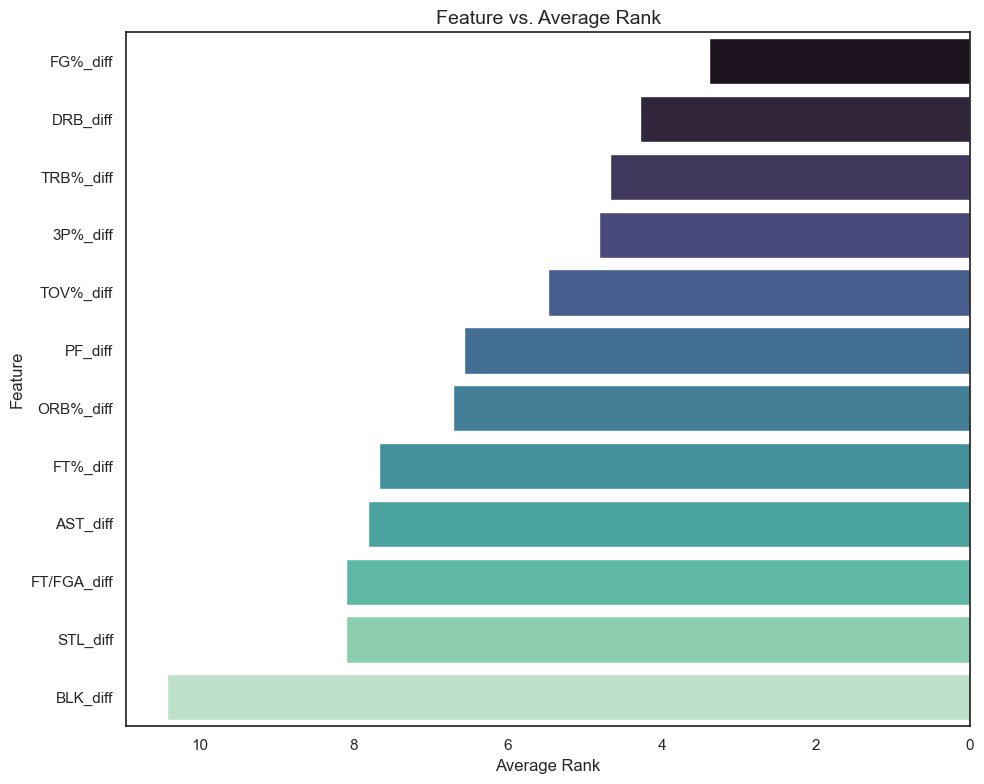

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: sorted dataframe
df_sorted = ranking_summary.sort_values(by='Average_Rank')

# Define a palette manually (optional)
custom_palette = sns.color_palette('mako', n_colors=len(df_sorted))

# Pass it directly into barplot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_sorted,
    x='Average_Rank',
    y='Feature',
    hue='Feature',
    palette=custom_palette
)

plt.title('Feature vs. Average Rank', fontsize=14)
plt.xlabel('Average Rank')
plt.ylabel('Feature')
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

In [111]:
# === List of importance DataFrame names ===
importance_names = [
     'importance_pvp_lr_df', 'importance_df_rf_pvp', 'importance_df_hf_pvp', 'importance_df_xg_pvp',
    'importance_df_fnn_pvp', 'importance_proxy_wf_pvp', 'importance_df_nb_pvp'
]

ranked_tables = []

for name in importance_names:
    df = globals()[name].copy()
    df['Rank_' + name] = df['Importance'].rank(ascending=False, method='min')
    ranked_tables.append(df[['Feature', 'Rank_' + name]])

ranking_summary = ranked_tables[0]
for ranked_df in ranked_tables[1:]:
    ranking_summary = ranking_summary.merge(ranked_df, on='Feature', how='outer')

rank_cols = [col for col in ranking_summary.columns if col.startswith('Rank_')]
ranking_summary['Average_Rank'] = ranking_summary[rank_cols].mean(axis=1)

ranking_summary = ranking_summary.sort_values(by='Average_Rank')
print("\n📊 Aggregated Feature Ranking Across PvP Models:")
display(ranking_summary[['Feature', 'Average_Rank']].round(2))


📊 Aggregated Feature Ranking Across PvP Models:


,Feature,Average_Rank
4,FG%_diff,3.14
11,TRB%_diff,5.00
3,DRB_diff,5.14
0,3P%_diff,5.14
10,TOV%_diff,6.14
7,ORB%_diff,6.57
5,FT%_diff,6.86
6,FT/FGA_diff,7.00
9,STL_diff,7.14
8,PF_diff,7.14


In [112]:
summary_dfs = {
    name: globals()[name]
    for name in globals()
    if name.endswith('_summary_df') and isinstance(globals()[name], pd.DataFrame)
}

# === Step 2: Add a 'Source' column to each and collect them
collated_df = pd.concat([
    df.assign(Source=name.replace('_summary_df', ''))
    for name, df in summary_dfs.items()
], ignore_index=True)

def bold_max(s):
    is_max = s == s.max()
    return ['font-weight: bold' if v else '' for v in is_max]

# Apply styling to your summary DataFrame
styled_df = collated_df.style.apply(bold_max, axis=0)

# === Step 3: Display or export
print("\n📊 Collated Summary Table Across All Models:")
display(styled_df)


📊 Collated Summary Table Across All Models:


,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count,Source
0,Regular Season LR,0.921600,0.978900,0.921600,0.921600,0.921600,1211,1211,103,103,12,lr
1,Postseason LR,0.892900,0.959600,0.892900,0.892900,0.892900,75,75,9,9,12,lr
2,Playoff vs Playoff LR,0.881000,0.962800,0.881000,0.881000,0.881000,296,296,40,40,12,lr
3,Regular Season RF,0.925800,0.976900,0.926100,0.925400,0.925800,1216,1217,97,98,12,rf
4,Postseason RF,0.886900,0.962400,0.882400,0.892900,0.887600,75,74,10,9,12,rf
5,Playoff vs Playoff RF,0.906200,0.964800,0.907500,0.904800,0.906100,304,305,31,32,12,rf
6,Naïve Bayes (Regular Season),0.848200,0.978900,0.846300,0.850800,0.848600,1118,1111,203,196,12,nb
7,Naïve Bayes (Postseason),0.797600,0.886100,0.812500,0.773800,0.792700,65,69,15,19,12,nb
8,Naïve Bayes (PVP),0.825000,0.911300,0.822700,0.828600,0.825600,348,345,75,72,12,nb
9,Regular Season HFSVM,0.719600,0.773700,0.643700,0.983300,0.778100,1292,599,715,22,12,hfsvm


In [113]:

# Define filters
regular_mask = collated_df['Context'].str.contains("Regular", case=False)
postseason_mask = collated_df['Context'].str.contains("Postseason", case=False)
pvp_mask = collated_df['Context'].str.contains("Playoff vs Playoff", case=False) | collated_df['Context'].str.contains("PVP", case=False)

# Split tables
regular_df = collated_df[regular_mask].reset_index(drop=True)
postseason_df = collated_df[postseason_mask].reset_index(drop=True)
pvp_df = collated_df[pvp_mask].reset_index(drop=True)

# Display results
display("\n🔹 Regular Season Models:\n", regular_df)
display("\n🔹 Postseason Models:\n", postseason_df)
display("\n🔹 Playoff vs Playoff Models:\n", pvp_df)

'\n🔹 Regular Season Models:\n'

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count,Source
0,Regular Season LR,0.9216,0.9789,0.9216,0.9216,0.9216,1211,1211,103,103,12,lr
1,Regular Season RF,0.9258,0.9769,0.9261,0.9254,0.9258,1216,1217,97,98,12,rf
2,Naïve Bayes (Regular Season),0.8482,0.9789,0.8463,0.8508,0.8486,1118,1111,203,196,12,nb
3,Regular Season HFSVM,0.7196,0.7737,0.6437,0.9833,0.7781,1292,599,715,22,12,hfsvm
4,Regular Season XGB,0.9304,0.9818,0.9281,0.9330,0.9306,1226,1219,95,88,12,xgb
5,Regular Season FNN,0.9349,0.9849,0.9333,0.9368,0.9351,1231,1226,88,83,12,fnn
6,Regular Season SVM,0.9216,0.9798,0.9197,0.9239,0.9218,1214,1208,106,100,12,ensemble


'\n🔹 Postseason Models:\n'

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count,Source
0,Postseason LR,0.8929,0.9596,0.8929,0.8929,0.8929,75,75,9,9,12,lr
1,Postseason RF,0.8869,0.9624,0.8824,0.8929,0.8876,75,74,10,9,12,rf
2,Naïve Bayes (Postseason),0.7976,0.8861,0.8125,0.7738,0.7927,65,69,15,19,12,nb
3,Postseason HFSVM,0.6429,0.8099,0.5833,1.0000,0.7368,84,24,60,0,12,hfsvm
4,Postseason XGB,0.9345,0.9772,0.9195,0.9524,0.9357,80,77,7,4,12,xgb
5,Postseason FNN,0.9226,0.9836,0.9277,0.9167,0.9222,77,78,6,7,12,fnn
6,Postseason Ensemble SVM,0.9167,0.9762,0.9167,0.9167,0.9167,77,77,7,7,12,ensemble


'\n🔹 Playoff vs Playoff Models:\n'

,Context,Accuracy,ROC AUC,Precision,Recall,F1 Score,True Pos,True Neg,False Pos,False Neg,Feature Count,Source
0,Playoff vs Playoff LR,0.8810,0.9628,0.8810,0.8810,0.8810,296,296,40,40,12,lr
1,Playoff vs Playoff RF,0.9062,0.9648,0.9075,0.9048,0.9061,304,305,31,32,12,rf
2,Naïve Bayes (PVP),0.8250,0.9113,0.8227,0.8286,0.8256,348,345,75,72,12,nb
3,Playoff vs Playoff HFSVM,0.6354,0.8118,0.5783,1.0000,0.7328,336,91,245,0,12,hfsvm
4,Playoff vs Playoff XGB,0.8988,0.9701,0.8941,0.9048,0.8994,304,300,36,32,12,xgb
5,Playoff vs Playoff FNN,0.9077,0.9784,0.9177,0.8958,0.9066,301,309,27,35,12,fnn
6,Playoff vs Playoff Ensemble SVM,0.9107,0.9732,0.9137,0.9071,0.9104,381,384,36,39,12,ensemble
